# MMIDAS Pipeline Output Validation

Sanity-checks the outputs of `MMIDAS_DataPrep` -> `MMIDAS_Train` -> `MMIDAS_Analyze`.

Fill in the `gs://` paths in the **Config** cell below with the actual outputs from your run,
then run all cells top to bottom.

Each check prints one of:
- `[PASS]` / `[FAIL]` - an automated, threshold-based check
- `[REVIEW]` - something (usually a figure) that needs a human eyeball rather than a hard threshold

Requires `gsutil` on PATH and authenticated (`gcloud auth login` / `gcloud auth application-default login`),
plus the packages imported below (`anndata`, `matplotlib`, `numpy`).

---

**What this notebook can and cannot tell you.** Most checks here verify *plumbing*: that each
task ran, wrote the files it declared, and that the manifests agree with each other. A pipeline
can pass all of those while producing a scientifically useless model, so the checks below are
deliberately written to separate the two:

- **Plumbing** — files exist, shapes line up, manifests are mutually consistent, stages consumed
  the same inputs (`Stage 0 -- Lineage`).
- **Model quality** — `n_populated_categories` vs `model_order`, `avg_consensus` vs
  `k_select_thr`, and t-type classification accuracy against the PCA baseline.

Two traps this notebook is written to avoid, both of which previously produced a green result on
a run whose model had collapsed to ~10 usable categories out of a reported 111:

1. **`model_order` is not the number of cell types the model found.** It counts categories that
   survived pruning. Pruning removes at most one category per round, so with
   `n_categories = 120` and `max_prun_it = 14` it can only ever land in 106-120 — a
   "`model_order` < ceiling" check cannot meaningfully fail. Check `n_populated_categories`.
2. **Counting output files is not checking them.** Ten state-traversal figures were produced for
   ten categories that had no cells assigned; all ten were byte-identical apart from the title.
   The checks below compare figure contents, not just counts.

In [ ]:
!pip install anndata

In [8]:
import hashlib
import io
import json
import os
import pickle
import subprocess
import tarfile

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display

## Config

Fill in the actual `gs://` output paths from your run.

In [13]:
CONFIG = {
    "dataprep": {
        "preprocessed_h5ad": "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/87367fdc-36c5-4f9f-bbec-13e350c6cb67/MMIDAS_DataPrep/ba0faecd-69d1-4d94-b316-56486912cd31/call-DataPrep/Mouse_ALM-VISp_cpm.h5ad",
    },

    "train": {
        "evaluation_results_json": "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/1a43adb0-85ca-47e6-82ac-5a91990f38b0/MMIDAS_Train/e6ccf407-c4b4-4263-b036-61d0d72cea27/call-Evaluate/out/evaluation_results.json",
        "checkpoints_manifest":    "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/1a43adb0-85ca-47e6-82ac-5a91990f38b0/MMIDAS_Train/e6ccf407-c4b4-4263-b036-61d0d72cea27/call-TrainMixVAE/out/checkpoints_manifest.json",
        "model_tar":               "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/1a43adb0-85ca-47e6-82ac-5a91990f38b0/MMIDAS_Train/e6ccf407-c4b4-4263-b036-61d0d72cea27/call-TrainMixVAE/model.tar.gz",
        # Array[File] output of MMIDAS_Train.evaluation_figures. Either paste the
        # explicit list of gs:// URIs (from Terra's data table / Cromwell metadata),
        # or give a single gs:// prefix and we'll glob it for *.png.
        "evaluation_figures": [ "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/1a43adb0-85ca-47e6-82ac-5a91990f38b0/MMIDAS_Train/e6ccf407-c4b4-4263-b036-61d0d72cea27/call-Evaluate/glob-2cd2b33e6e0f1b5a03d43a48fbb65c23/consensus_T1_vs_T2_K_120.png", "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/1a43adb0-85ca-47e6-82ac-5a91990f38b0/MMIDAS_Train/e6ccf407-c4b4-4263-b036-61d0d72cea27/call-Evaluate/glob-2cd2b33e6e0f1b5a03d43a48fbb65c23/norm_consensus_T1_vs_T2_K_120.png", "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/1a43adb0-85ca-47e6-82ac-5a91990f38b0/MMIDAS_Train/e6ccf407-c4b4-4263-b036-61d0d72cea27/call-Evaluate/glob-2cd2b33e6e0f1b5a03d43a48fbb65c23/state_mu_K_120_arm_0.png", "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/1a43adb0-85ca-47e6-82ac-5a91990f38b0/MMIDAS_Train/e6ccf407-c4b4-4263-b036-61d0d72cea27/call-Evaluate/glob-2cd2b33e6e0f1b5a03d43a48fbb65c23/state_mu_K_120_arm_1.png" ],
    },

    "analyze": {
        "clusterability_manifest":  "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/4a93ff38-fbd7-4c34-8073-9bda9770a2e5/MMIDAS_Analyze/eb571efa-2470-4a43-8a65-fc62644084ed/call-Clusterability/out/clusterability_manifest.json",
        "clusterability_figures":   [ "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/4a93ff38-fbd7-4c34-8073-9bda9770a2e5/MMIDAS_Analyze/eb571efa-2470-4a43-8a65-fc62644084ed/call-Clusterability/glob-2cd2b33e6e0f1b5a03d43a48fbb65c23/SC_K_120_20260810.png", "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/4a93ff38-fbd7-4c34-8073-9bda9770a2e5/MMIDAS_Analyze/eb571efa-2470-4a43-8a65-fc62644084ed/call-Clusterability/glob-2cd2b33e6e0f1b5a03d43a48fbb65c23/classAcc_RF_K_120.png", "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/4a93ff38-fbd7-4c34-8073-9bda9770a2e5/MMIDAS_Analyze/eb571efa-2470-4a43-8a65-fc62644084ed/call-Clusterability/glob-2cd2b33e6e0f1b5a03d43a48fbb65c23/conf_ConsType_lowD_arm_0.png", "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/4a93ff38-fbd7-4c34-8073-9bda9770a2e5/MMIDAS_Analyze/eb571efa-2470-4a43-8a65-fc62644084ed/call-Clusterability/glob-2cd2b33e6e0f1b5a03d43a48fbb65c23/conf_ConsType_lowD_arm_1.png", "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/4a93ff38-fbd7-4c34-8073-9bda9770a2e5/MMIDAS_Analyze/eb571efa-2470-4a43-8a65-fc62644084ed/call-Clusterability/glob-2cd2b33e6e0f1b5a03d43a48fbb65c23/conf_ConsType_pc_arm_0.png", "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/4a93ff38-fbd7-4c34-8073-9bda9770a2e5/MMIDAS_Analyze/eb571efa-2470-4a43-8a65-fc62644084ed/call-Clusterability/glob-2cd2b33e6e0f1b5a03d43a48fbb65c23/conf_ConsType_pc_arm_1.png", "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/4a93ff38-fbd7-4c34-8073-9bda9770a2e5/MMIDAS_Analyze/eb571efa-2470-4a43-8a65-fc62644084ed/call-Clusterability/glob-2cd2b33e6e0f1b5a03d43a48fbb65c23/conf_Ttype_lowD_arm_0.png", "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/4a93ff38-fbd7-4c34-8073-9bda9770a2e5/MMIDAS_Analyze/eb571efa-2470-4a43-8a65-fc62644084ed/call-Clusterability/glob-2cd2b33e6e0f1b5a03d43a48fbb65c23/conf_Ttype_lowD_arm_1.png", "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/4a93ff38-fbd7-4c34-8073-9bda9770a2e5/MMIDAS_Analyze/eb571efa-2470-4a43-8a65-fc62644084ed/call-Clusterability/glob-2cd2b33e6e0f1b5a03d43a48fbb65c23/conf_Ttype_pc.png" ],
        "state_traversal_manifest": "	gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/4a93ff38-fbd7-4c34-8073-9bda9770a2e5/MMIDAS_Analyze/eb571efa-2470-4a43-8a65-fc62644084ed/call-StateTraversal/out/state_traversal_manifest.json",
        "state_traversal_figures":  [ "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/4a93ff38-fbd7-4c34-8073-9bda9770a2e5/MMIDAS_Analyze/eb571efa-2470-4a43-8a65-fc62644084ed/call-StateTraversal/glob-fc36854b6867c1581ab159b09dd7e2f4/pathway_summary_c_101.png", "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/4a93ff38-fbd7-4c34-8073-9bda9770a2e5/MMIDAS_Analyze/eb571efa-2470-4a43-8a65-fc62644084ed/call-StateTraversal/glob-fc36854b6867c1581ab159b09dd7e2f4/pathway_summary_c_120.png", "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/4a93ff38-fbd7-4c34-8073-9bda9770a2e5/MMIDAS_Analyze/eb571efa-2470-4a43-8a65-fc62644084ed/call-StateTraversal/glob-fc36854b6867c1581ab159b09dd7e2f4/pathway_summary_c_24.png", "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/4a93ff38-fbd7-4c34-8073-9bda9770a2e5/MMIDAS_Analyze/eb571efa-2470-4a43-8a65-fc62644084ed/call-StateTraversal/glob-fc36854b6867c1581ab159b09dd7e2f4/pathway_summary_c_44.png", "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/4a93ff38-fbd7-4c34-8073-9bda9770a2e5/MMIDAS_Analyze/eb571efa-2470-4a43-8a65-fc62644084ed/call-StateTraversal/glob-fc36854b6867c1581ab159b09dd7e2f4/pathway_summary_c_52.png", "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/4a93ff38-fbd7-4c34-8073-9bda9770a2e5/MMIDAS_Analyze/eb571efa-2470-4a43-8a65-fc62644084ed/call-StateTraversal/glob-fc36854b6867c1581ab159b09dd7e2f4/pathway_summary_c_86.png", "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/4a93ff38-fbd7-4c34-8073-9bda9770a2e5/MMIDAS_Analyze/eb571efa-2470-4a43-8a65-fc62644084ed/call-StateTraversal/glob-fc36854b6867c1581ab159b09dd7e2f4/pathway_summary_c_93.png", "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/4a93ff38-fbd7-4c34-8073-9bda9770a2e5/MMIDAS_Analyze/eb571efa-2470-4a43-8a65-fc62644084ed/call-StateTraversal/glob-fc36854b6867c1581ab159b09dd7e2f4/pathway_summary_c_98.png", "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/4a93ff38-fbd7-4c34-8073-9bda9770a2e5/MMIDAS_Analyze/eb571efa-2470-4a43-8a65-fc62644084ed/call-StateTraversal/glob-fc36854b6867c1581ab159b09dd7e2f4/s_pc_path_10_K_120.png", "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/4a93ff38-fbd7-4c34-8073-9bda9770a2e5/MMIDAS_Analyze/eb571efa-2470-4a43-8a65-fc62644084ed/call-StateTraversal/glob-fc36854b6867c1581ab159b09dd7e2f4/s_pc_path_11_K_120.png", "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/4a93ff38-fbd7-4c34-8073-9bda9770a2e5/MMIDAS_Analyze/eb571efa-2470-4a43-8a65-fc62644084ed/call-StateTraversal/glob-fc36854b6867c1581ab159b09dd7e2f4/s_pc_path_12_K_120.png", "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/4a93ff38-fbd7-4c34-8073-9bda9770a2e5/MMIDAS_Analyze/eb571efa-2470-4a43-8a65-fc62644084ed/call-StateTraversal/glob-fc36854b6867c1581ab159b09dd7e2f4/s_pc_path_13_K_120.png", "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/4a93ff38-fbd7-4c34-8073-9bda9770a2e5/MMIDAS_Analyze/eb571efa-2470-4a43-8a65-fc62644084ed/call-StateTraversal/glob-fc36854b6867c1581ab159b09dd7e2f4/s_pc_path_14_K_120.png", "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/4a93ff38-fbd7-4c34-8073-9bda9770a2e5/MMIDAS_Analyze/eb571efa-2470-4a43-8a65-fc62644084ed/call-StateTraversal/glob-fc36854b6867c1581ab159b09dd7e2f4/s_pc_path_15_K_120.png", "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/4a93ff38-fbd7-4c34-8073-9bda9770a2e5/MMIDAS_Analyze/eb571efa-2470-4a43-8a65-fc62644084ed/call-StateTraversal/glob-fc36854b6867c1581ab159b09dd7e2f4/s_pc_path_16_K_120.png", "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/4a93ff38-fbd7-4c34-8073-9bda9770a2e5/MMIDAS_Analyze/eb571efa-2470-4a43-8a65-fc62644084ed/call-StateTraversal/glob-fc36854b6867c1581ab159b09dd7e2f4/s_pc_path_17_K_120.png", "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/4a93ff38-fbd7-4c34-8073-9bda9770a2e5/MMIDAS_Analyze/eb571efa-2470-4a43-8a65-fc62644084ed/call-StateTraversal/glob-fc36854b6867c1581ab159b09dd7e2f4/s_pc_path_18_K_120.png", "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/4a93ff38-fbd7-4c34-8073-9bda9770a2e5/MMIDAS_Analyze/eb571efa-2470-4a43-8a65-fc62644084ed/call-StateTraversal/glob-fc36854b6867c1581ab159b09dd7e2f4/s_pc_path_19_K_120.png", "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/4a93ff38-fbd7-4c34-8073-9bda9770a2e5/MMIDAS_Analyze/eb571efa-2470-4a43-8a65-fc62644084ed/call-StateTraversal/glob-fc36854b6867c1581ab159b09dd7e2f4/s_pc_path_1_K_120.png", "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/4a93ff38-fbd7-4c34-8073-9bda9770a2e5/MMIDAS_Analyze/eb571efa-2470-4a43-8a65-fc62644084ed/call-StateTraversal/glob-fc36854b6867c1581ab159b09dd7e2f4/s_pc_path_20_K_120.png", "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/4a93ff38-fbd7-4c34-8073-9bda9770a2e5/MMIDAS_Analyze/eb571efa-2470-4a43-8a65-fc62644084ed/call-StateTraversal/glob-fc36854b6867c1581ab159b09dd7e2f4/s_pc_path_21_K_120.png", "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/4a93ff38-fbd7-4c34-8073-9bda9770a2e5/MMIDAS_Analyze/eb571efa-2470-4a43-8a65-fc62644084ed/call-StateTraversal/glob-fc36854b6867c1581ab159b09dd7e2f4/s_pc_path_2_K_120.png", "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/4a93ff38-fbd7-4c34-8073-9bda9770a2e5/MMIDAS_Analyze/eb571efa-2470-4a43-8a65-fc62644084ed/call-StateTraversal/glob-fc36854b6867c1581ab159b09dd7e2f4/s_pc_path_3_K_120.png", "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/4a93ff38-fbd7-4c34-8073-9bda9770a2e5/MMIDAS_Analyze/eb571efa-2470-4a43-8a65-fc62644084ed/call-StateTraversal/glob-fc36854b6867c1581ab159b09dd7e2f4/s_pc_path_4_K_120.png", "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/4a93ff38-fbd7-4c34-8073-9bda9770a2e5/MMIDAS_Analyze/eb571efa-2470-4a43-8a65-fc62644084ed/call-StateTraversal/glob-fc36854b6867c1581ab159b09dd7e2f4/s_pc_path_5_K_120.png", "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/4a93ff38-fbd7-4c34-8073-9bda9770a2e5/MMIDAS_Analyze/eb571efa-2470-4a43-8a65-fc62644084ed/call-StateTraversal/glob-fc36854b6867c1581ab159b09dd7e2f4/s_pc_path_6_K_120.png", "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/4a93ff38-fbd7-4c34-8073-9bda9770a2e5/MMIDAS_Analyze/eb571efa-2470-4a43-8a65-fc62644084ed/call-StateTraversal/glob-fc36854b6867c1581ab159b09dd7e2f4/s_pc_path_7_K_120.png", "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/4a93ff38-fbd7-4c34-8073-9bda9770a2e5/MMIDAS_Analyze/eb571efa-2470-4a43-8a65-fc62644084ed/call-StateTraversal/glob-fc36854b6867c1581ab159b09dd7e2f4/s_pc_path_8_K_120.png", "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/4a93ff38-fbd7-4c34-8073-9bda9770a2e5/MMIDAS_Analyze/eb571efa-2470-4a43-8a65-fc62644084ed/call-StateTraversal/glob-fc36854b6867c1581ab159b09dd7e2f4/s_pc_path_9_K_120.png", "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/4a93ff38-fbd7-4c34-8073-9bda9770a2e5/MMIDAS_Analyze/eb571efa-2470-4a43-8a65-fc62644084ed/call-StateTraversal/glob-fc36854b6867c1581ab159b09dd7e2f4/state_mu_arm_0_c_101.png", "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/4a93ff38-fbd7-4c34-8073-9bda9770a2e5/MMIDAS_Analyze/eb571efa-2470-4a43-8a65-fc62644084ed/call-StateTraversal/glob-fc36854b6867c1581ab159b09dd7e2f4/state_mu_arm_0_c_120.png", "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/4a93ff38-fbd7-4c34-8073-9bda9770a2e5/MMIDAS_Analyze/eb571efa-2470-4a43-8a65-fc62644084ed/call-StateTraversal/glob-fc36854b6867c1581ab159b09dd7e2f4/state_mu_arm_0_c_24.png", "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/4a93ff38-fbd7-4c34-8073-9bda9770a2e5/MMIDAS_Analyze/eb571efa-2470-4a43-8a65-fc62644084ed/call-StateTraversal/glob-fc36854b6867c1581ab159b09dd7e2f4/state_mu_arm_0_c_44.png", "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/4a93ff38-fbd7-4c34-8073-9bda9770a2e5/MMIDAS_Analyze/eb571efa-2470-4a43-8a65-fc62644084ed/call-StateTraversal/glob-fc36854b6867c1581ab159b09dd7e2f4/state_mu_arm_0_c_52.png", "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/4a93ff38-fbd7-4c34-8073-9bda9770a2e5/MMIDAS_Analyze/eb571efa-2470-4a43-8a65-fc62644084ed/call-StateTraversal/glob-fc36854b6867c1581ab159b09dd7e2f4/state_mu_arm_0_c_86.png", "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/4a93ff38-fbd7-4c34-8073-9bda9770a2e5/MMIDAS_Analyze/eb571efa-2470-4a43-8a65-fc62644084ed/call-StateTraversal/glob-fc36854b6867c1581ab159b09dd7e2f4/state_mu_arm_0_c_93.png", "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/4a93ff38-fbd7-4c34-8073-9bda9770a2e5/MMIDAS_Analyze/eb571efa-2470-4a43-8a65-fc62644084ed/call-StateTraversal/glob-fc36854b6867c1581ab159b09dd7e2f4/state_mu_arm_0_c_98.png" ]
    },

    # Optional. classify_manifest.json / clustering_tar are intermediate outputs of
    # the Classify (03b) task -- NOT part of MMIDAS_Analyze's final workflow outputs.
    # If you pull them out of the Cromwell execution directory, this notebook can
    # compute real accuracy/silhouette numbers instead of just eyeballing the
    # classAcc_RF / SC_K_* figures.
    "classify_optional": {
        "classify_manifest": "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/4a93ff38-fbd7-4c34-8073-9bda9770a2e5/MMIDAS_Analyze/eb571efa-2470-4a43-8a65-fc62644084ed/call-Classify/attempt-2/out/classify_manifest.json",
        "clustering_tar":    "gs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/4a93ff38-fbd7-4c34-8073-9bda9770a2e5/MMIDAS_Analyze/eb571efa-2470-4a43-8a65-fc62644084ed/call-Classify/attempt-2/clustering.tar.gz"
    },

    # Expected values -- should match the inputs used for this run.
    "expected": {
        # Row count of the selected_genes CSV passed to MMIDAS_DataPrep, minus
        # its header. genes_SS_ALM-VISp.csv is 5033 lines => 5032 genes.
        # Confirm for your own run with:
        #   gsutil cat <selected_genes.csv> | wc -l
        "n_selected_genes": 5032,
        "neuronal_classes":  ["GABAergic", "Glutamatergic"],
        "remove_clusters":   ["Low Quality", "CR Lhx5", "Meis2 Adamts19"],
        "n_categories":      120,     # MMIDAS_Train.n_categories input (pruning ceiling)
        "k_select_thr":      0.95,    # MMIDAS_Train.k_select_thr input
        "n_selected_cats":   10,      # MMIDAS_Analyze.n_selected_cats input
        "kegg_toml_supplied": True,   # was MMIDAS_Analyze.kegg_toml provided?

        # Model-quality thresholds.
        #
        # min_populated_frac: fraction of model_order that must actually have
        #   cells assigned. model_order counts categories that survived pruning,
        #   which stays high even when the discrete latent has collapsed and
        #   every cell lands in a handful of categories.
        "min_populated_frac": 0.5,
        # max_ttype_acc_gap: how far the MMIDAS low-D embedding may fall short of
        #   the PCA baseline at recovering reference t-types, in accuracy points.
        #   This is the one classification comparison that is not near-circular
        #   (the ConsType rows classify the model's own labels).
        "max_ttype_acc_gap": 0.15,
        "min_retained_cpm_frac": 0.10, 
        "min_populated_frac": 0.5, 
        "max_ttype_acc_gap": 0.15, 
        "n_selected_cats": 10, 
        "kegg_toml_supplied": True
    },
}

SCRATCH_DIR = "/tmp/mmidas_validation"

## Helpers

In [14]:
os.makedirs(SCRATCH_DIR, exist_ok=True)

CHECKS = []
REVIEW_ITEMS = []


def check(name, passed, detail=""):
    """Record an automated pass/fail check."""
    CHECKS.append({"name": name, "passed": bool(passed), "detail": detail})
    status = "PASS" if passed else "FAIL"
    print(f"[{status}] {name}" + (f" -- {detail}" if detail else ""))


def review(name, detail=""):
    """Flag something that needs a human eyeball rather than a hard threshold."""
    REVIEW_ITEMS.append({"name": name, "detail": detail})
    print(f"[REVIEW] {name}" + (f" -- {detail}" if detail else ""))


def gcs_download(gs_path, dest_dir=SCRATCH_DIR):
    """Download a single gs:// object and return its local path.

    The local cache is namespaced by a digest of the *full* gs:// URI, not by
    basename. Every MMIDAS submission writes files with identical names --
    evaluation_results.json, clusterability_manifest.json,
    Mouse_ALM-VISp_cpm.h5ad, state_mu_arm_0_c_*.png -- so a basename-keyed cache
    silently serves a previous run's file after you repoint CONFIG at a new
    submission, and every check downstream then validates stale data. The
    symptom is subtle: cells that read through this helper show the old run
    while cells using `gsutil cat` directly (e.g. the lineage checks) show the
    new one.
    """
    digest = hashlib.md5(gs_path.encode()).hexdigest()[:10]
    local_dir = os.path.join(dest_dir, digest)
    local_path = os.path.join(local_dir, os.path.basename(gs_path))
    if not os.path.exists(local_path):
        os.makedirs(local_dir, exist_ok=True)
        subprocess.run(["gsutil", "-q", "cp", gs_path, local_path], check=True)
    return local_path


def gcs_list(prefix, pattern="*.png"):
    """List objects under a gs:// prefix (recursive) matching a glob pattern."""
    result = subprocess.run(
        ["gsutil", "ls", os.path.join(prefix.rstrip("/"), "**", pattern)],
        capture_output=True, text=True,
    )
    # Surface auth/permission/typo failures instead of silently returning [],
    # which reads downstream as "this stage produced no figures".
    if result.returncode != 0:
        raise RuntimeError(
            f"gsutil ls failed for {prefix} (exit {result.returncode}): "
            f"{result.stderr.strip()}"
        )
    return [line for line in result.stdout.splitlines() if line.strip()]


def resolve_paths(value, pattern="*.png"):
    """CONFIG figure entries may be a list of gs:// URIs or a single prefix to glob."""
    if value is None:
        return []
    if isinstance(value, (list, tuple)):
        return list(value)
    return gcs_list(value, pattern=pattern)


def load_json_gcs(gs_path):
    with open(gcs_download(gs_path)) as fh:
        return json.load(fh)


def load_h5ad_gcs(gs_path):
    return ad.read_h5ad(gcs_download(gs_path))


def extract_tar_gcs(gs_path, subdir):
    local = gcs_download(gs_path)
    dest = os.path.join(SCRATCH_DIR, subdir)
    os.makedirs(dest, exist_ok=True)
    with tarfile.open(local) as tf:
        tf.extractall(dest)
    return dest


def gcs_md5(gs_path):
    """Return the MD5 that GCS holds for an object, for lineage comparison.

    Composite/multipart uploads have no MD5; those report a crc32c instead, so
    fall back to that rather than failing the lineage check outright.
    """
    result = subprocess.run(
        ["gsutil", "stat", gs_path], capture_output=True, text=True,
    )
    if result.returncode != 0:
        return None
    for line in result.stdout.splitlines():
        if "Hash (md5):" in line or "Hash (crc32c):" in line:
            return line.split(":", 1)[1].strip()
    return None


def show_image(gs_or_local_path, title=None):
    """Display a PNG at its native resolution.

    Round-tripping through plt.imread -> imshow -> inline PNG resamples the
    figure down to the Matplotlib canvas size, which shrank 726 px source
    figures to under 200 px and made the [REVIEW] items unreadable. IPython's
    Image embeds the original bytes.
    """
    path = (
        gcs_download(gs_or_local_path)
        if str(gs_or_local_path).startswith("gs://")
        else gs_or_local_path
    )
    if title:
        print(f"  --- {title}")
    display(Image(filename=path))


def image_content_hash(gs_or_local_path, ignore_top_frac=0.14):
    """Hash a figure's pixels below the title band.

    Two per-category figures that differ only in their title are two renderings
    of the same data -- which is what the state-traversal step produced when it
    selected categories with no cells assigned. Comparing file bytes would not
    catch it (the titles differ); comparing pixels below the title does.
    """
    path = (
        gcs_download(gs_or_local_path)
        if str(gs_or_local_path).startswith("gs://")
        else gs_or_local_path
    )
    img = plt.imread(path)
    top = int(img.shape[0] * ignore_top_frac)
    body = np.ascontiguousarray(img[top:])
    return hashlib.md5(body.tobytes()).hexdigest()

## Stage 0 -- Lineage

The three workflows are three separate Terra submissions, so nothing structurally guarantees that
`MMIDAS_Analyze` consumed the `.h5ad` that `MMIDAS_DataPrep` produced, or the checkpoint that
`MMIDAS_Train` selected. Matching `n_gene` and `model_order` only shows two JSON files agree on a
number — two different runs of the same config agree on those too.

This cell reads the `.h5ad` path and checkpoint filename each stage actually logged to `stdout`
and confirms they are the same object. It needs the Cromwell execution directory for each stage,
which is the parent of the `call-*` directories in the paths configured above.

In [15]:
def _workflow_root(gs_path):
    """Strip everything from the /call-<Task>/ component onwards."""
    idx = gs_path.find("/call-")
    return gs_path[:idx] if idx != -1 else None


def _read_stdout(workflow_root, task):
    """Fetch <workflow_root>/call-<task>/**/stdout, tolerating attempt-N dirs."""
    for candidate in (
        f"{workflow_root}/call-{task}/stdout",
        f"{workflow_root}/call-{task}/attempt-2/stdout",
        f"{workflow_root}/call-{task}/attempt-3/stdout",
    ):
        result = subprocess.run(
            ["gsutil", "cat", candidate], capture_output=True, text=True,
        )
        if result.returncode == 0:
            return result.stdout
    return None


def _bucket_relative(path):
    """Normalize a gs:// URI and a localized container path to the same key.

    Tasks log the *localized* path, e.g.
        /mnt/disks/cromwell_root/<bucket>/submissions/.../file.h5ad
    for what the config names as
        gs://<bucket>/submissions/.../file.h5ad
    Comparing the two verbatim always fails, so reduce both to the part after
    the bucket name.
    """
    for prefix in ("gs://", "/mnt/disks/cromwell_root/", "/cromwell_root/"):
        if path.startswith(prefix):
            rest = path[len(prefix):]
            return rest.split("/", 1)[1] if "/" in rest else rest
    return path.lstrip("/")


TRAIN_ROOT   = _workflow_root(CONFIG["train"]["evaluation_results_json"])
ANALYZE_ROOT = _workflow_root(CONFIG["analyze"]["clusterability_manifest"])

# Every task that loads the .h5ad directly.
H5AD_CONSUMERS = [
    (TRAIN_ROOT,   "TrainMixVAE"),
    (TRAIN_ROOT,   "Evaluate"),
    (ANALYZE_ROOT, "Classify"),
    (ANALYZE_ROOT, "TraversalPrep"),
    (ANALYZE_ROOT, "StateTraversal"),
]
# Analyze tasks that run inference. Each logs exactly one "Model <path>" line,
# so these are safe to compare against Evaluate's selected checkpoint.
# TrainMixVAE and Evaluate are excluded: they enumerate every checkpoint.
CKPT_CONSUMERS = [
    (ANALYZE_ROOT, "Classify"),
    (ANALYZE_ROOT, "TraversalPrep"),
    (ANALYZE_ROOT, "StateTraversal"),
]

stdouts, unread = {}, []
for root, task in set(H5AD_CONSUMERS) | set(CKPT_CONSUMERS):
    out = _read_stdout(root, task) if root else None
    if out is None:
        unread.append(task)
    else:
        stdouts[task] = out

h5ad_seen = {}
for _, task in H5AD_CONSUMERS:
    for line in stdouts.get(task, "").splitlines():
        for tok in line.split():
            if tok.endswith(".h5ad"):
                h5ad_seen.setdefault(_bucket_relative(tok), []).append(task)
                break

ckpt_seen = {}
for _, task in CKPT_CONSUMERS:
    for line in stdouts.get(task, "").splitlines():
        if not line.startswith("Model "):
            continue
        for tok in line.split():
            if tok.endswith(".pth"):
                ckpt_seen.setdefault(os.path.basename(tok), []).append(task)
                break

print("h5ad loaded by each stage (bucket-relative):")
for path, tasks in h5ad_seen.items():
    print(f"  {path}\n    <- {', '.join(sorted(set(tasks)))}")
print("\ncheckpoint used for inference by each Analyze task:")
for name, tasks in ckpt_seen.items():
    print(f"  {name}\n    <- {', '.join(sorted(set(tasks)))}")
if unread:
    print(f"\n(could not read stdout for: {', '.join(sorted(set(unread)))})")

configured_h5ad = _bucket_relative(CONFIG["dataprep"]["preprocessed_h5ad"])

check(
    "all stages loaded the same preprocessed .h5ad",
    len(h5ad_seen) == 1,
    f"{len(h5ad_seen)} distinct path(s): "
    + "; ".join(f"{p} <- {sorted(set(t))}" for p, t in h5ad_seen.items()),
)

check(
    "the .h5ad the stages loaded is the one configured above",
    configured_h5ad in h5ad_seen,
    f"configured {configured_h5ad}, stages loaded {list(h5ad_seen)}",
)

check(
    "every Analyze task ran inference with the same checkpoint",
    len(ckpt_seen) == 1,
    f"{len(ckpt_seen)} distinct checkpoint(s): "
    + "; ".join(f"{n} <- {sorted(set(t))}" for n, t in ckpt_seen.items()),
)

check(
    "lineage stdout was readable for every consuming task",
    not unread,
    f"unreadable: {sorted(set(unread))}" if unread else "",
)

# Stash for the Train stage, which compares this against evaluation_results.json.
ANALYZE_CHECKPOINTS = set(ckpt_seen)

h5ad loaded by each stage (bucket-relative):
  submissions/87367fdc-36c5-4f9f-bbec-13e350c6cb67/MMIDAS_DataPrep/ba0faecd-69d1-4d94-b316-56486912cd31/call-DataPrep/Mouse_ALM-VISp_cpm.h5ad
    <- Evaluate, StateTraversal, TrainMixVAE, TraversalPrep

checkpoint used for inference by each Analyze task:
  cpl_mixVAE_model_before_pruning_2026-08-07-20-30-34.pth
    <- StateTraversal, TraversalPrep
[PASS] all stages loaded the same preprocessed .h5ad -- 1 distinct path(s): submissions/87367fdc-36c5-4f9f-bbec-13e350c6cb67/MMIDAS_DataPrep/ba0faecd-69d1-4d94-b316-56486912cd31/call-DataPrep/Mouse_ALM-VISp_cpm.h5ad <- ['Evaluate', 'StateTraversal', 'TrainMixVAE', 'TraversalPrep']
[PASS] the .h5ad the stages loaded is the one configured above -- configured submissions/87367fdc-36c5-4f9f-bbec-13e350c6cb67/MMIDAS_DataPrep/ba0faecd-69d1-4d94-b316-56486912cd31/call-DataPrep/Mouse_ALM-VISp_cpm.h5ad, stages loaded ['submissions/87367fdc-36c5-4f9f-bbec-13e350c6cb67/MMIDAS_DataPrep/ba0faecd-69d1-4d94-b316-

## Stage 1 -- DataPrep (`preprocessed_h5ad`)

Checks: gene count matches the selected gene list, `var_names` carry gene symbols (MMIDAS reads
gene identifiers from the var index — numeric or missing names silently disable KEGG pathway
mapping downstream), no NaN/Inf/negative values, the matrix carries signal and satisfies the
log-CPM bounds, cluster count is plausible, excluded clusters are absent, and `class` only
contains the configured neuronal classes.

On the CPM row sums: DataPrep normalizes across the whole transcriptome and *then* subsets to
`selected_genes`, so undoing `log1p` on this matrix recovers the share of each cell's CPM mass
inside the selected panel — bounded above by 1e6, never equal to it. The checks assert that
upper bound (a real invariant) and that the retained share clears
`min_retained_cpm_frac`, which is what would catch a wrong or truncated gene list. The
pre-subset equality against 1e6 is checked inside `01_data_prep.py`, where the full matrix is
still available — look for `CPM row sums after inverting log1p` in the DataPrep task log.

Note `n_selected_genes` in the config is the row count of the `selected_genes` CSV minus its
header, not a fixed number — confirm it for your run rather than trusting the default.

In [16]:
adata = load_h5ad_gcs(CONFIG["dataprep"]["preprocessed_h5ad"])
print(adata)

n_cells, n_genes = adata.shape
print(f"\n{n_cells} cells x {n_genes} genes")
print(f"obs columns: {list(adata.obs.columns)}")

check(
    "gene count matches selected_genes",
    n_genes == CONFIG["expected"]["n_selected_genes"],
    f"got {n_genes}, expected {CONFIG['expected']['n_selected_genes']}",
)

# var_names must carry gene symbols: MMIDAS's loader reads gene identifiers from
# the var index, and KEGG pathway mapping in 03c silently maps zero pathways if
# they are absent or numeric.
var_names = list(adata.var_names[:5])
print(f"first var_names: {var_names}")
check(
    "var_names look like gene symbols, not positional indices",
    not all(str(v).isdigit() for v in adata.var_names[:50]),
    f"first five: {var_names}",
)

X = adata.X.toarray() if not isinstance(adata.X, np.ndarray) else adata.X
check("no NaN/Inf values in X", bool(np.isfinite(X).all()))
check("no negative values in X (log-CPM)", bool(X.min() >= 0), f"min={X.min():.4f}")

# min >= 0 also passes for an all-zero matrix, so check that X carries signal and
# sits in the range log1p(CPM) implies (no single value above log1p(1e6)).
frac_nonzero = float((X > 0).mean())
print(f"\nX: min={X.min():.4f}, max={X.max():.4f}, mean={X.mean():.4f}, "
      f"{frac_nonzero:.1%} non-zero")
check(
    "X carries signal (1%-90% of entries non-zero)",
    0.01 <= frac_nonzero <= 0.90,
    f"{frac_nonzero:.2%} of entries non-zero",
)
check(
    "X max is within the log1p(CPM) bound (<= log1p(1e6) ~ 13.82)",
    float(X.max()) <= np.log1p(1e6) + 1e-3,
    f"max={X.max():.4f}",
)
# Undoing log1p recovers CPM -- but only a *share* of it.
#
# DataPrep normalizes to log-CPM across the whole transcriptome (~45.8k genes)
# and only then subsets to selected_genes, so these row sums measure how much of
# each cell's CPM mass lands inside the selected panel. They are bounded above by
# 1e6 and will not equal it. Do not "fix" this back to an equality test against
# 1e6 -- that asserts a whole-transcriptome invariant against a subsetted matrix
# and fails on a healthy run. The pre-subset equality is checked inside
# 01_data_prep.py, where the full matrix is still in hand.
#
# The upper bound below is a genuine invariant: a subset of a CPM vector cannot
# exceed the total. It holds whether or not the matrix was subsetted, so it also
# suits a full-transcriptome bring-your-own .h5ad (fraction ~1.0).
cpm_row_sums = np.expm1(X.astype(np.float64)).sum(axis=1)
nonzero_rows = cpm_row_sums > 0
retained_frac = cpm_row_sums / 1e6

check(
    "CPM row sums do not exceed 1e6, and non-empty cells are positive",
    bool(nonzero_rows.any())
    and bool((cpm_row_sums <= 1e6 * (1 + 1e-3)).all()),
    f"max row sum={cpm_row_sums.max():.6g} (limit 1e6); "
    f"{int((~nonzero_rows).sum())} all-zero cell(s)",
)

# The fraction is the signal the equality test was reaching for: a wrong or
# truncated selected_genes list shows up here as a collapse in retained mass.
if nonzero_rows.any():
    frac_lo = CONFIG["expected"]["min_retained_cpm_frac"]
    print(f"CPM mass retained by the {n_genes} selected genes: "
          f"min={retained_frac[nonzero_rows].min():.1%}, "
          f"median={np.median(retained_frac[nonzero_rows]):.1%}, "
          f"max={retained_frac[nonzero_rows].max():.1%}")
    check(
        f"retained CPM mass is within [{frac_lo:.0%}, 100%]",
        bool((retained_frac[nonzero_rows] >= frac_lo).all()),
        f"min retained={retained_frac[nonzero_rows].min():.1%}, "
        f"floor={frac_lo:.0%}",
    )

if "cluster" in adata.obs:
    n_clusters = adata.obs["cluster"].nunique()
    print(f"\n{n_clusters} unique clusters")
    check("cluster count in a plausible range (5-200)", 5 <= n_clusters <= 200, f"got {n_clusters}")

    removed = set(CONFIG["expected"]["remove_clusters"]) & set(adata.obs["cluster"].unique())
    check("excluded clusters are absent from output", len(removed) == 0, f"found: {removed}" if removed else "")

if "class" in adata.obs:
    classes = set(adata.obs["class"].unique())
    expected_classes = set(CONFIG["expected"]["neuronal_classes"])
    check(
        "obs['class'] only contains expected neuronal classes",
        classes <= expected_classes,
        f"found: {classes}",
    )
    print("\nCells per class:")
    print(adata.obs["class"].value_counts())

# Stash for cross-stage consistency checks below.
DATAPREP_N_GENES = n_genes
DATAPREP_N_CLUSTERS = adata.obs["cluster"].nunique() if "cluster" in adata.obs else None

/home/jupyter/.local/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData object with n_obs × n_vars = 22365 × 5032
    obs: 'sample_name', 'sample_id', 'seq_batch', 'sex', 'brain_hemisphere', 'brain_region', 'brain_subregion', 'class', 'subclass', 'cluster', 'confusion_score'

22365 cells x 5032 genes
obs columns: ['sample_name', 'sample_id', 'seq_batch', 'sex', 'brain_hemisphere', 'brain_region', 'brain_subregion', 'class', 'subclass', 'cluster', 'confusion_score']
[PASS] gene count matches selected_genes -- got 5032, expected 5032
first var_names: ['Malat1', 'Vip', 'Npy', 'Ptgds', 'Sst']
[PASS] var_names look like gene symbols, not positional indices -- first five: ['Malat1', 'Vip', 'Npy', 'Ptgds', 'Sst']
[PASS] no NaN/Inf values in X
[PASS] no negative values in X (log-CPM) -- min=0.0000

X: min=0.0000, max=11.7854, mean=3.5911, 78.7% non-zero
[PASS] X carries signal (1%-90% of entries non-zero) -- 78.72% of entries non-zero
[PASS] X max is within the log1p(CPM) bound (<= log1p(1e6) ~ 13.82) -- max=11.7854
[PASS] CPM row sums do not exceed 1e6, a

In [ ]:
# look at examples of the adata obs

## Stage 2 -- Train (`evaluation_results.json`, `checkpoints_manifest.json`, evaluation figures)

Checks that the gene count matches DataPrep's output, that K-selection actually accepted a model
rather than falling back, that the categories the model kept are categories it *uses*, and that
`avg_consensus` meets `k_select_thr`. Figures are shown inline for manual review.

**On `model_order`.** The obvious check — `model_order < n_categories` — is not worth making.
Pruning removes at most one category per round, so `model_order` is confined to
`[n_categories - max_prun_it, n_categories]` by construction and the check passes almost by
definition. It is also insensitive to the failure that matters: a model whose discrete latent has
collapsed keeps a high `model_order` while assigning every cell to a handful of categories. The
checks below use `n_populated_categories` instead, which `03a_evaluate.py` computes from the
per-cell assignments.

If `n_populated_categories` is missing from `evaluation_results.json`, the run predates that field
and the notebook falls back to deriving it from the Classify pickles further down.

In [17]:
eval_results = load_json_gcs(CONFIG["train"]["evaluation_results_json"])
print(json.dumps(eval_results, indent=2))

model_order   = eval_results["model_order"]
n_categories  = eval_results["n_categories"]
avg_consensus = eval_results["avg_consensus"]
k_select_thr  = eval_results["k_select_thr"]
n_gene        = eval_results["n_gene"]

check(
    "n_gene in evaluation_results matches DataPrep gene count",
    n_gene == DATAPREP_N_GENES,
    f"train n_gene={n_gene}, dataprep n_genes={DATAPREP_N_GENES}",
)

check("model_order is at least 2", model_order >= 2, f"got {model_order}")

check(
    "n_categories matches the configured pruning ceiling",
    n_categories == CONFIG["expected"]["n_categories"],
    f"got {n_categories}, expected {CONFIG['expected']['n_categories']}",
)

# ---------------------------------------------------------------------------
# Did K_selection accept a model, or fall back?
#
# When no checkpoint reaches k_select_thr, 03a_evaluate.py warns on stdout and
# selects a fallback checkpoint anyway. Nobody reviewing only the JSON sees
# that, which is why the field below exists.
# ---------------------------------------------------------------------------
if "k_selection_met_threshold" in eval_results:
    check(
        "K_selection found a model meeting k_select_thr (not a fallback)",
        bool(eval_results["k_selection_met_threshold"]),
        f"k_selection_met_threshold={eval_results['k_selection_met_threshold']}, "
        f"suggested model_order="
        f"{eval_results.get('k_selection_suggested_model_order')}",
    )
    check(
        "evaluation reported no collapse warning",
        eval_results.get("collapse_warning") in (None, ""),
        str(eval_results.get("collapse_warning") or ""),
    )
else:
    review(
        "k_selection_met_threshold absent from evaluation_results.json",
        "run predates this field -- check the Evaluate task stdout for "
        "'K_selection could not find a model meeting thr'",
    )

# ---------------------------------------------------------------------------
# How many categories does the model actually use?
# ---------------------------------------------------------------------------
n_populated = eval_results.get("n_populated_categories")
if n_populated is None:
    review(
        "n_populated_categories absent from evaluation_results.json",
        "run predates this field -- the Classify-pickle cell below derives it "
        "from the ConsType confusion matrices instead",
    )
else:
    min_frac = CONFIG["expected"]["min_populated_frac"]
    check(
        f"populated categories are at least {min_frac:.0%} of model_order",
        n_populated >= min_frac * model_order,
        f"n_populated_categories={n_populated} of model_order={model_order} "
        f"({n_populated / model_order:.1%}); per arm="
        f"{eval_results.get('n_populated_categories_per_arm')}",
    )

check(
    "avg_consensus meets k_select_thr",
    avg_consensus >= k_select_thr,
    f"avg_consensus={avg_consensus:.4f}, k_select_thr={k_select_thr}",
)

check(
    "k_select_thr matches the configured input",
    k_select_thr == CONFIG["expected"]["k_select_thr"],
    f"got {k_select_thr}, expected {CONFIG['expected']['k_select_thr']}",
)

# The checkpoint Evaluate selected must be the one Analyze ran inference with.
selected_ckpt = os.path.basename(eval_results.get("selected_model", ""))
if ANALYZE_CHECKPOINTS:
    check(
        "Analyze ran inference with the checkpoint Evaluate selected",
        ANALYZE_CHECKPOINTS == {selected_ckpt},
        f"evaluate selected {selected_ckpt}, analyze used "
        f"{sorted(ANALYZE_CHECKPOINTS)}",
    )

{
  "model_order": 120,
  "n_categories": 120,
  "n_arm": 2,
  "state_dim": 2,
  "latent_dim": 10,
  "n_gene": 5032,
  "selected_model": "out/model/cpl_mixVAE_model_before_pruning_2026-08-07-20-30-34.pth",
  "summary_pickle": "out/summary_performance_K_120_narm_2.p",
  "avg_consensus": 0.02590336823809513,
  "k_select_thr": 0.95,
  "k_selection_met_threshold": false,
  "k_selection_suggested_model_order": null,
  "n_populated_categories": 11,
  "n_populated_categories_per_arm": [
    8,
    11
  ],
  "collapse_warning": "Only 11 of 120 retained categories are populated (arms: [8, 11]). The discrete latent has likely collapsed -- model_order is not a usable estimate of the number of cell types and downstream Analyze results will be dominated by empty categories.",
  "figures": [
    "out/consensus_T1_vs_T2_K_120.png",
    "out/norm_consensus_T1_vs_T2_K_120.png",
    "out/state_mu_K_120_arm_0.png",
    "out/state_mu_K_120_arm_1.png"
  ]
}
[PASS] n_gene in evaluation_results matches DataP

In [18]:
ckpt_manifest = load_json_gcs(CONFIG["train"]["checkpoints_manifest"])

check(
    "checkpoints_manifest n_categories matches evaluation_results",
    ckpt_manifest.get("n_categories") == n_categories,
    f"ckpt={ckpt_manifest.get('n_categories')}, eval={n_categories}",
)
print(f"checkpoints in manifest: {len(ckpt_manifest.get('checkpoints', []))}")

[PASS] checkpoints_manifest n_categories matches evaluation_results -- ckpt=120, eval=120
checkpoints in manifest: 15


Found 4 evaluation figures
[REVIEW] consensus bubble plot -- expect a strong diagonal of bubbles spanning the full category range. A handful of scattered points means the arms almost never co-assign and only those few categories carry cells
  --- consensus_T1_vs_T2_K_120.png


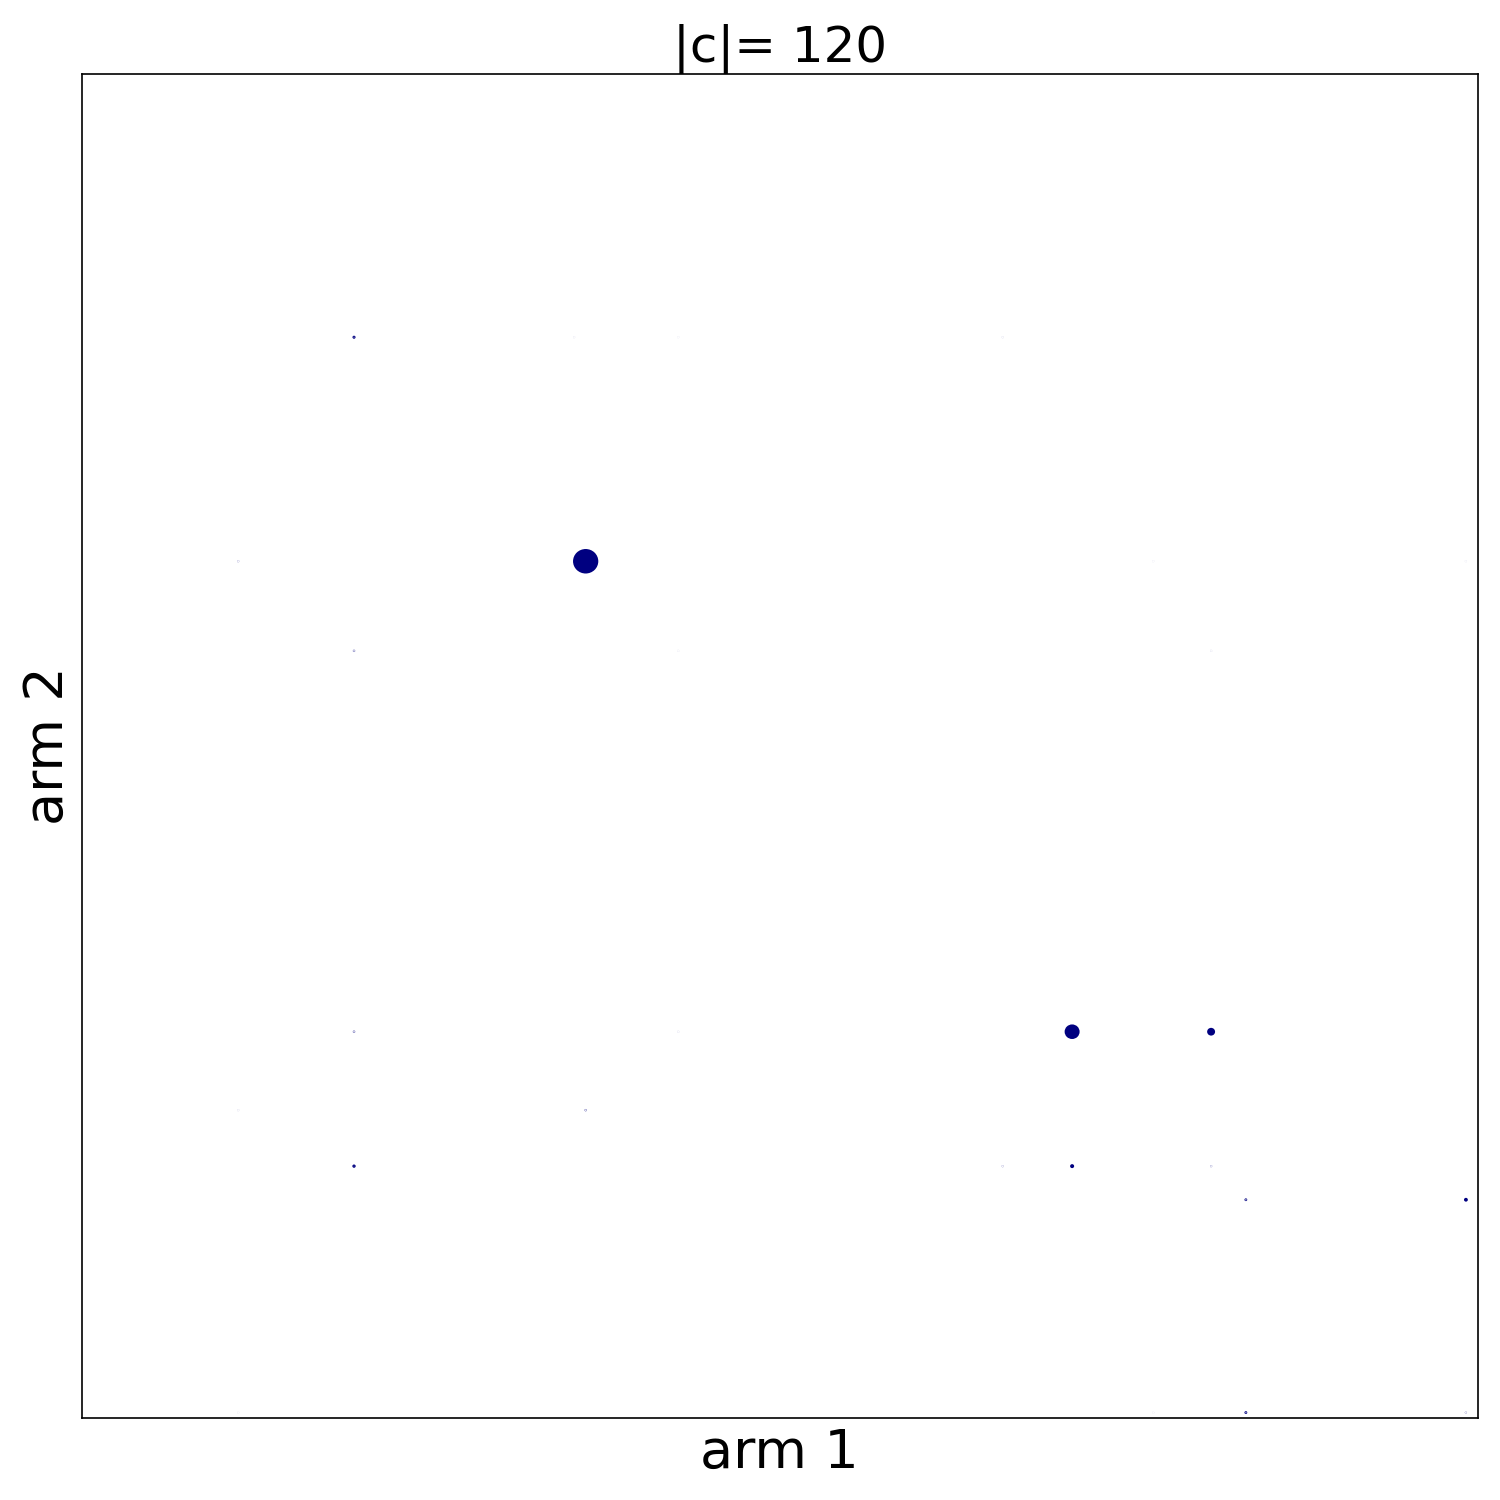

[REVIEW] normalized consensus plot -- expect a bright diagonal; average consensus should be >= 0.95. An almost entirely dark matrix means no reproducible categories were found
  --- norm_consensus_T1_vs_T2_K_120.png


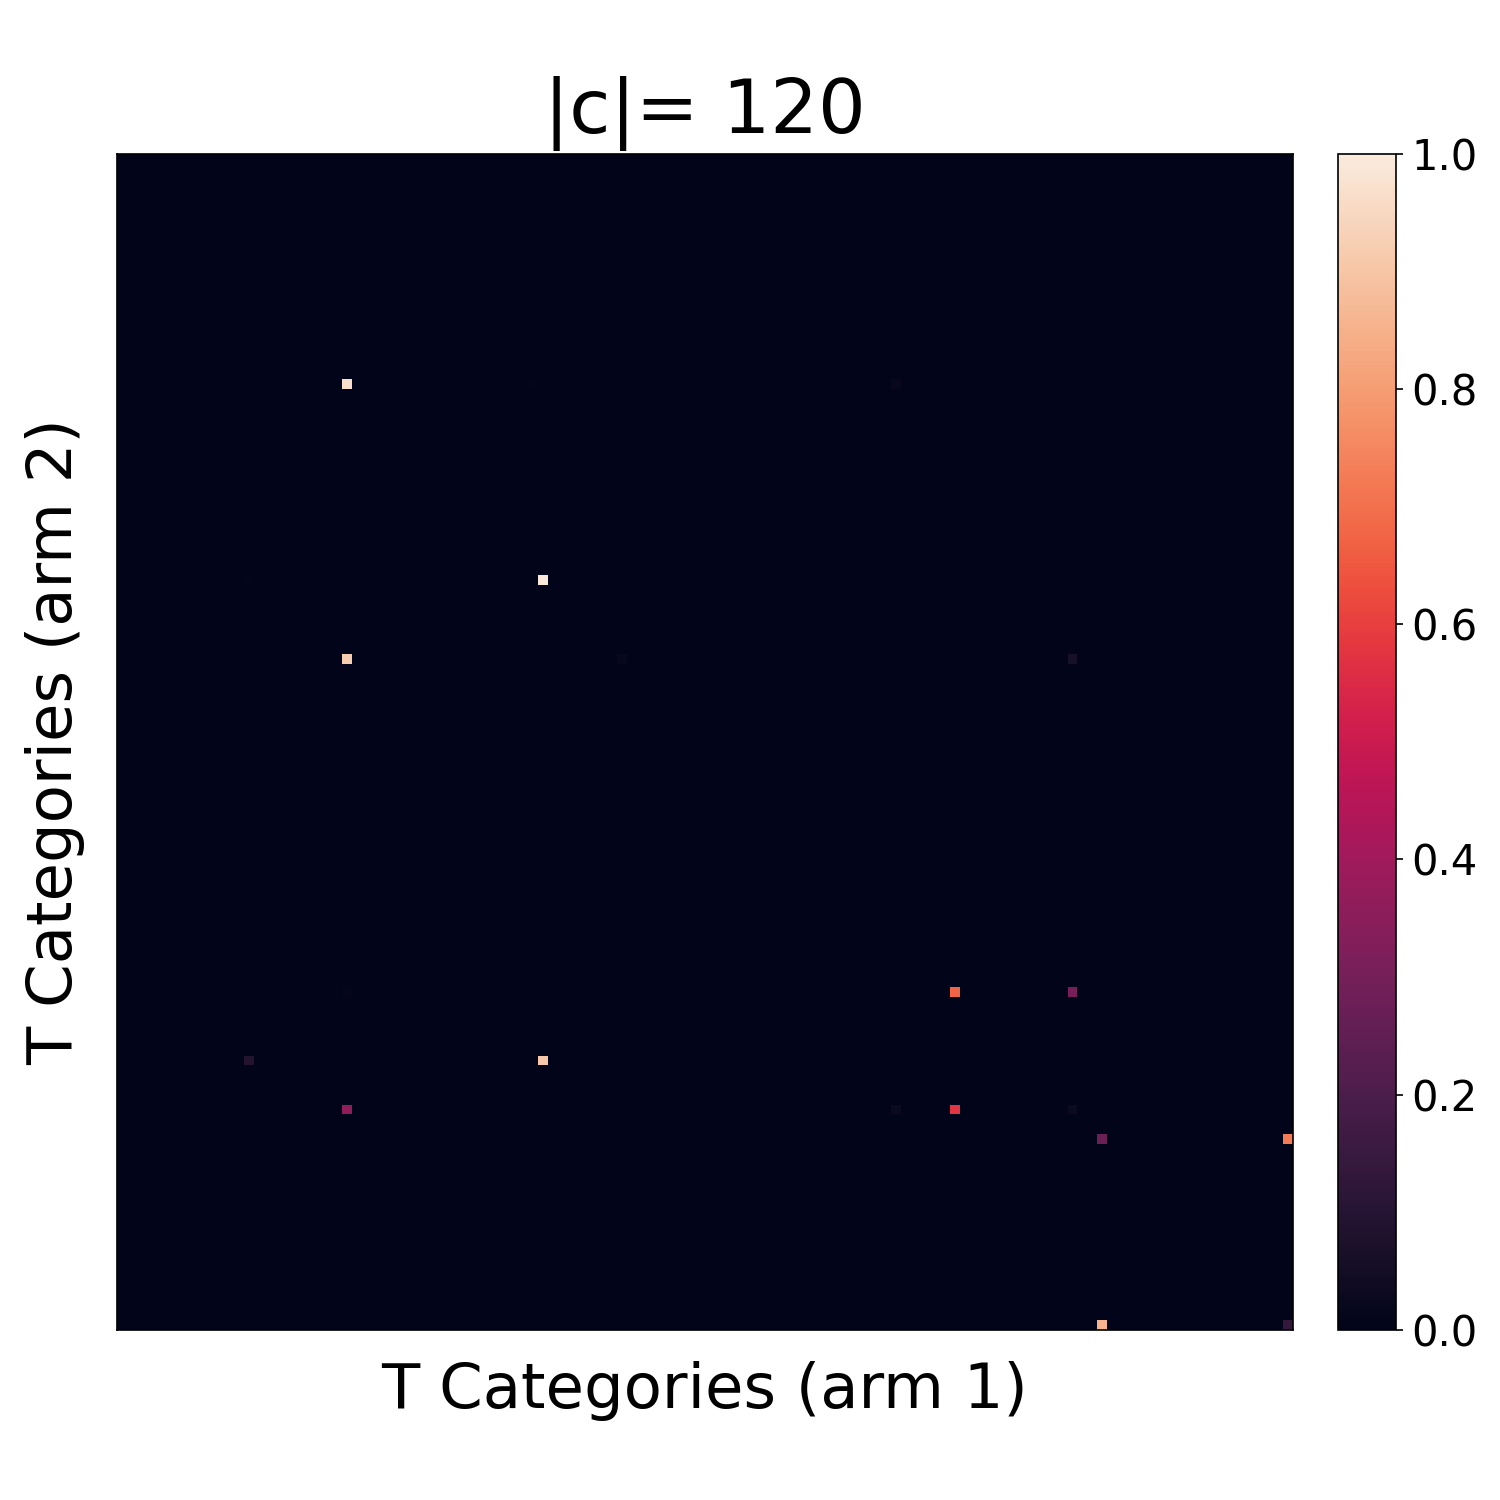

[REVIEW] state-space scatter -- expect visually separated clusters, not one undifferentiated blob. Count the distinct groups: if there are far fewer than model_order (120), the discrete latent has collapsed
  --- state_mu_K_120_arm_0.png


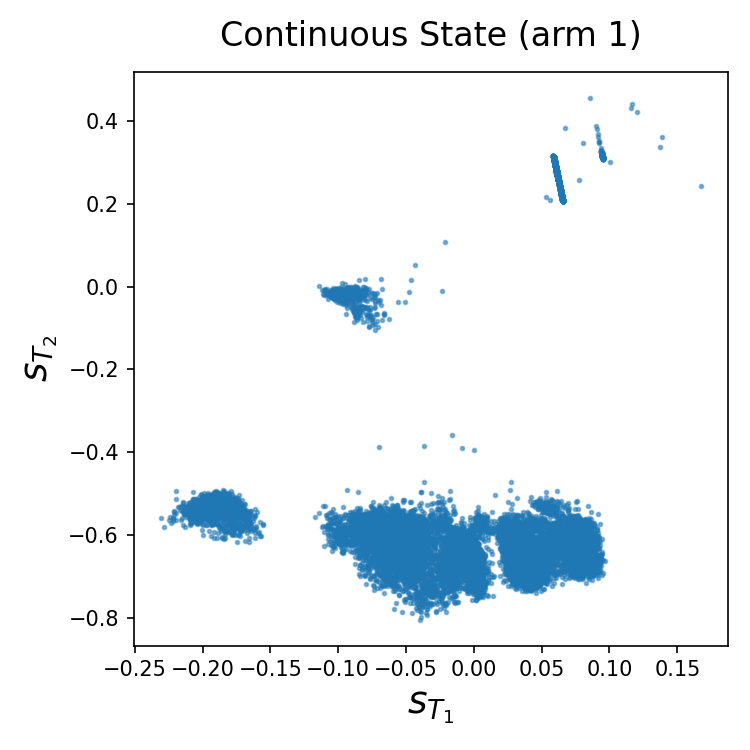

[REVIEW] state-space scatter -- expect visually separated clusters, not one undifferentiated blob. Count the distinct groups: if there are far fewer than model_order (120), the discrete latent has collapsed
  --- state_mu_K_120_arm_1.png


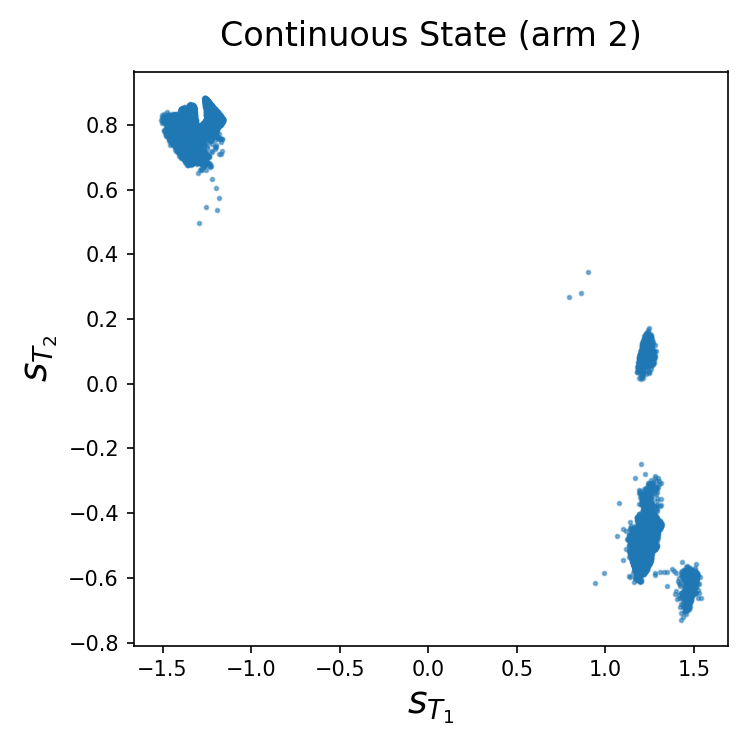

In [19]:
eval_figure_paths = resolve_paths(CONFIG["train"]["evaluation_figures"], pattern="*.png")
print(f"Found {len(eval_figure_paths)} evaluation figures")

for p in eval_figure_paths:
    name = os.path.basename(p)
    if name.startswith("consensus_T1_vs_T2"):
        review(
            "consensus bubble plot",
            "expect a strong diagonal of bubbles spanning the full category "
            "range. A handful of scattered points means the arms almost never "
            "co-assign and only those few categories carry cells",
        )
    elif name.startswith("norm_consensus"):
        review(
            "normalized consensus plot",
            f"expect a bright diagonal; average consensus should be >= "
            f"{k_select_thr}. An almost entirely dark matrix means no "
            f"reproducible categories were found",
        )
    elif name.startswith("state_mu"):
        review(
            "state-space scatter",
            "expect visually separated clusters, not one undifferentiated blob. "
            "Count the distinct groups: if there are far fewer than "
            f"model_order ({model_order}), the discrete latent has collapsed",
        )
    show_image(p, title=name)

## Stage 3 -- Analyze: Clusterability (`clusterability_manifest.json` + figures)

Checks `model_order` is consistent with Train's `evaluation_results.json`, then shows the
classification-accuracy bar chart, silhouette curve, and confusion-matrix heatmaps for review.

In [20]:
clust_manifest = load_json_gcs(CONFIG["analyze"]["clusterability_manifest"])
print(json.dumps(clust_manifest, indent=2))

check(
    "clusterability model_order matches Train's evaluation_results",
    clust_manifest["model_order"] == model_order,
    f"clusterability={clust_manifest['model_order']}, train={model_order}",
)

# n_ttype is the reference cell-type count read from the .h5ad, so it must match
# what DataPrep wrote -- a mismatch means Analyze ran against different data.
if DATAPREP_N_CLUSTERS is not None:
    check(
        "clusterability n_ttype matches DataPrep cluster count",
        clust_manifest.get("n_ttype") == DATAPREP_N_CLUSTERS,
        f"clusterability n_ttype={clust_manifest.get('n_ttype')}, "
        f"dataprep clusters={DATAPREP_N_CLUSTERS}",
    )

check(
    "clusterability n_arm matches Train's evaluation_results",
    clust_manifest.get("n_arm") == eval_results.get("n_arm"),
    f"clusterability={clust_manifest.get('n_arm')}, "
    f"train={eval_results.get('n_arm')}",
)

{
  "output_dir": "/mnt/disks/cromwell_root/out",
  "model_order": 120,
  "n_ttype": 115,
  "n_arm": 2,
  "figures": [
    "out/classAcc_RF_K_120.png",
    "out/SC_K_120_20260810.png",
    "out/conf_Ttype_pc.png",
    "out/conf_Ttype_lowD_arm_0.png",
    "out/conf_ConsType_pc_arm_0.png",
    "out/conf_ConsType_lowD_arm_0.png",
    "out/conf_Ttype_lowD_arm_1.png",
    "out/conf_ConsType_pc_arm_1.png",
    "out/conf_ConsType_lowD_arm_1.png"
  ]
}
[PASS] clusterability model_order matches Train's evaluation_results -- clusterability=120, train=120
[PASS] clusterability n_ttype matches DataPrep cluster count -- clusterability n_ttype=115, dataprep clusters=115
[PASS] clusterability n_arm matches Train's evaluation_results -- clusterability=2, train=2


Found 9 clusterability figures
[REVIEW] silhouette score curve -- most categories should have positive silhouette scores, and the MMIDAS curves should sit near the t-type reference curve. If the x-axis spans a single value or the legend has one entry per category, the figure is broken rather than the model
  --- SC_K_120_20260810.png


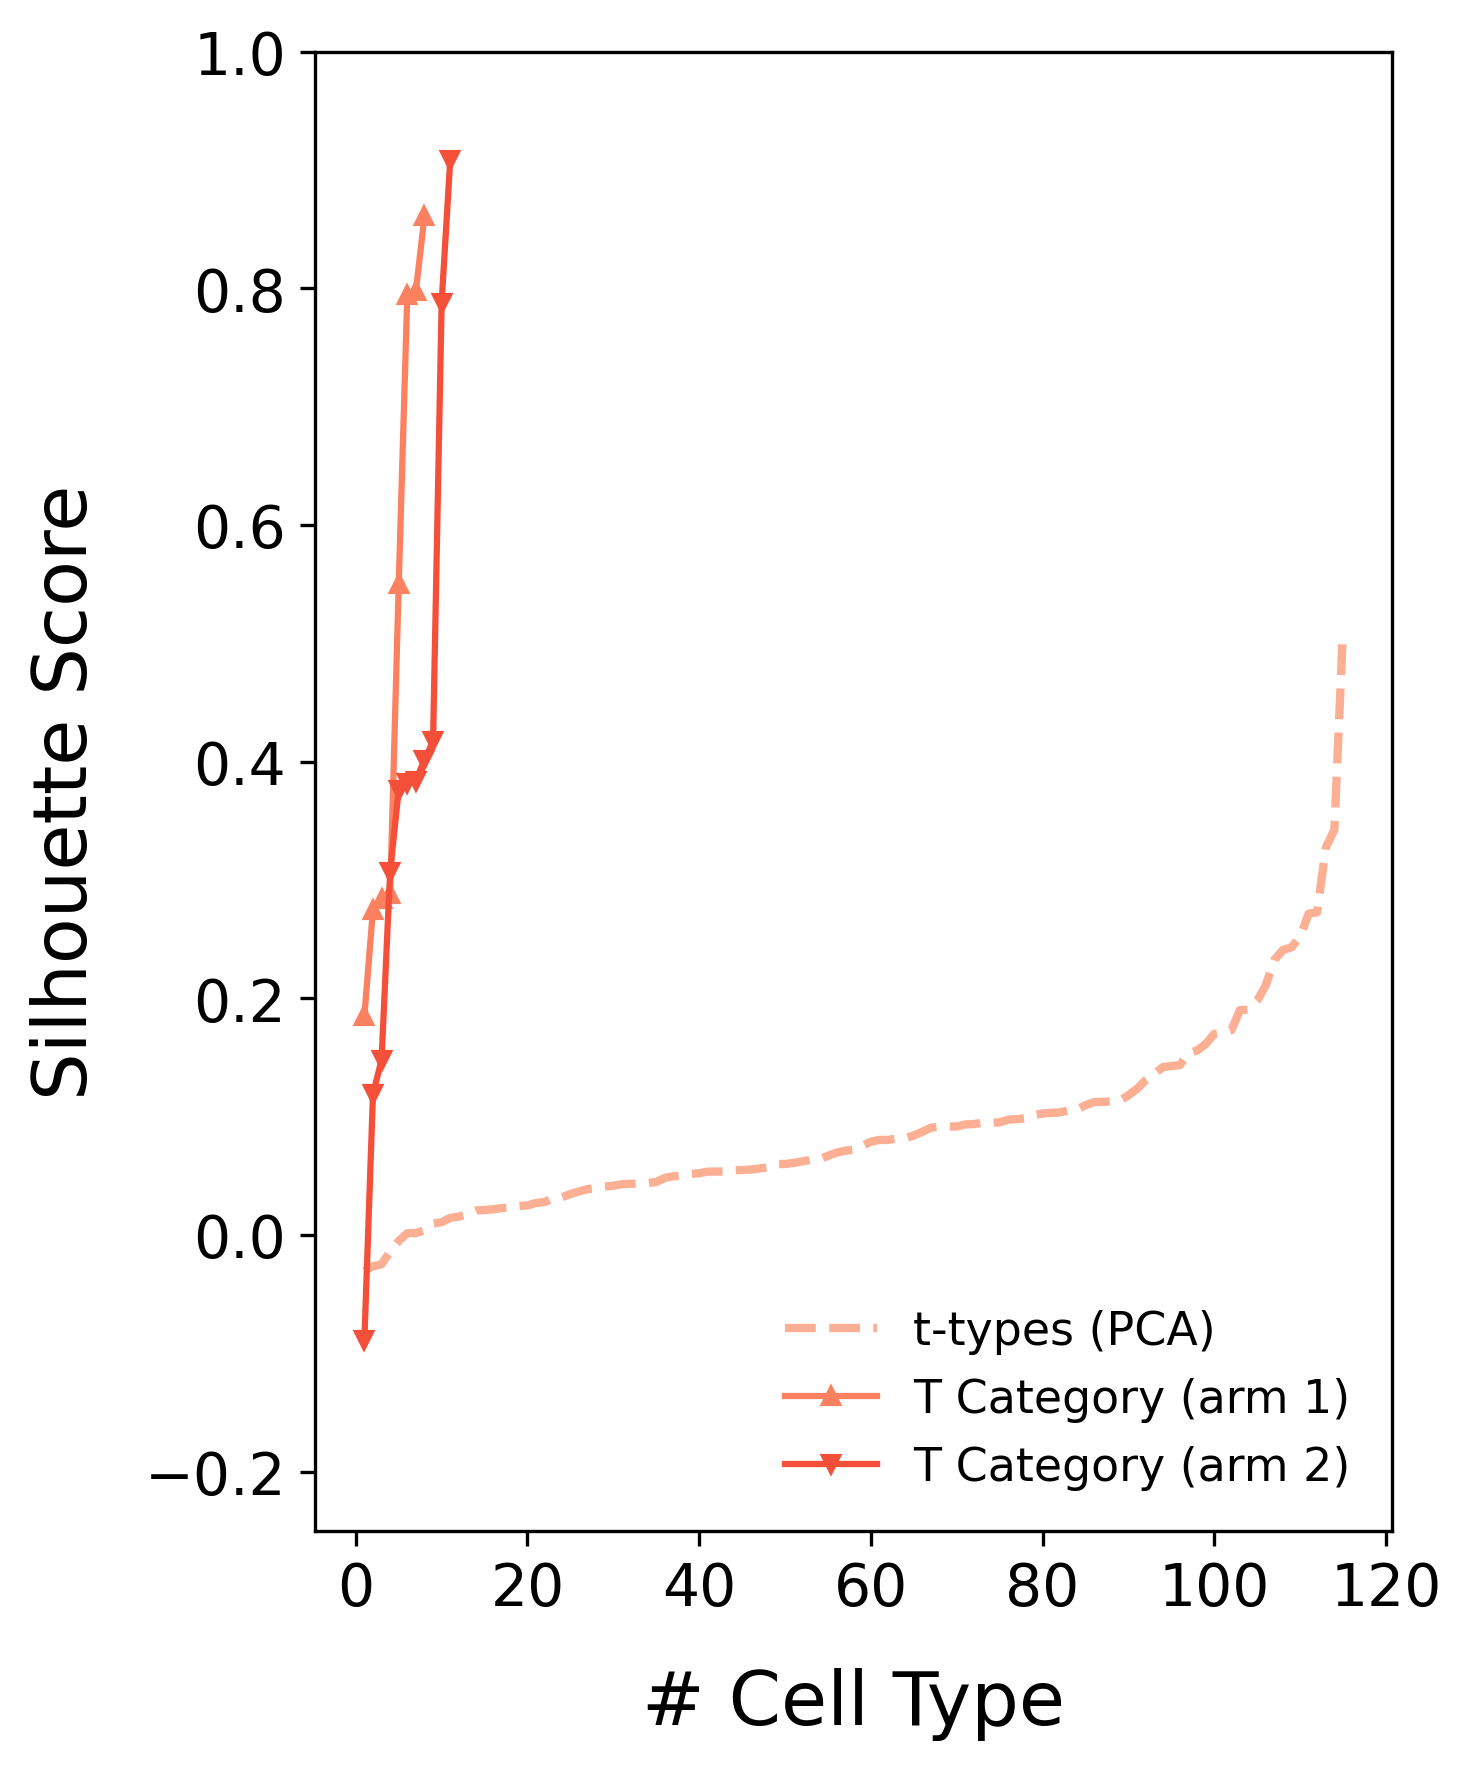

[REVIEW] RF classification accuracy bar chart -- read the 't-types' group only: that is the MMIDAS lowD embedding vs the PCA baseline at recovering the reference labels. The 'T Categories' groups classify the model's own labels, so ~99% there is near-circular and not evidence of anything
  --- classAcc_RF_K_120.png


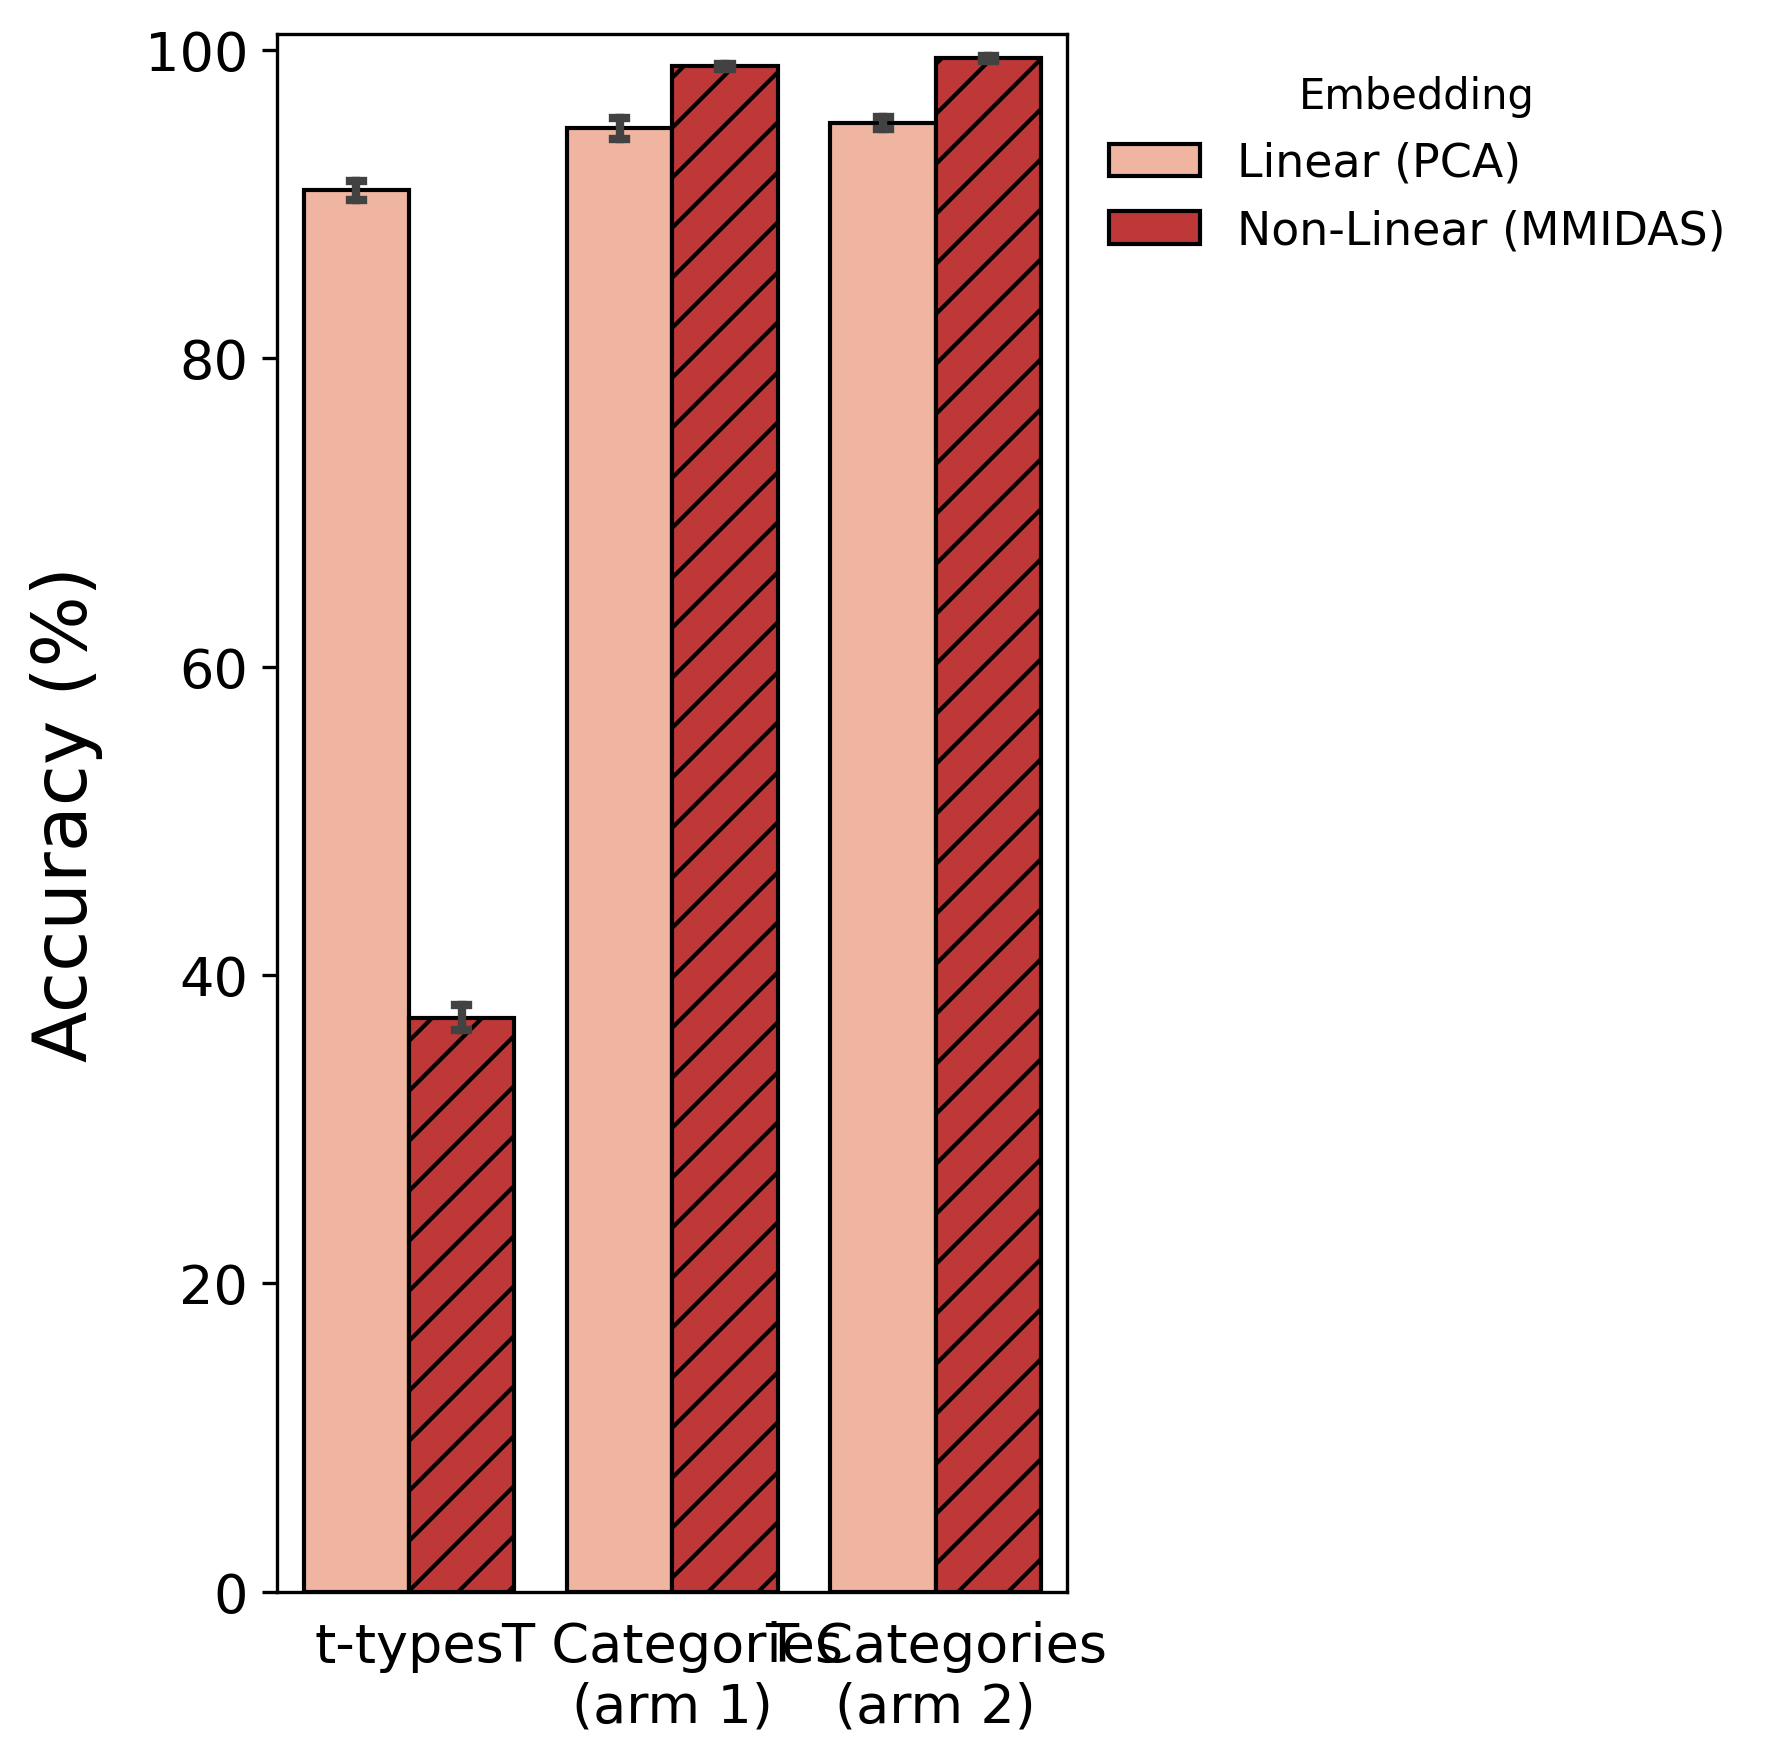

[REVIEW] confusion matrix heatmap -- expect a tight diagonal (conf_ConsType_lowD_arm_0.png). Large square blocks along the diagonal mean many reference types are collapsing into one predicted category
  --- conf_ConsType_lowD_arm_0.png


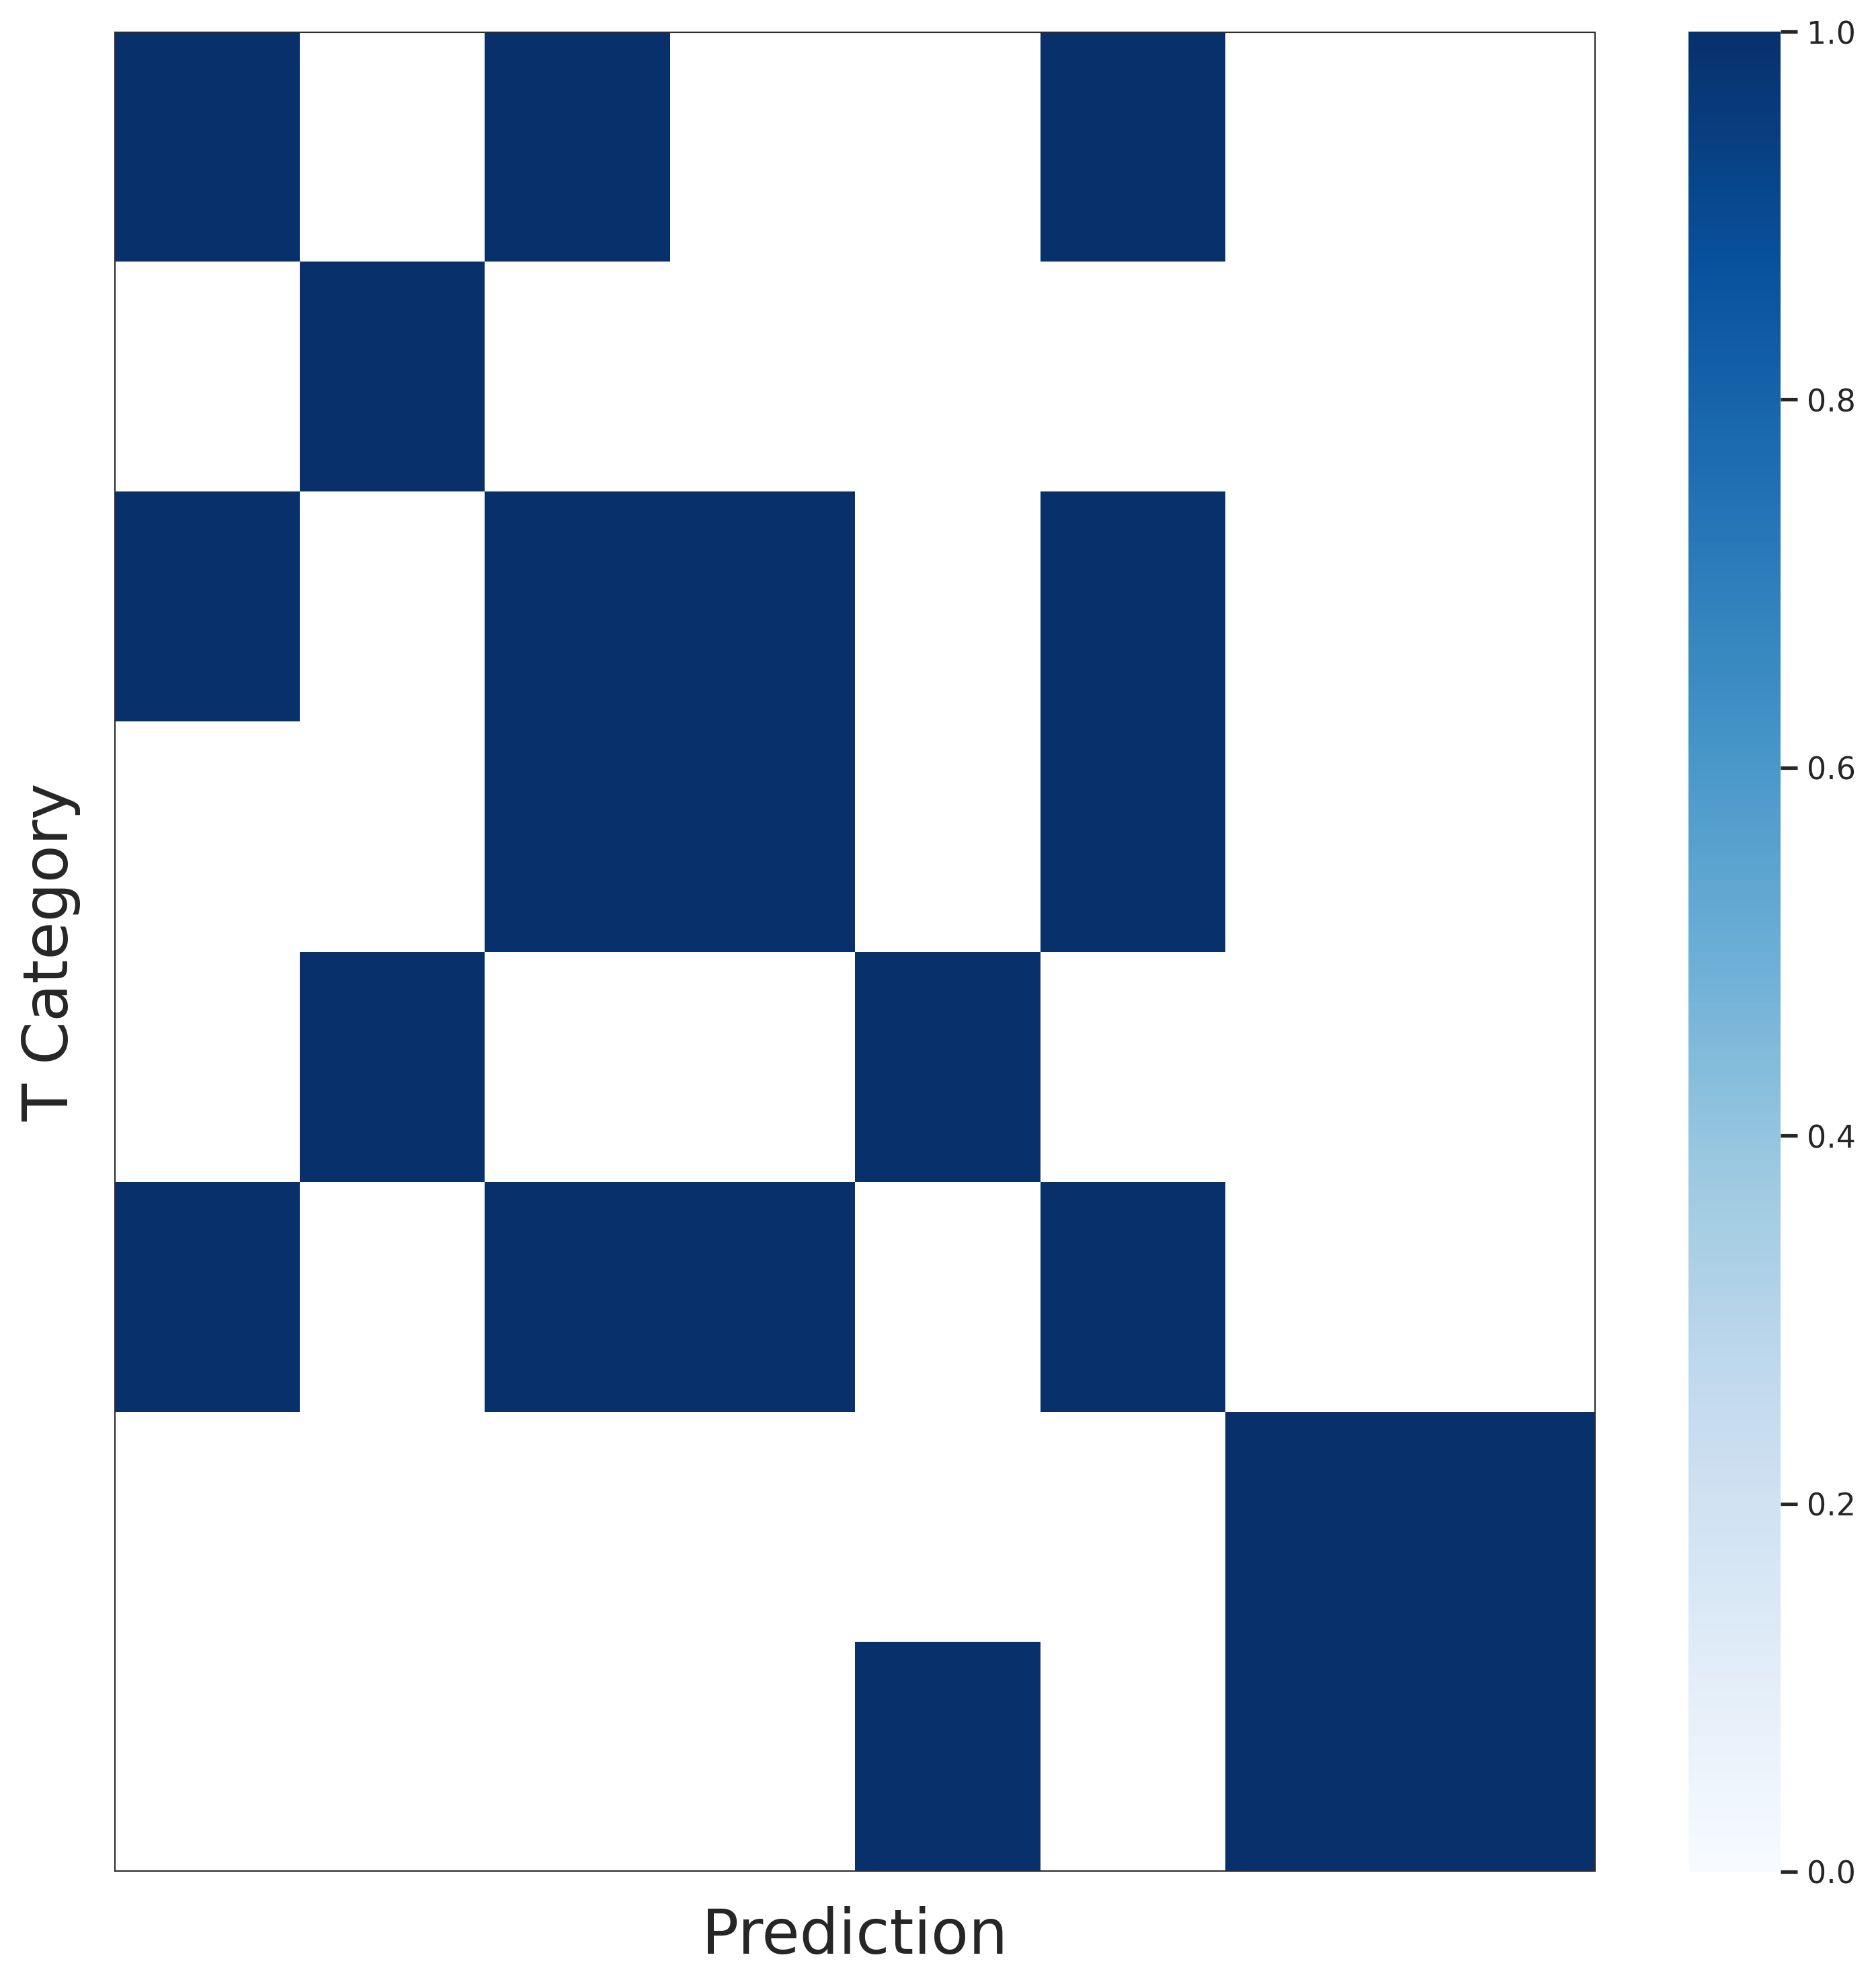

[REVIEW] confusion matrix heatmap -- expect a tight diagonal (conf_ConsType_lowD_arm_1.png). Large square blocks along the diagonal mean many reference types are collapsing into one predicted category
  --- conf_ConsType_lowD_arm_1.png


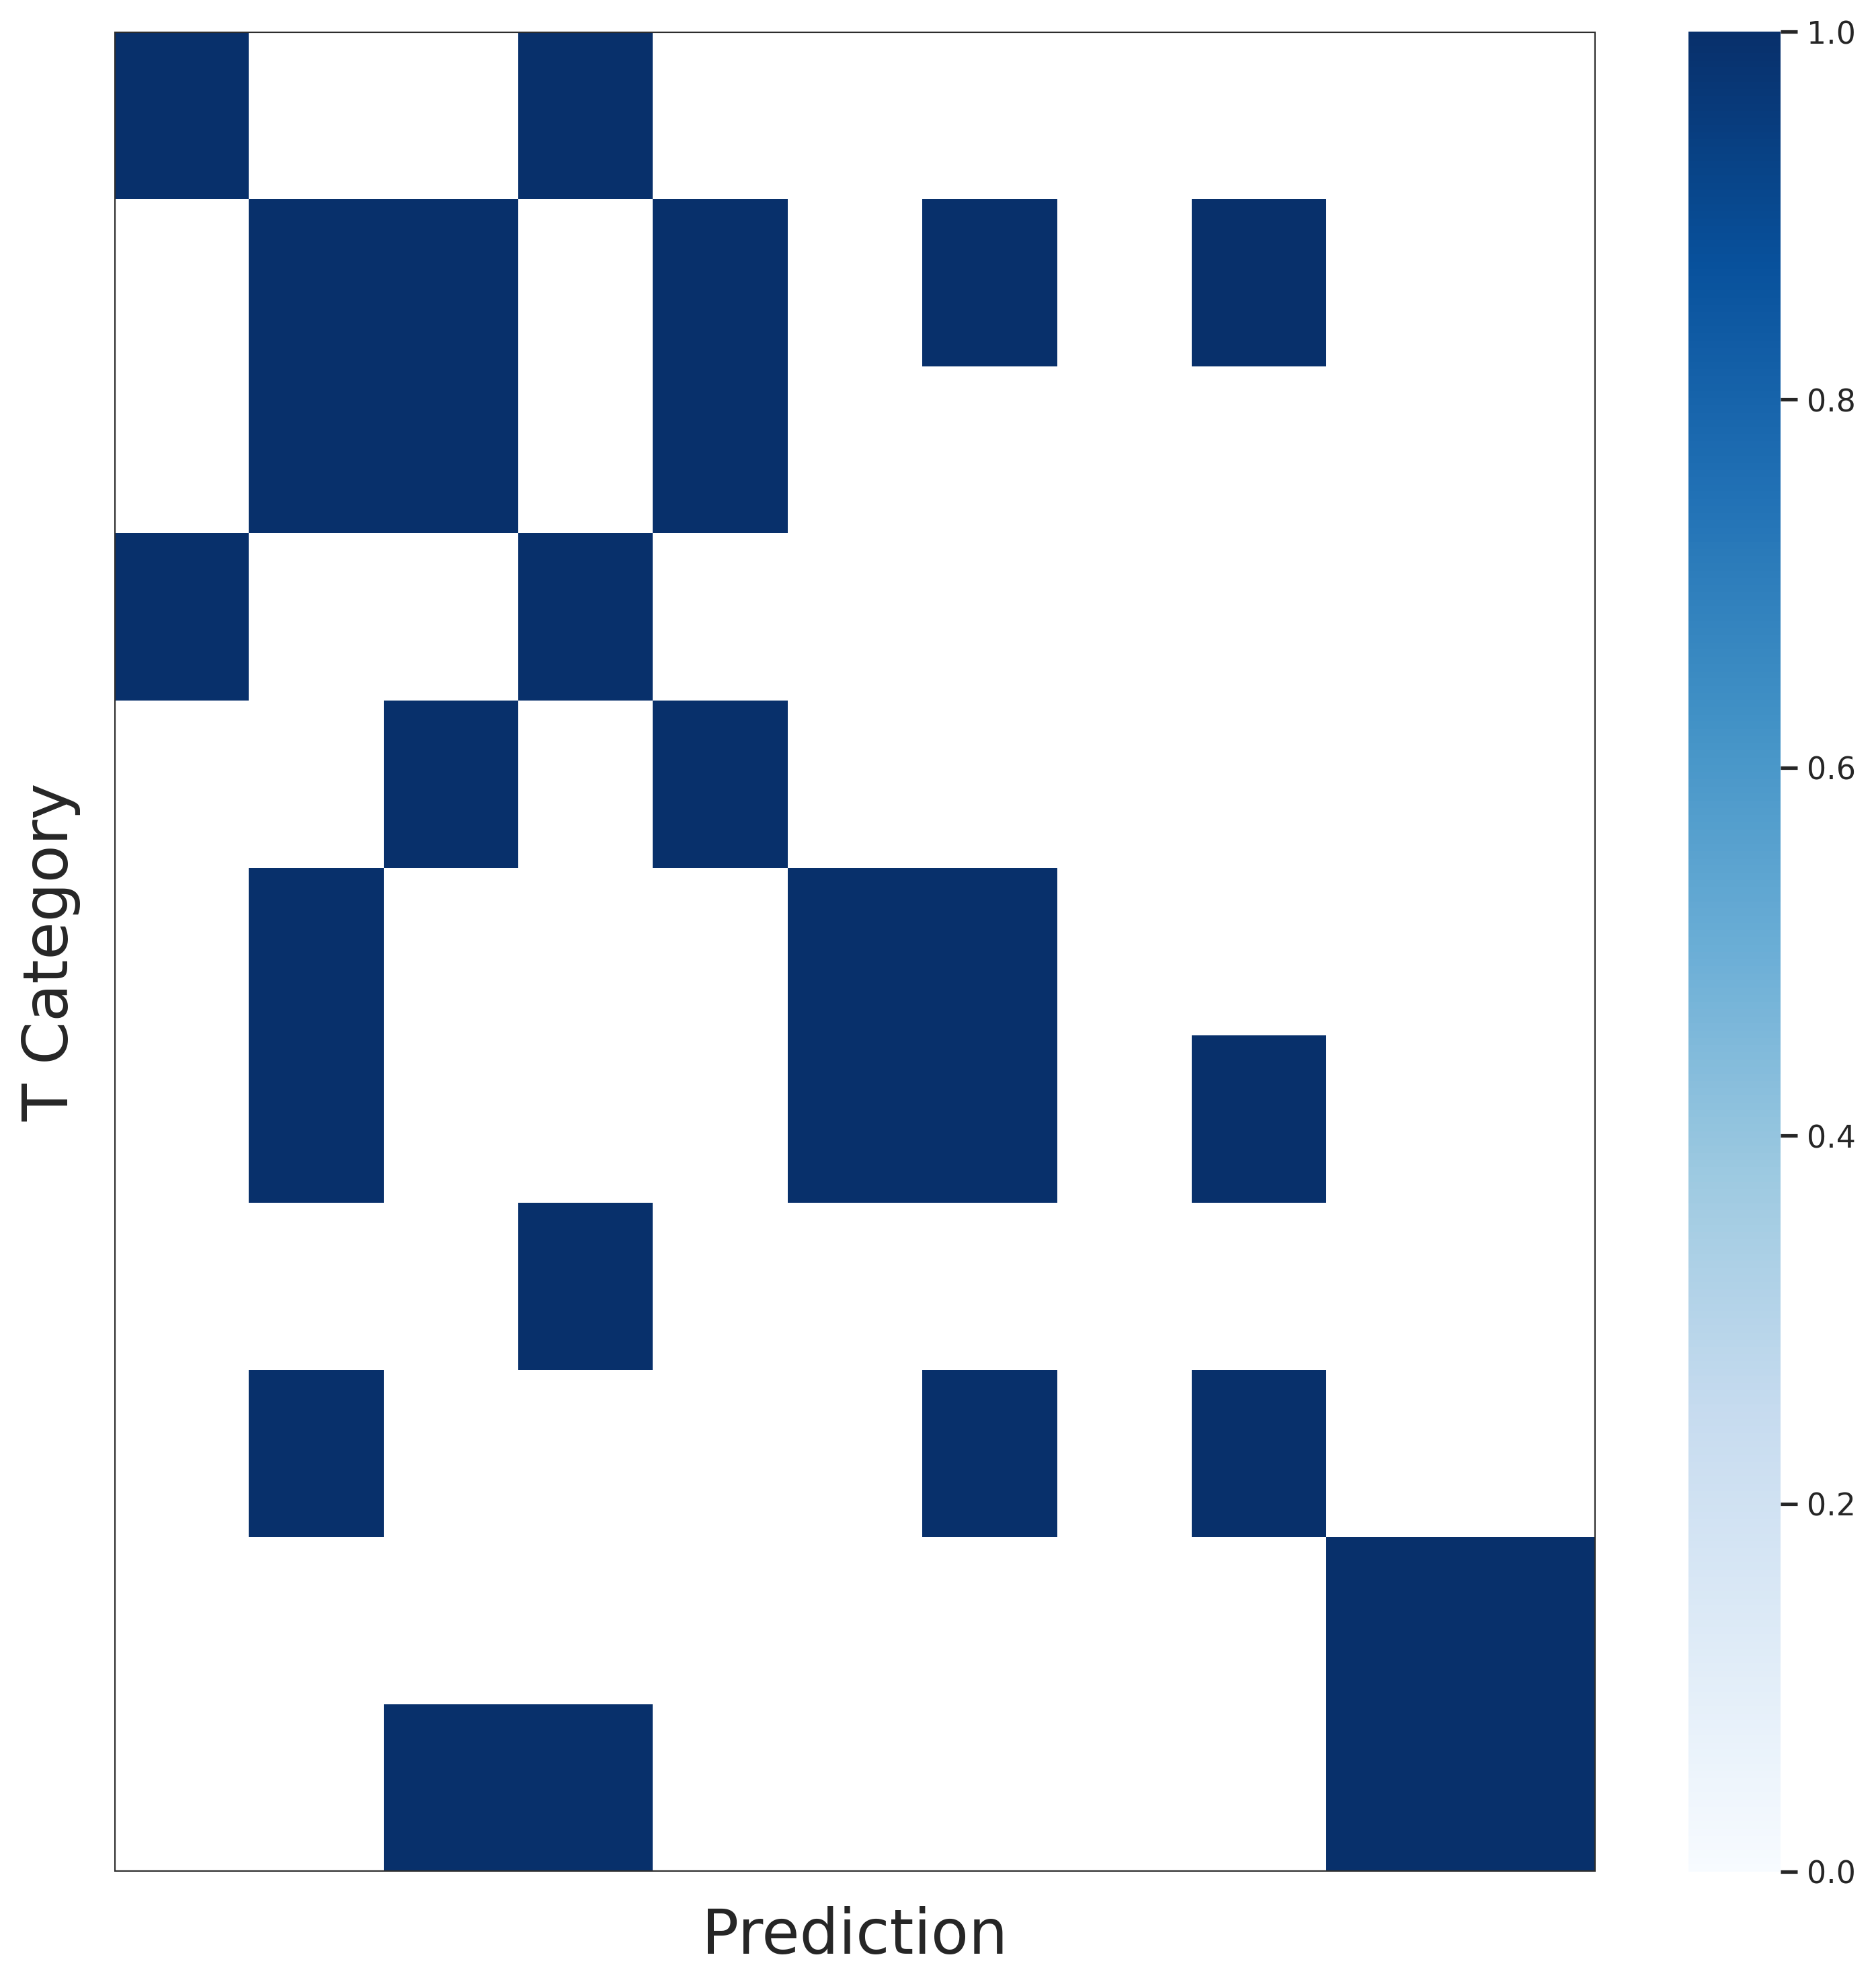

[REVIEW] confusion matrix heatmap -- expect a tight diagonal (conf_ConsType_pc_arm_0.png). Large square blocks along the diagonal mean many reference types are collapsing into one predicted category
  --- conf_ConsType_pc_arm_0.png


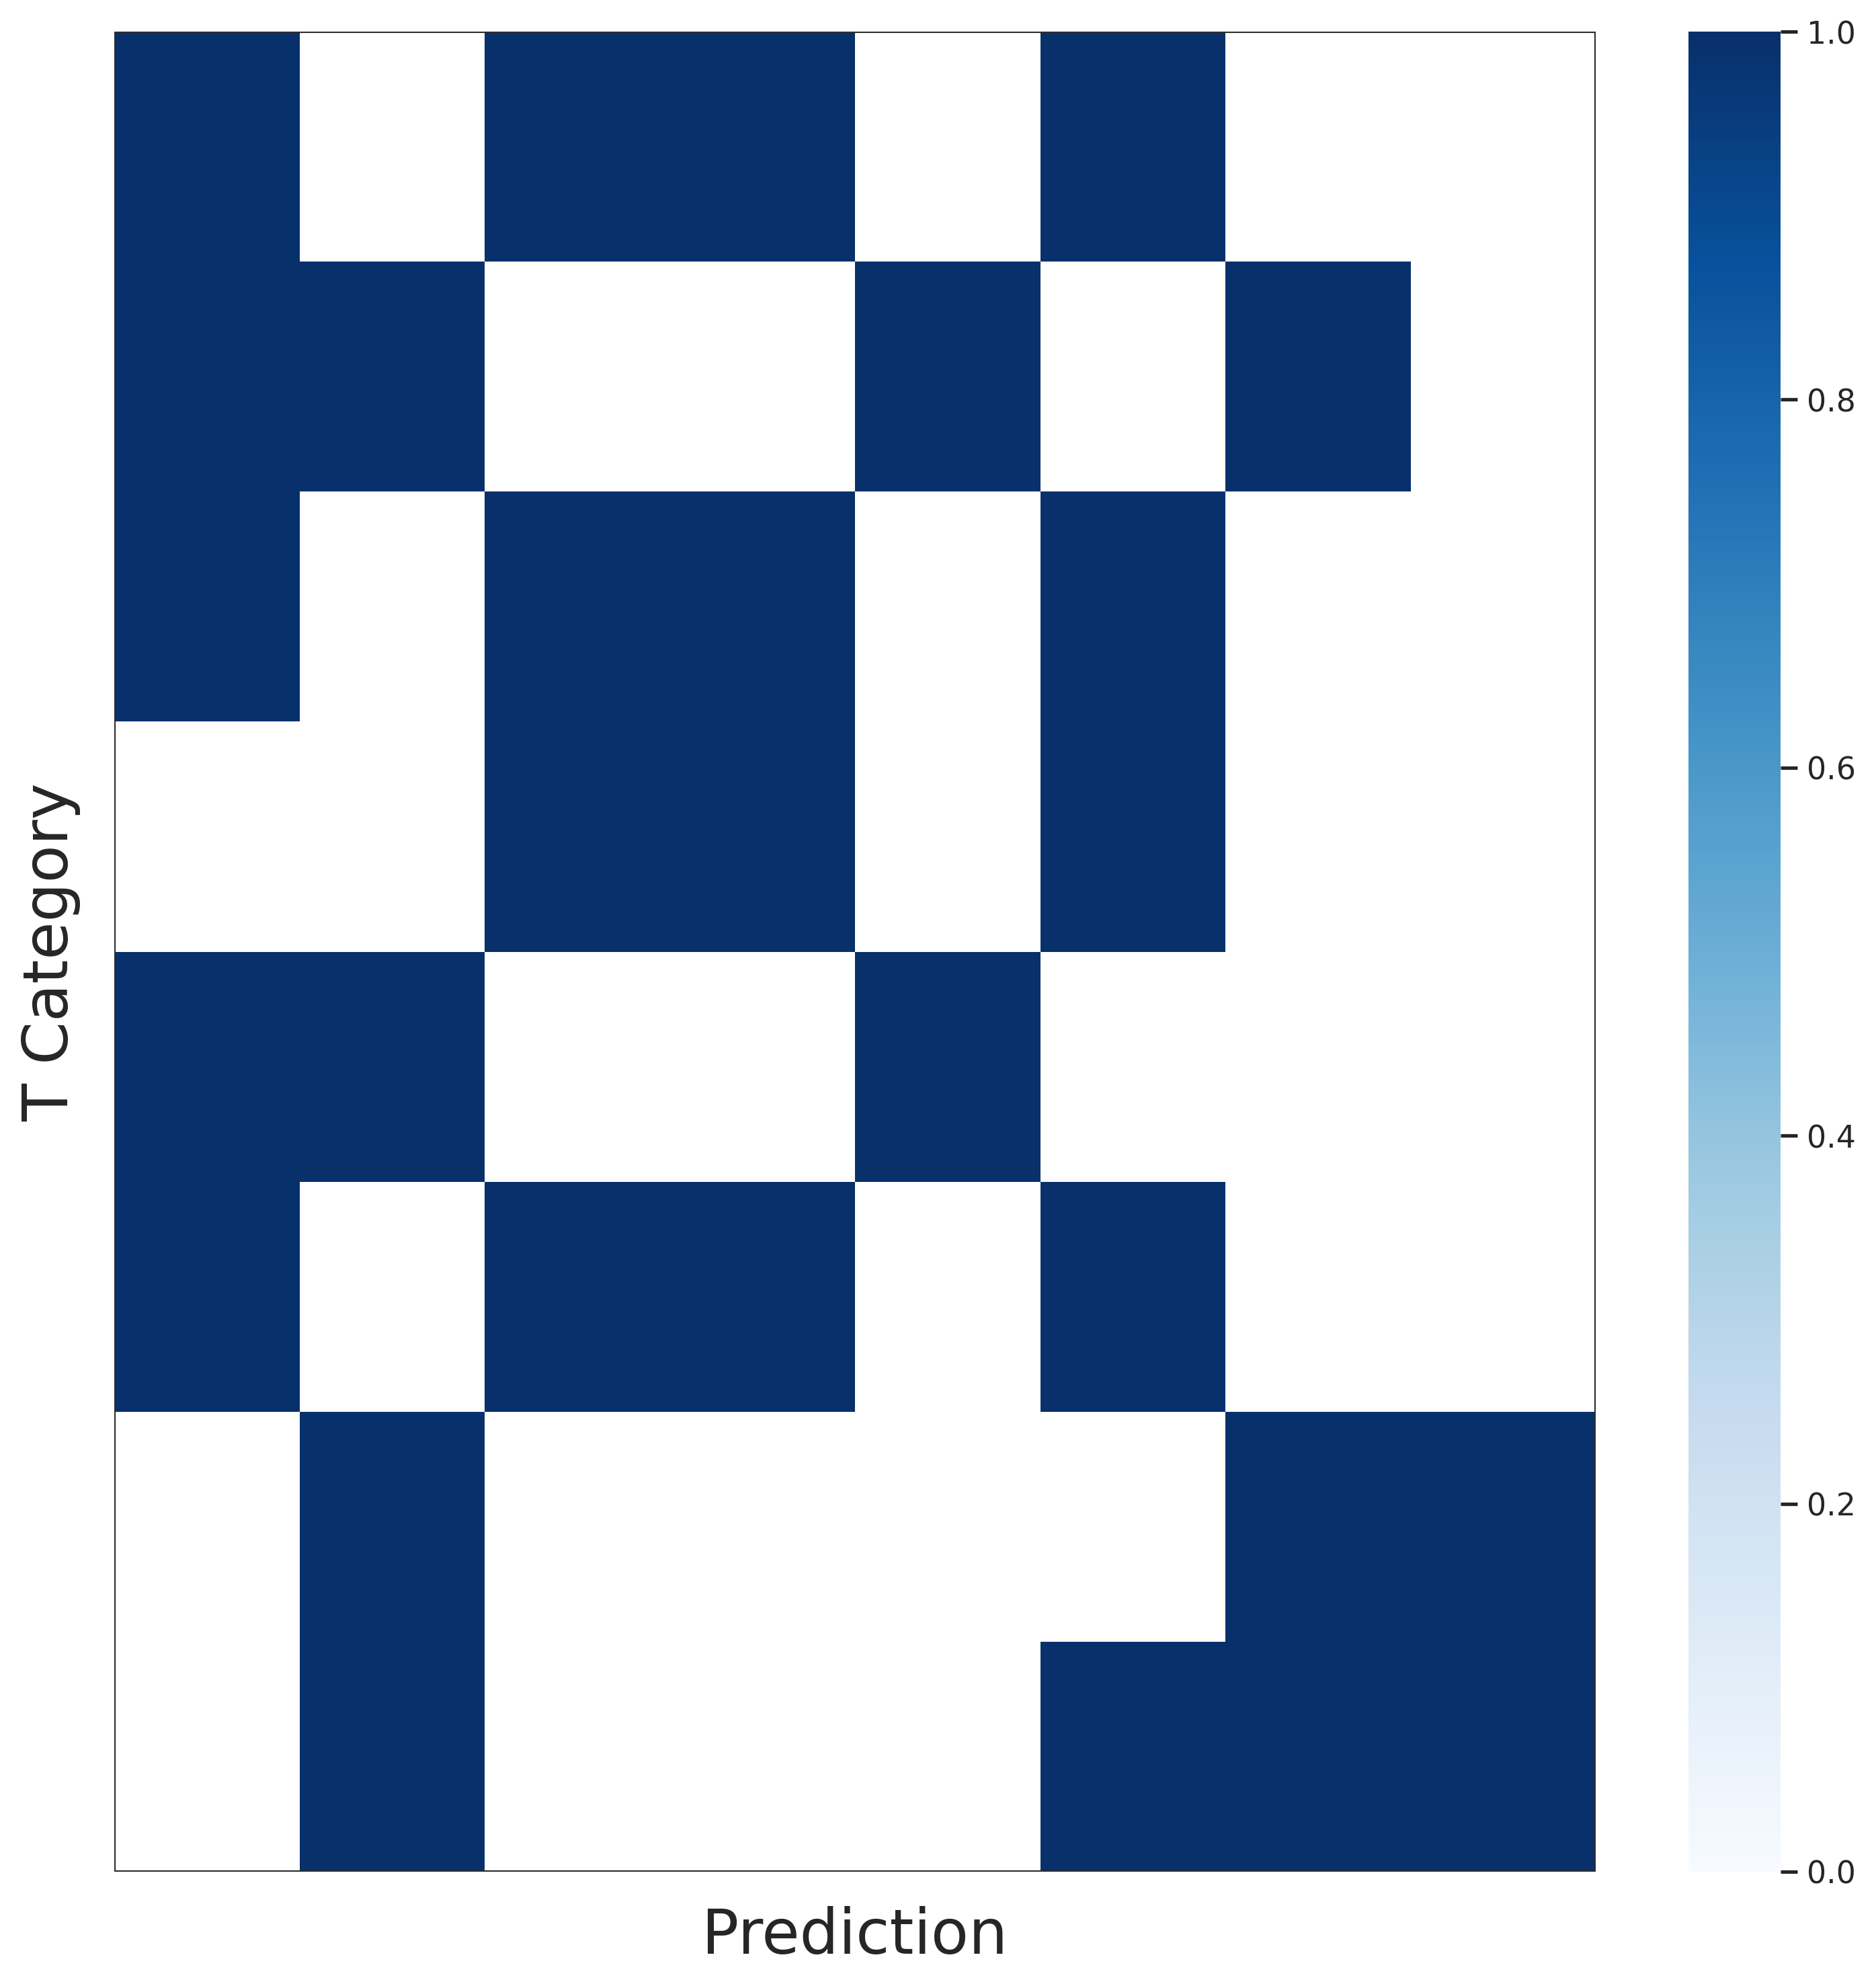

[REVIEW] confusion matrix heatmap -- expect a tight diagonal (conf_ConsType_pc_arm_1.png). Large square blocks along the diagonal mean many reference types are collapsing into one predicted category
  --- conf_ConsType_pc_arm_1.png


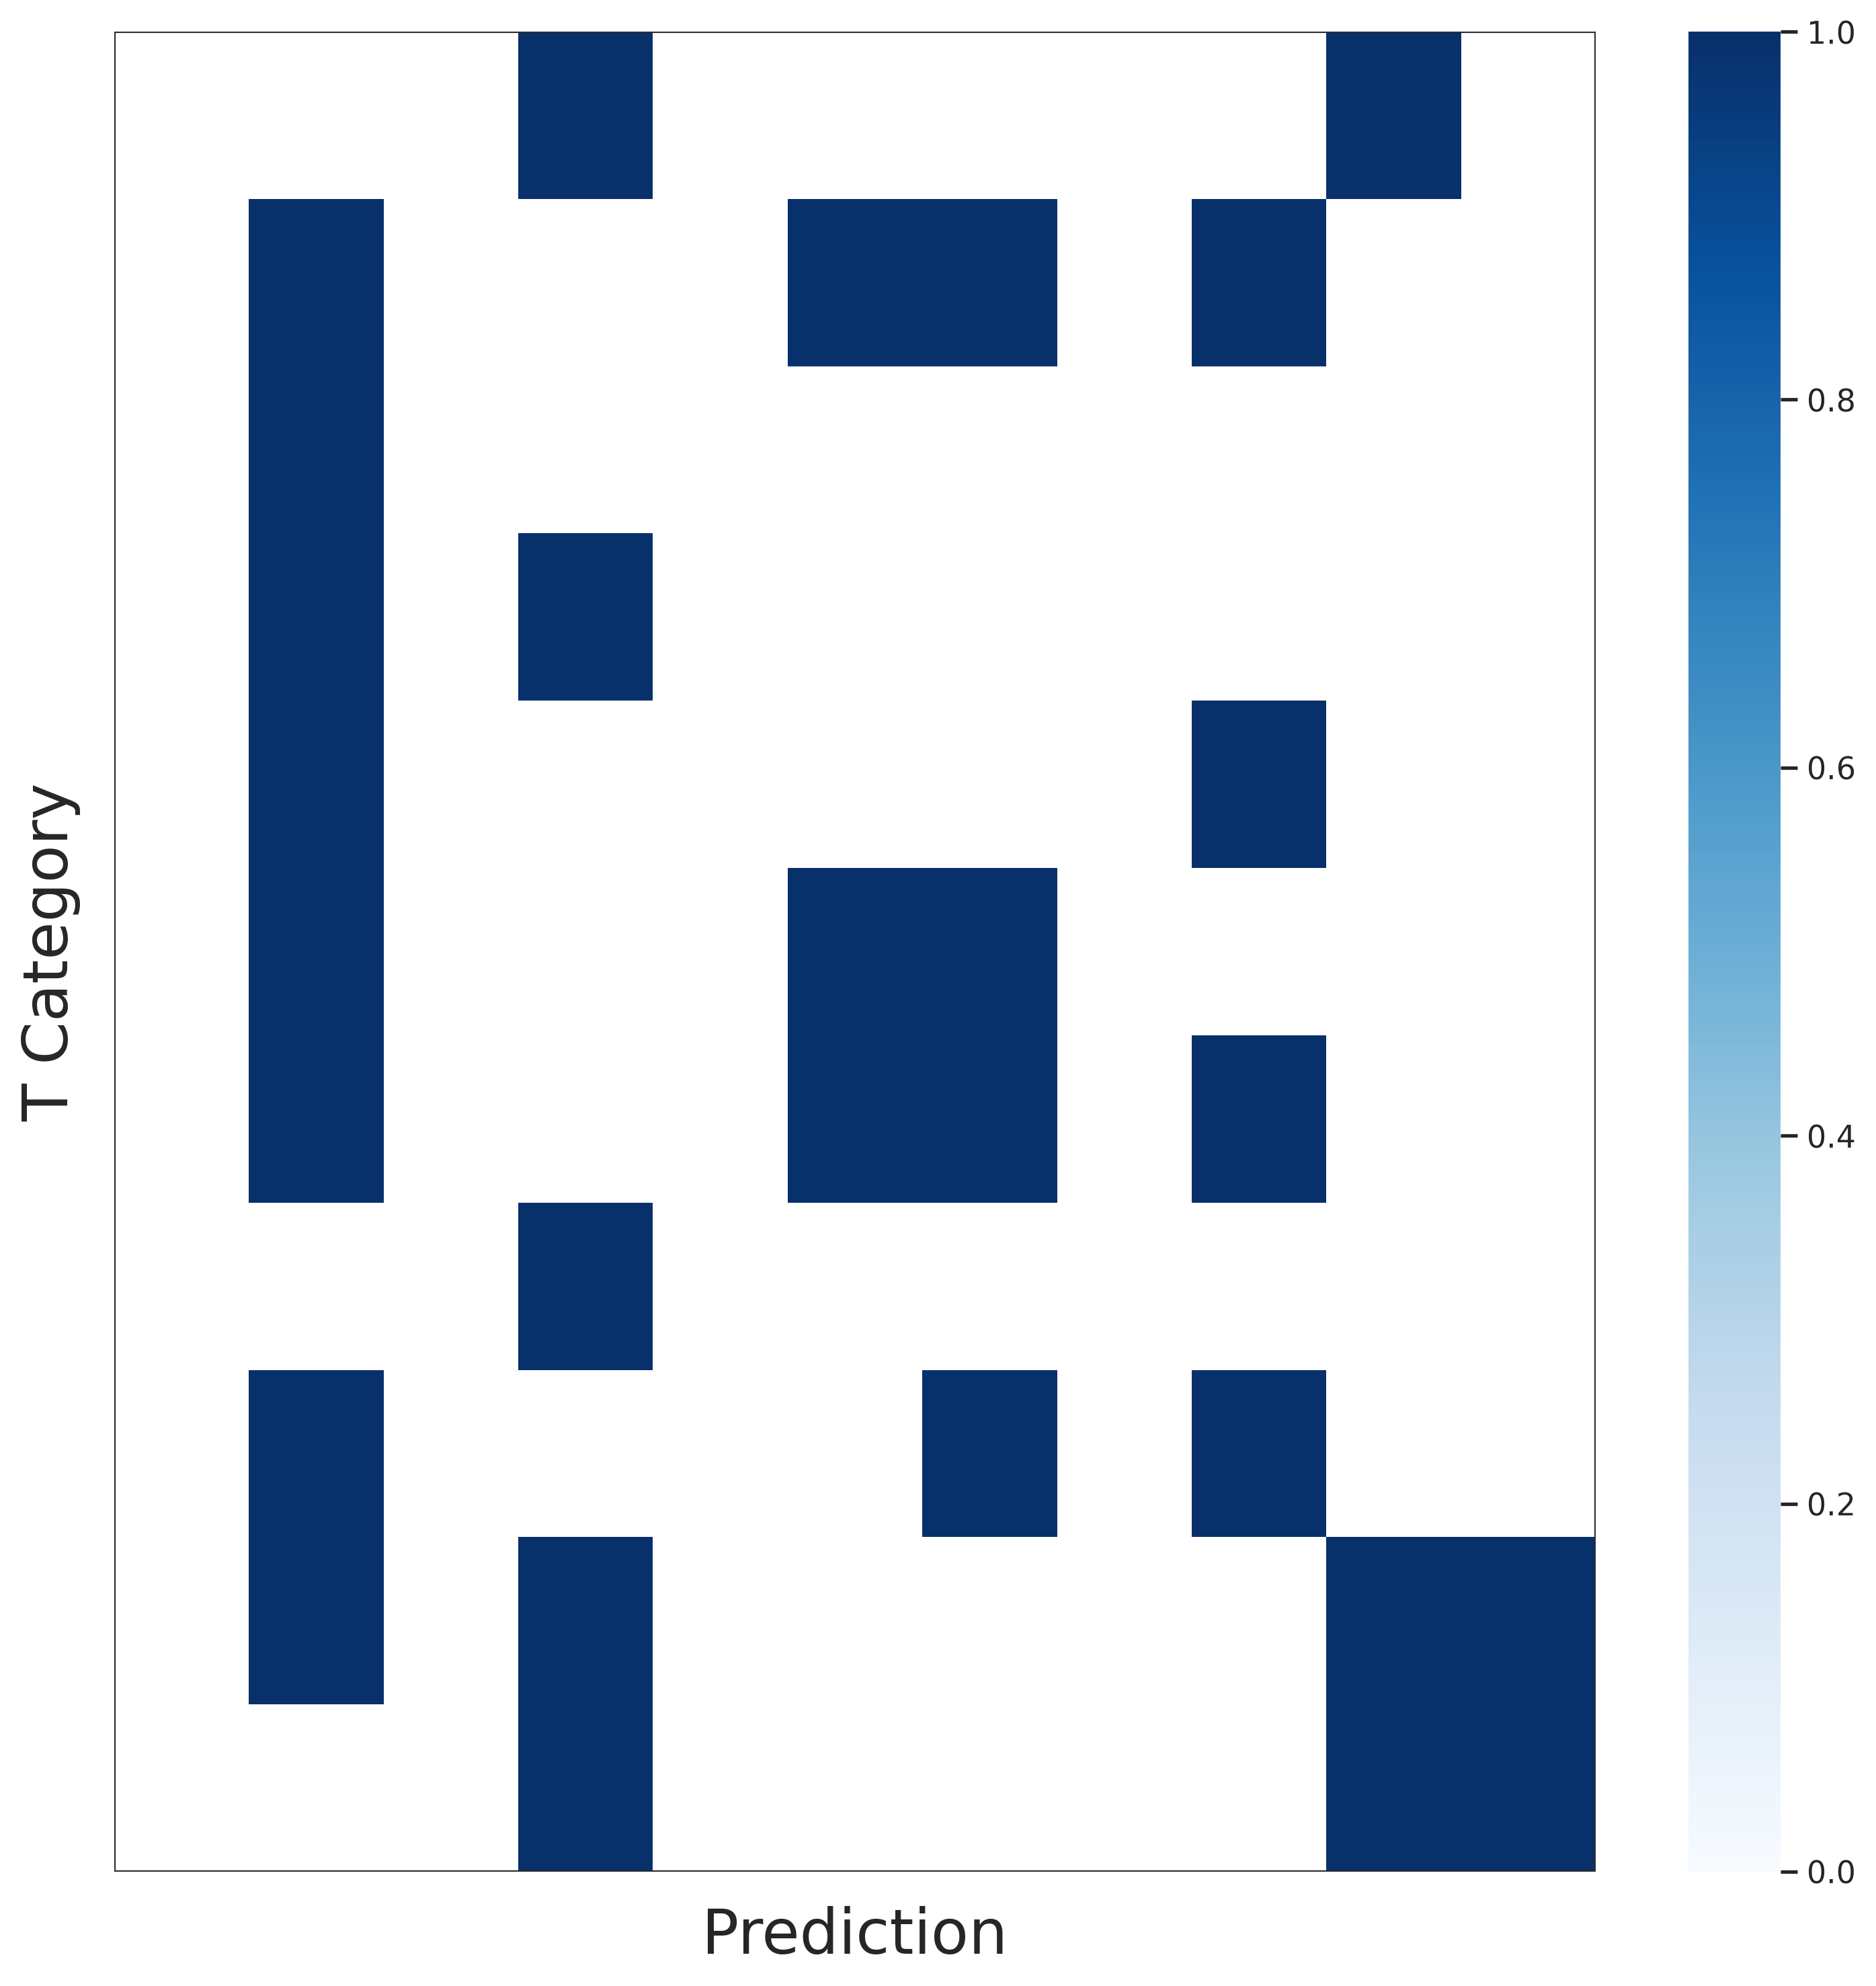

[REVIEW] confusion matrix heatmap -- expect a tight diagonal (conf_Ttype_lowD_arm_0.png). Large square blocks along the diagonal mean many reference types are collapsing into one predicted category
  --- conf_Ttype_lowD_arm_0.png


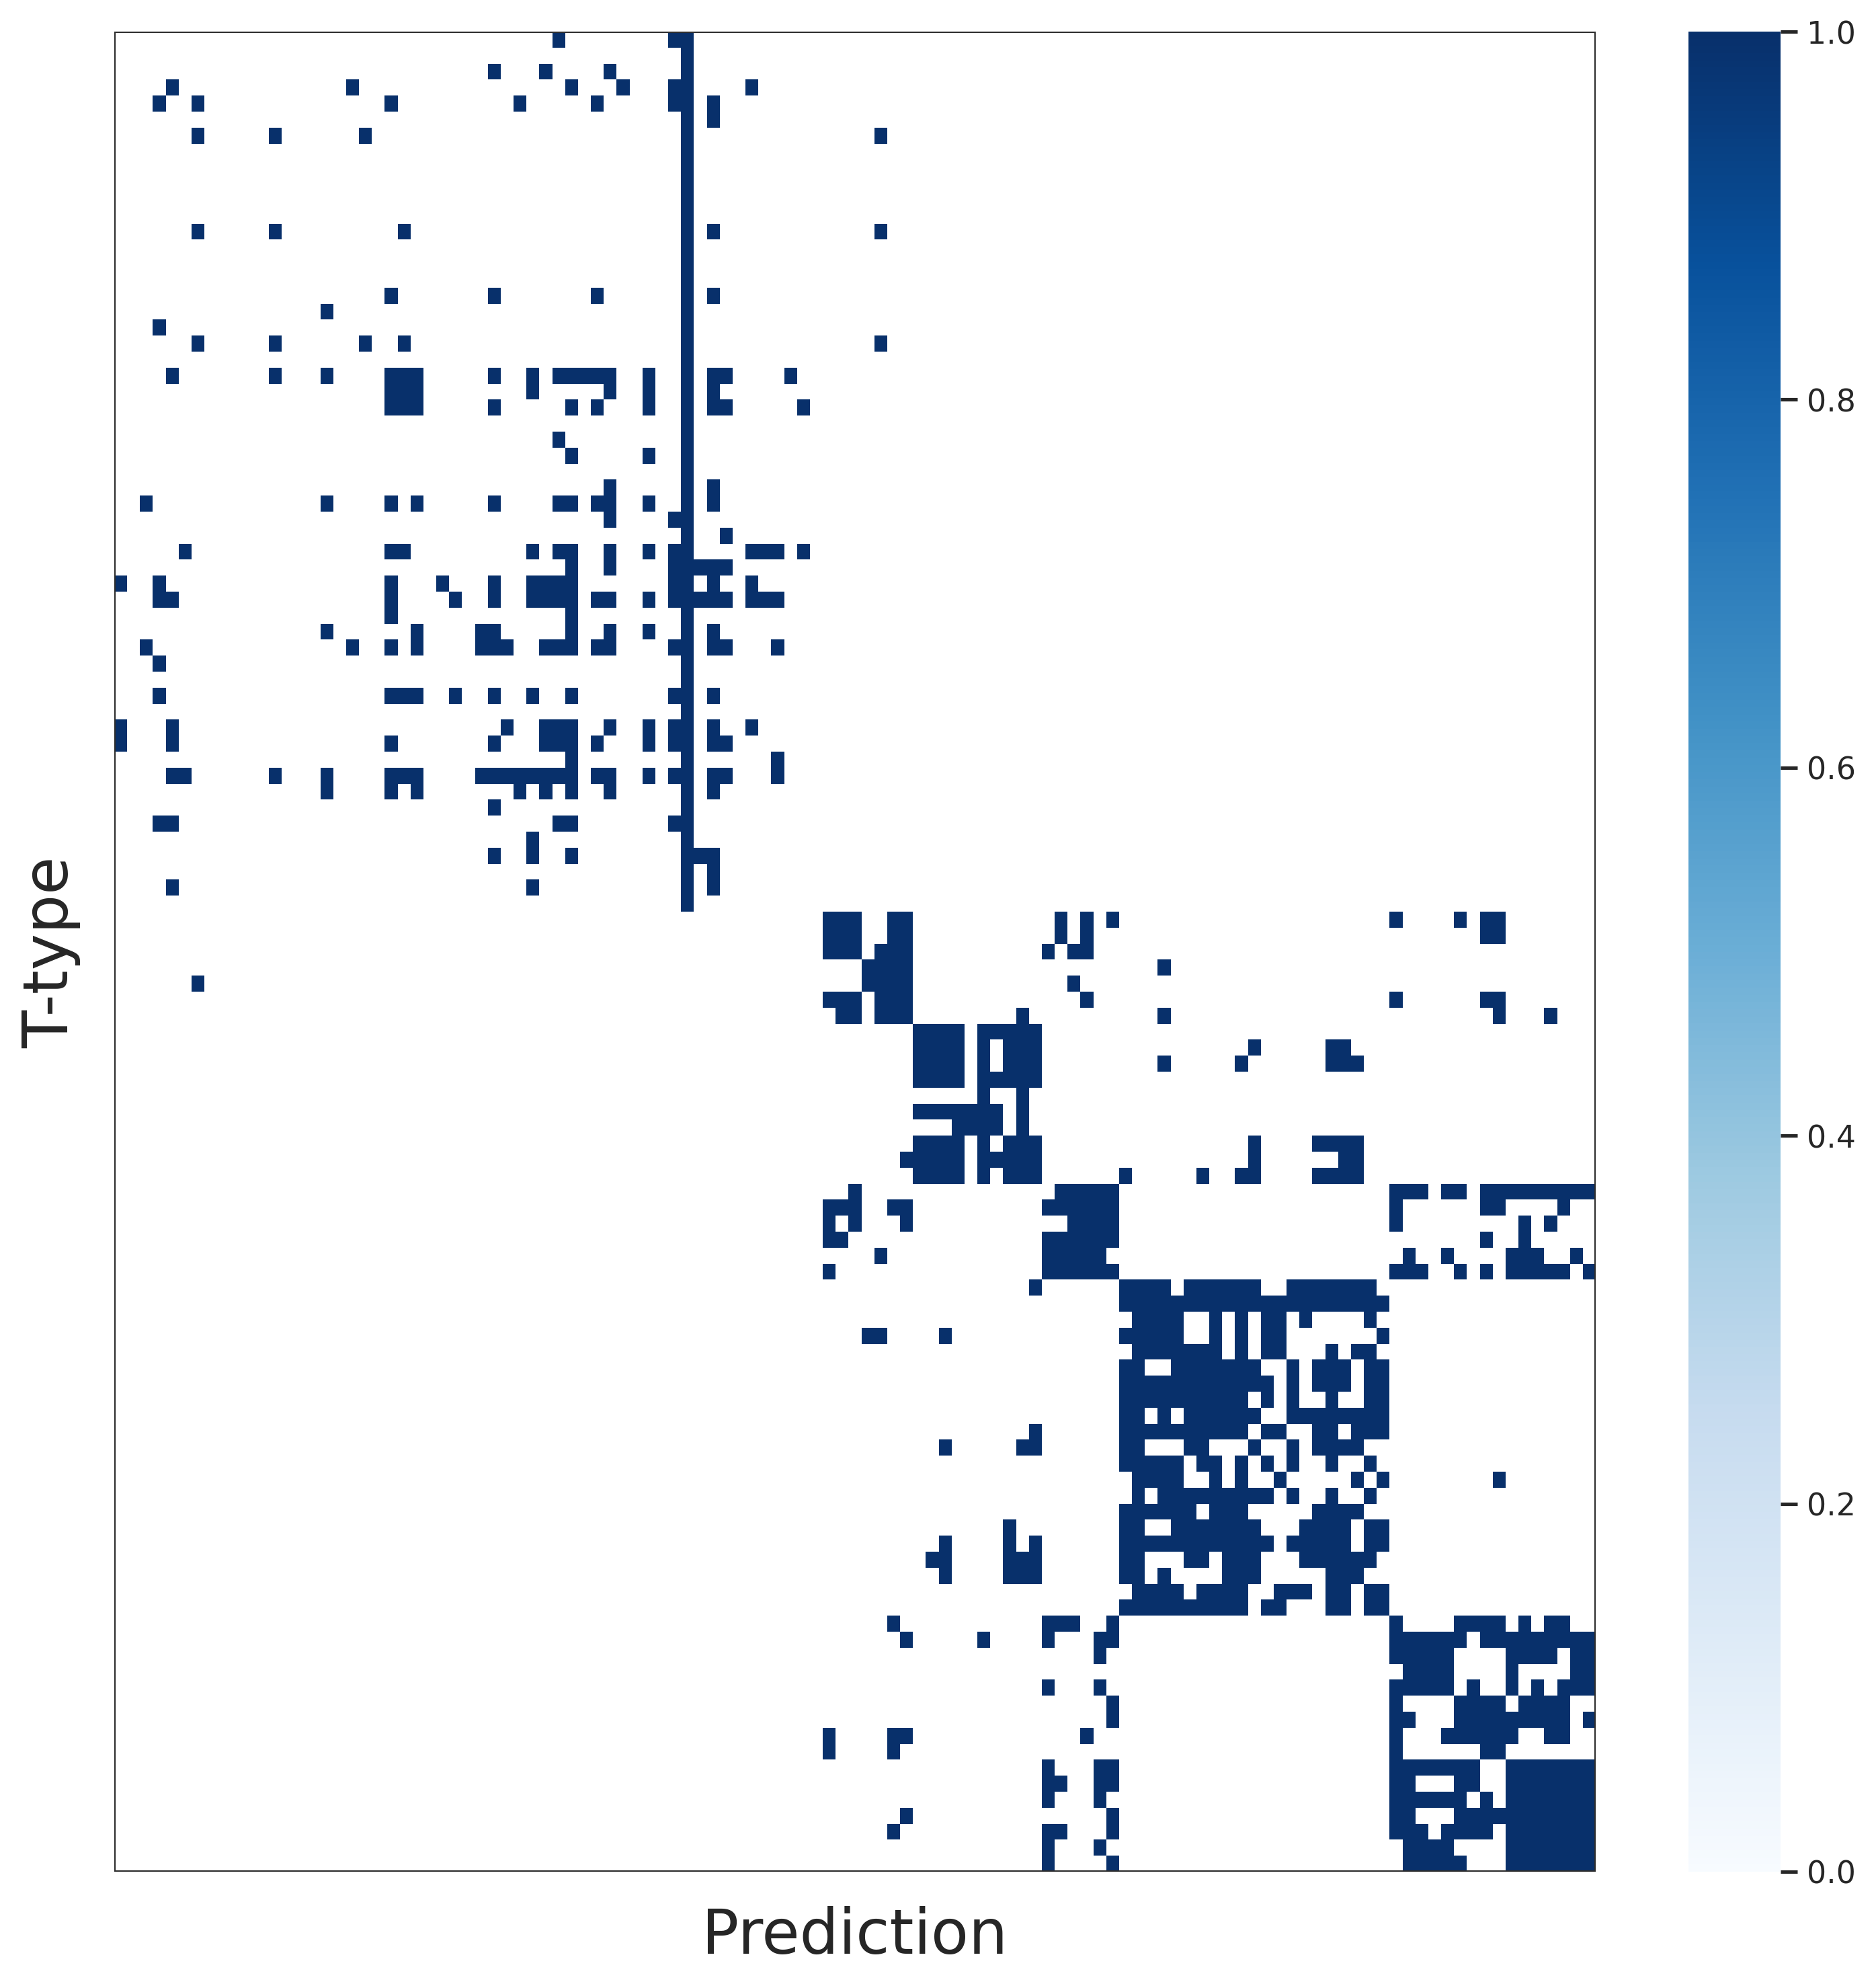

[REVIEW] confusion matrix heatmap -- expect a tight diagonal (conf_Ttype_lowD_arm_1.png). Large square blocks along the diagonal mean many reference types are collapsing into one predicted category
  --- conf_Ttype_lowD_arm_1.png


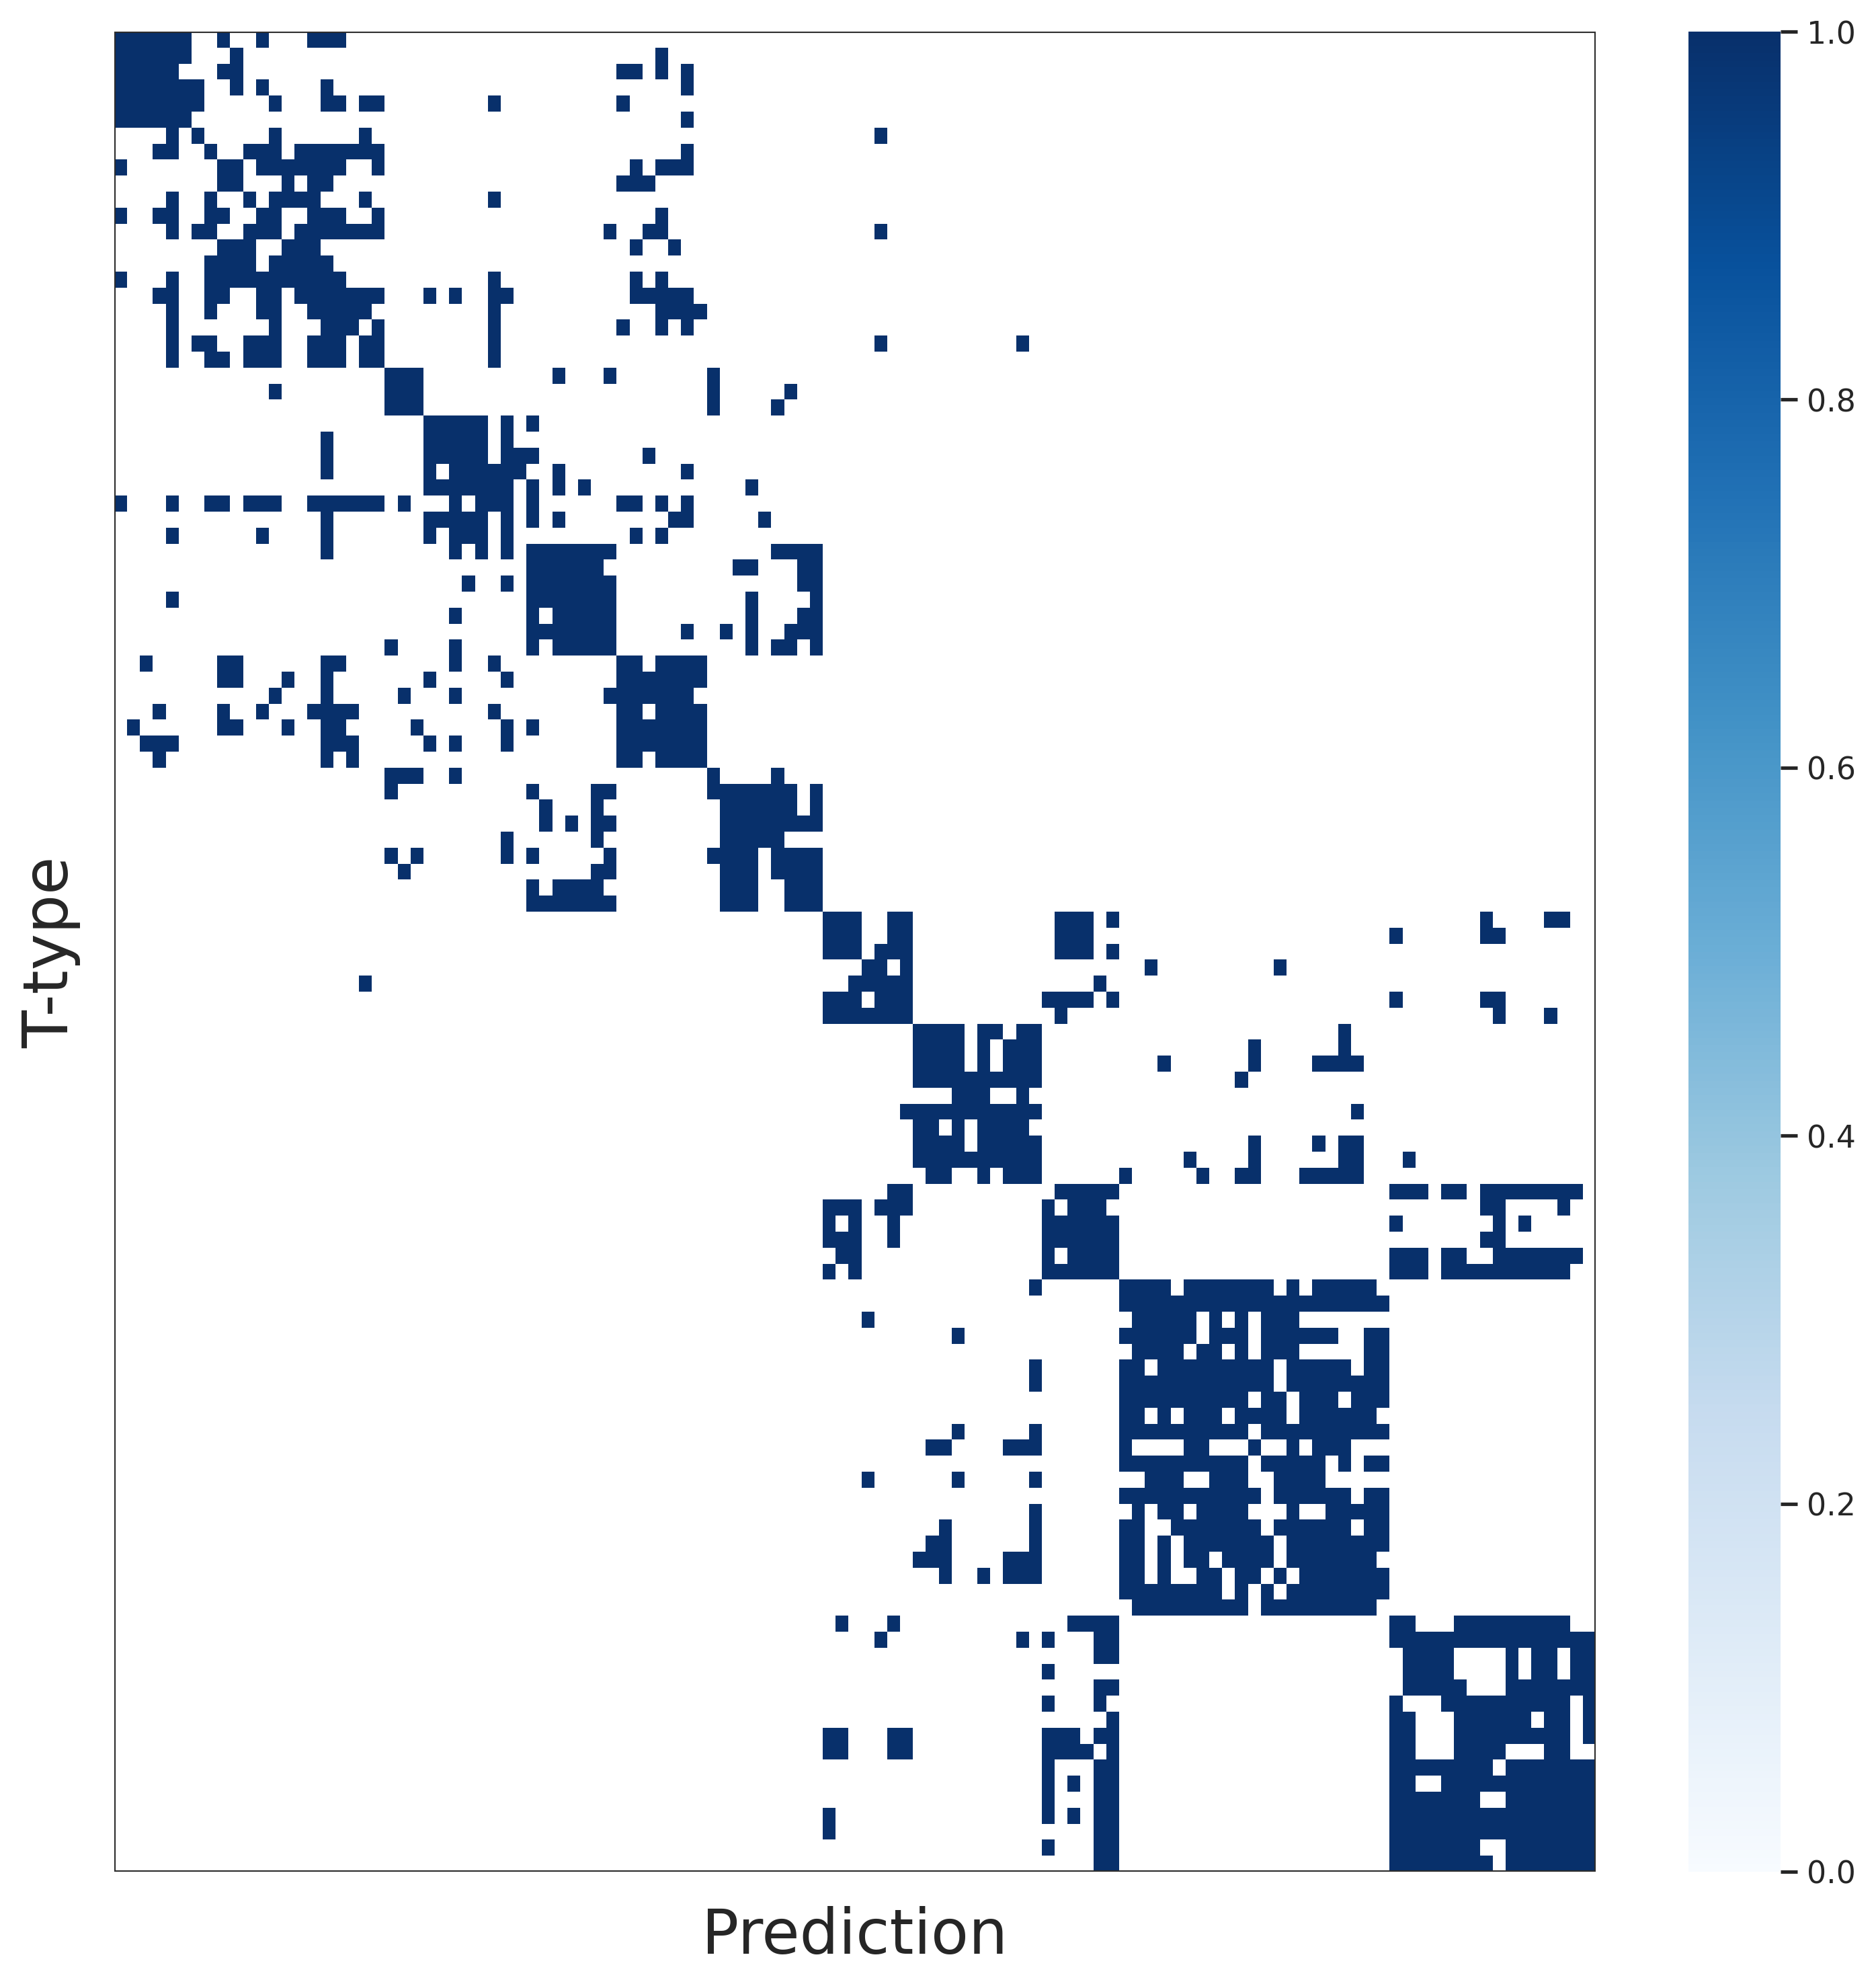

[REVIEW] confusion matrix heatmap -- expect a tight diagonal (conf_Ttype_pc.png). Large square blocks along the diagonal mean many reference types are collapsing into one predicted category
  --- conf_Ttype_pc.png


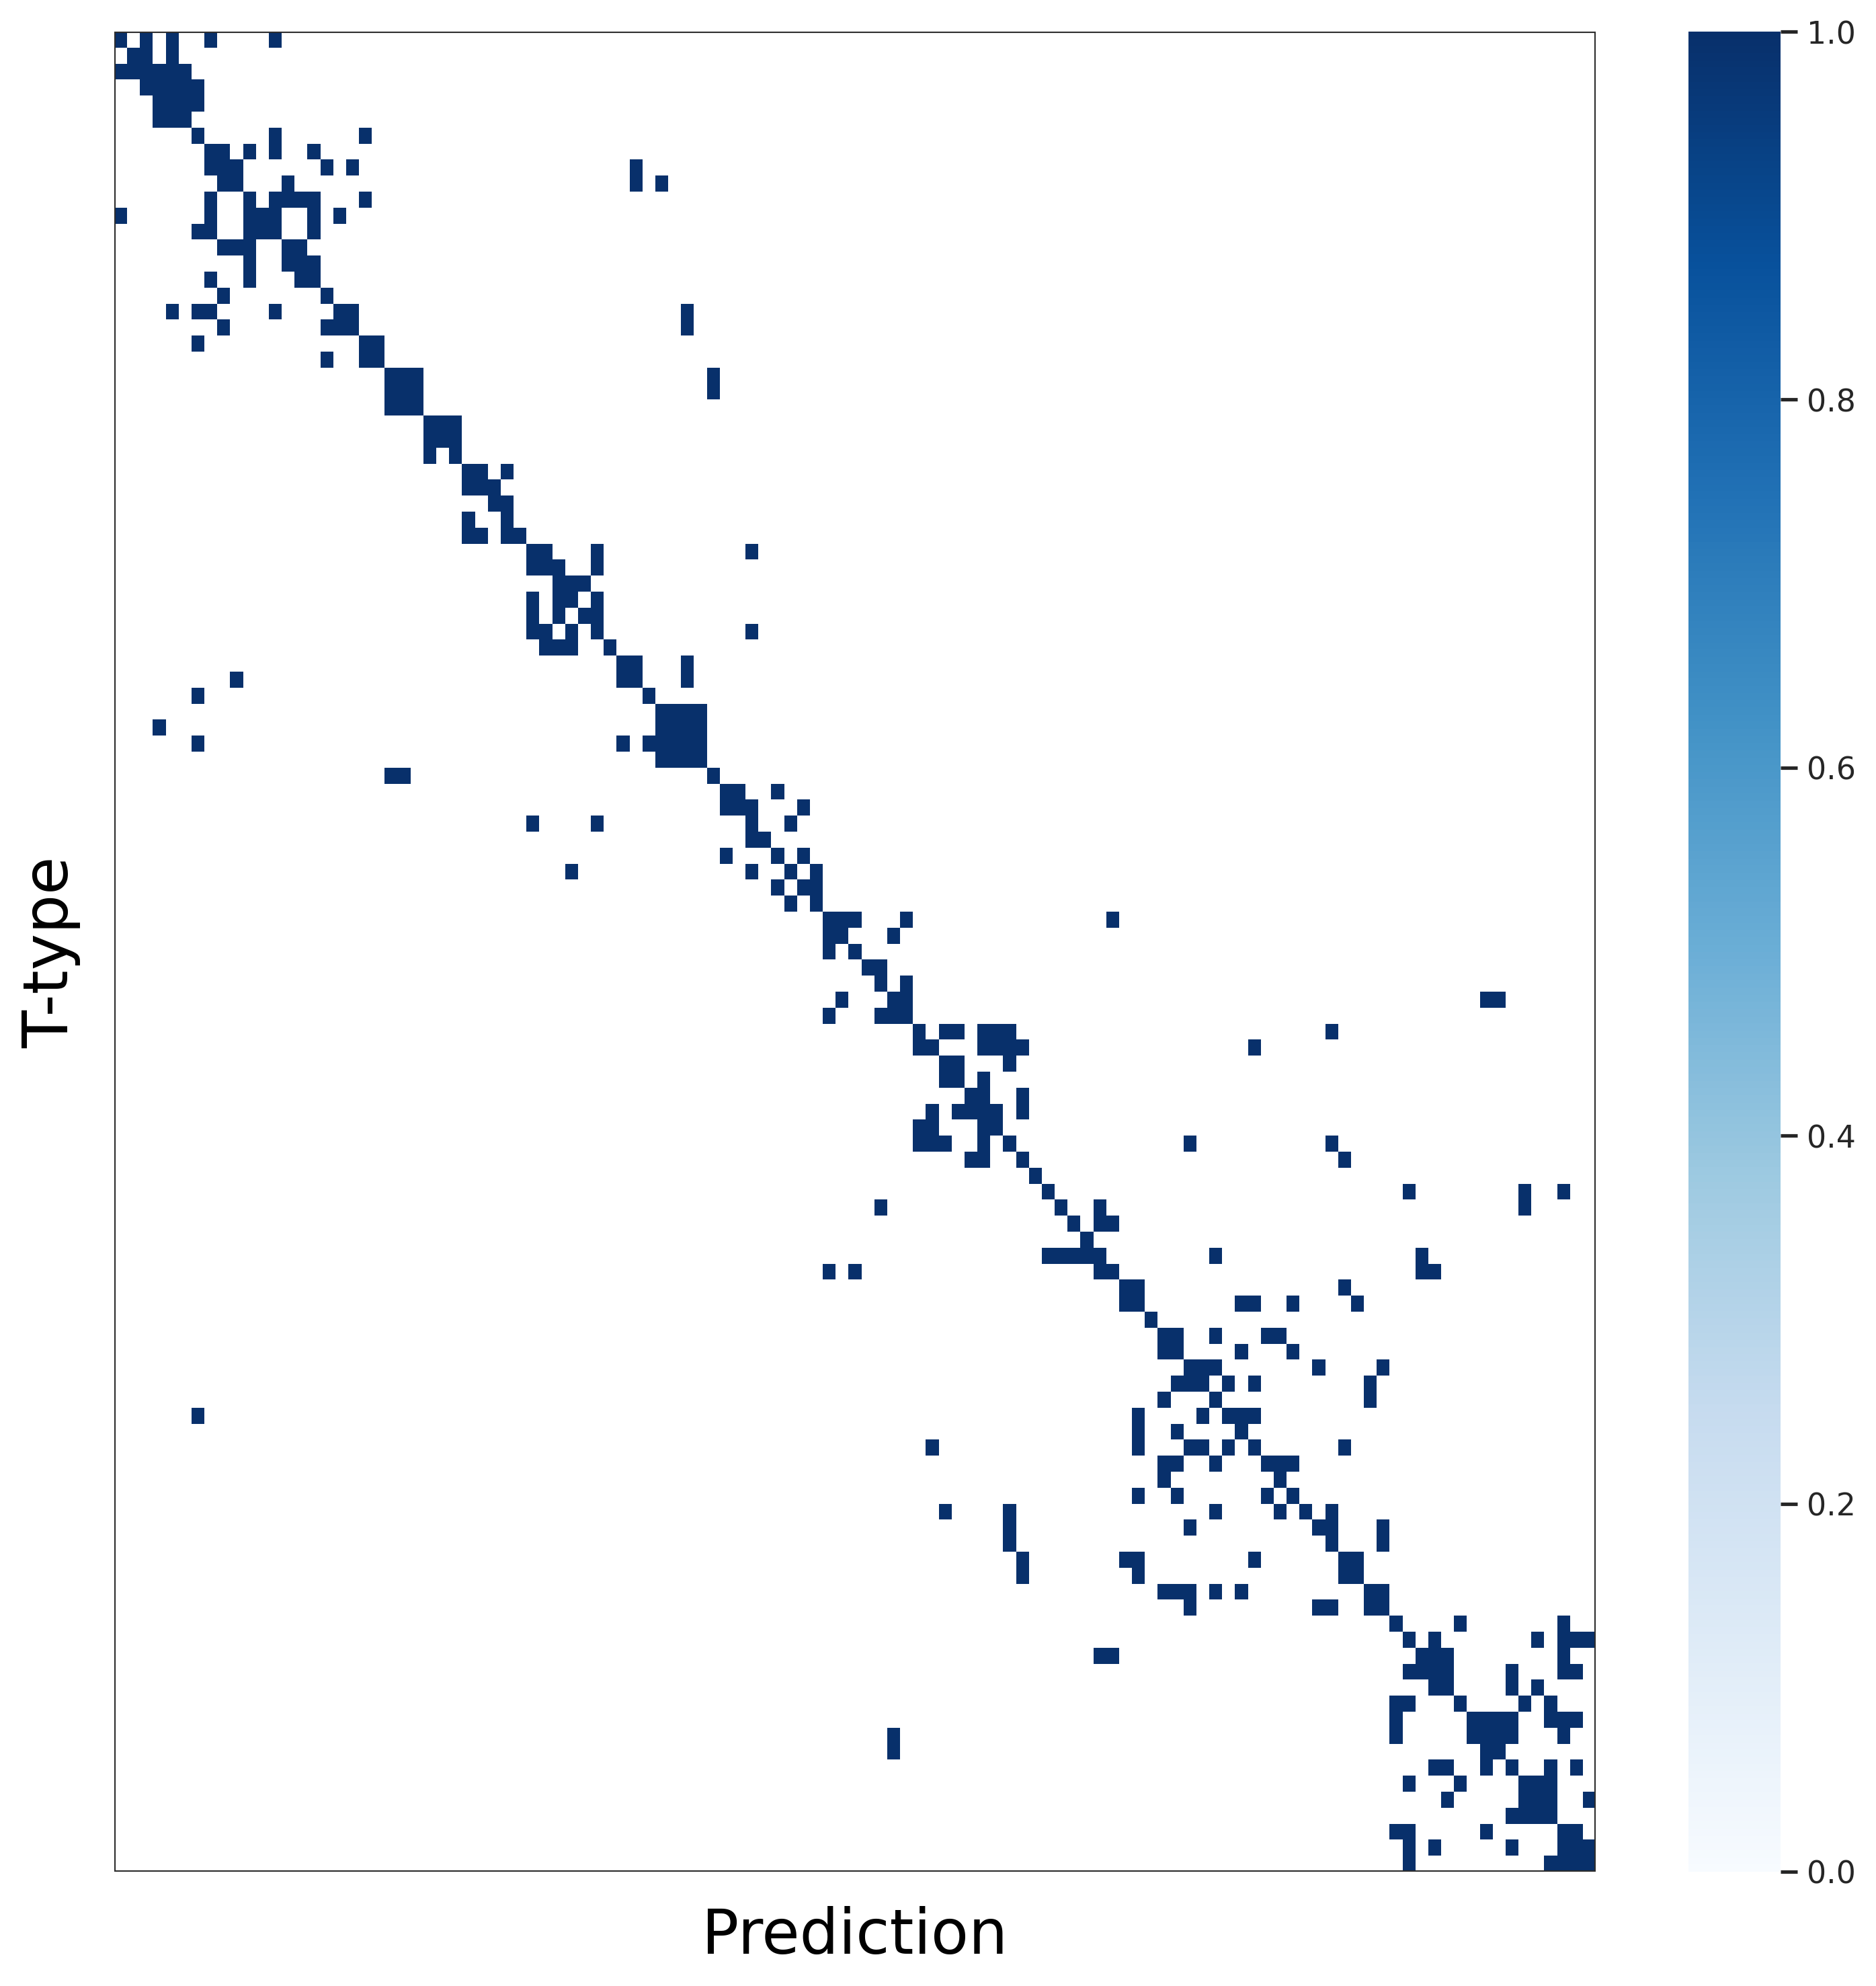

In [21]:
clust_figure_paths = resolve_paths(CONFIG["analyze"]["clusterability_figures"], pattern="*.png")
print(f"Found {len(clust_figure_paths)} clusterability figures")

for p in clust_figure_paths:
    name = os.path.basename(p)
    if name.startswith("classAcc_RF"):
        review(
            "RF classification accuracy bar chart",
            "read the 't-types' group only: that is the MMIDAS lowD embedding vs "
            "the PCA baseline at recovering the reference labels. The "
            "'T Categories' groups classify the model's own labels, so ~99% "
            "there is near-circular and not evidence of anything",
        )
    elif name.startswith("SC_K_"):
        review(
            "silhouette score curve",
            "most categories should have positive silhouette scores, and the "
            "MMIDAS curves should sit near the t-type reference curve. If the "
            "x-axis spans a single value or the legend has one entry per "
            "category, the figure is broken rather than the model",
        )
    elif name.startswith("conf_"):
        review(
            "confusion matrix heatmap",
            f"expect a tight diagonal ({name}). Large square blocks along the "
            f"diagonal mean many reference types are collapsing into one "
            f"predicted category",
        )
    show_image(p, title=name)

### Optional: numeric accuracy/silhouette check

Only runs if you supplied `classify_manifest` / `clustering_tar` in the config above (these are
intermediate outputs of the 03b Classify task, not part of `MMIDAS_Analyze`'s final outputs).

This is the most informative cell in the notebook, because it reads the numbers the
`classAcc_RF` / `SC_K_*` figures are drawn from. Two things come out of it:

1. **The t-type accuracy gap.** How much worse the MMIDAS low-D embedding is than the PCA
   baseline at recovering the reference t-types. This is the only non-circular accuracy
   comparison available — the `ConsType` rows classify the model's own labels.
2. **The populated-category count**, from the side length of the `ConsType` confusion matrices.
   For a healthy run this is close to `model_order`; a 9×9 matrix under a reported
   `model_order` of 111 means 102 categories are empty.

In [22]:
classify_cfg = CONFIG["classify_optional"]

if classify_cfg["classify_manifest"] and classify_cfg["clustering_tar"]:
    classify_manifest = load_json_gcs(classify_cfg["classify_manifest"])
    clustering_root = extract_tar_gcs(classify_cfg["clustering_tar"], "clustering")

    # name -> (mean accuracy, pct positive silhouette, confusion-matrix size)
    metrics = {}
    for pickle_path in classify_manifest["pickles"]:
        local_pickle = os.path.join(clustering_root, "clustering", os.path.basename(pickle_path))
        if not os.path.exists(local_pickle):
            print(f"  (skipping, not found locally: {os.path.basename(pickle_path)})")
            continue
        with open(local_pickle, "rb") as fh:
            data = pickle.load(fh)
        acc = data["acc_T_adj"]
        sc_flat = np.concatenate([np.atleast_1d(s) for s in data["sc_T"]])
        conf = np.asarray(data["conf_mat"])
        name = os.path.basename(pickle_path)
        metrics[name] = {
            "acc": float(acc.mean()),
            "acc_sd": float(acc.std()),
            "pct_pos_sc": float(100 * (sc_flat > 0).mean()),
            "n_cat": int(conf.shape[0]),
        }
        print(
            f"{name}: mean acc={acc.mean():.3f} (+/-{acc.std():.3f}), "
            f"pct categories w/ positive silhouette={100 * (sc_flat > 0).mean():.1f}%, "
            f"conf_mat={conf.shape[0]}x{conf.shape[1]}"
        )

    # ----------------------------------------------------------------------
    # The ConsType rows classify the model's own labels, so their ~99% accuracy
    # is near-circular and says nothing about model quality. The one meaningful
    # comparison is how well each embedding recovers the *reference* t-types.
    # ----------------------------------------------------------------------
    def _pick(prefix, contains=None):
        for name, m in metrics.items():
            if name.startswith(prefix) and (contains is None or contains in name):
                return name, m
        return None, None

    pca_name, pca = _pick("Ttype_classification", "nFeature_100")
    lowd = {n: m for n, m in metrics.items()
            if n.startswith("Ttype_classification") and "nFeature_100" not in n}

    if pca and lowd:
        gap_limit = CONFIG["expected"]["max_ttype_acc_gap"]
        best_lowd_name = max(lowd, key=lambda n: lowd[n]["acc"])
        best_lowd = lowd[best_lowd_name]
        gap = pca["acc"] - best_lowd["acc"]
        print(
            f"\nt-type recovery: PCA baseline={pca['acc']:.3f}, "
            f"best MMIDAS lowD={best_lowd['acc']:.3f} ({best_lowd_name}), "
            f"gap={gap:.3f}"
        )
        check(
            f"MMIDAS lowD recovers t-types within {gap_limit:.2f} of the PCA baseline",
            gap <= gap_limit,
            f"PCA={pca['acc']:.3f}, MMIDAS={best_lowd['acc']:.3f}, gap={gap:.3f} "
            f"(limit {gap_limit:.2f})",
        )
    else:
        review(
            "could not locate both Ttype PCA and Ttype lowD pickles",
            "skipping the t-type accuracy comparison",
        )

    # ----------------------------------------------------------------------
    # Derive the populated-category count from the ConsType confusion matrices.
    # Their side length is the number of categories cells were actually assigned
    # to, which is the ground truth for the collapse check above (and the only
    # source of it for runs predating n_populated_categories).
    # ----------------------------------------------------------------------
    cons_sizes = {n: m["n_cat"] for n, m in metrics.items()
                  if n.startswith("ConsType_classification")}
    if cons_sizes:
        derived_populated = max(cons_sizes.values())
        print(f"\npopulated categories implied by ConsType confusion matrices: "
              f"{sorted(set(cons_sizes.values()))} -> using {derived_populated}")
        min_frac = CONFIG["expected"]["min_populated_frac"]
        check(
            f"ConsType confusion matrices span at least {min_frac:.0%} of model_order",
            derived_populated >= min_frac * model_order,
            f"{derived_populated} populated of model_order={model_order} "
            f"({derived_populated / model_order:.1%})",
        )
        if n_populated is not None:
            check(
                "evaluation_results n_populated_categories agrees with the "
                "ConsType confusion matrices",
                derived_populated == n_populated,
                f"evaluation_results={n_populated}, ConsType={derived_populated}",
            )
else:
    print(
        "classify_manifest / clustering_tar not provided -- skipping numeric accuracy/silhouette "
        "checks. Relying on the figures above for a visual review instead."
    )

Ttype_classification_K_115_nFeature_100_20260810.p: mean acc=0.909 (+/-0.006), pct categories w/ positive silhouette=95.7%, conf_mat=115x115
Ttype_classification_K_115_nFeature_10_arm_0_20260810.p: mean acc=0.314 (+/-0.008), pct categories w/ positive silhouette=3.5%, conf_mat=115x115
ConsType_classification_K_120_nFeature_100_arm_0_20260810.p: mean acc=0.949 (+/-0.007), pct categories w/ positive silhouette=87.5%, conf_mat=8x8
ConsType_classification_K_120_nFeature_10_arm_0_20260810.p: mean acc=0.989 (+/-0.002), pct categories w/ positive silhouette=100.0%, conf_mat=8x8
Ttype_classification_K_115_nFeature_10_arm_1_20260810.p: mean acc=0.431 (+/-0.009), pct categories w/ positive silhouette=6.1%, conf_mat=115x115
ConsType_classification_K_120_nFeature_100_arm_1_20260810.p: mean acc=0.953 (+/-0.004), pct categories w/ positive silhouette=54.5%, conf_mat=11x11
ConsType_classification_K_120_nFeature_10_arm_1_20260810.p: mean acc=0.995 (+/-0.002), pct categories w/ positive silhouette=90.9

## Stage 3 -- Analyze: State Traversal (`state_traversal_manifest.json` + figures)

Checks `model_order` consistency, that the categories the traversal was run for actually have
cells assigned to them (and were picked largest-first rather than by index), that KEGG pathway
mapping produced something when a `kegg_toml` was supplied, and that the per-category figures
differ from one another rather than being one plot rendered ten times under different titles.

In [23]:
state_manifest = load_json_gcs(CONFIG["analyze"]["state_traversal_manifest"])
print(json.dumps(state_manifest, indent=2))

check(
    "state_traversal model_order matches Train's evaluation_results",
    state_manifest["model_order"] == model_order,
    f"state_traversal={state_manifest['model_order']}, train={model_order}",
)

n_selected_cats = state_manifest["n_selected_cats"]
selected_c = state_manifest["selected_c"]

# Counting entries in selected_c only confirms the list has the requested length.
# It passed on a run where all ten selected categories were empty, so the checks
# below look at what those categories contain.
check(
    "state_traversal ran for the requested number of categories",
    len(selected_c) == n_selected_cats or n_selected_cats == 0,
    f"selected_c has {len(selected_c)} entries, n_selected_cats={n_selected_cats}",
)

check(
    "n_selected_cats matches the configured input",
    n_selected_cats == CONFIG["expected"]["n_selected_cats"]
    or CONFIG["expected"]["n_selected_cats"] == 0,
    f"got {n_selected_cats}, configured "
    f"{CONFIG['expected']['n_selected_cats']}",
)

# ---------------------------------------------------------------------------
# Are the selected categories actually populated?
# ---------------------------------------------------------------------------
sel_counts = state_manifest.get("selected_c_n_cells")
if sel_counts is None:
    review(
        "selected_c_n_cells absent from state_traversal_manifest.json",
        "run predates this field -- the figure-content check below is the only "
        "guard that the selected categories were not empty",
    )
else:
    print(f"\ncells per selected category: "
          + ", ".join(f"{c}={n}" for c, n in zip(selected_c, sel_counts)))
    check(
        "every selected category has cells assigned to it",
        all(n > 0 for n in sel_counts),
        f"empty categories: "
        f"{[c for c, n in zip(selected_c, sel_counts) if n == 0]}",
    )
    check(
        "selected categories were ranked by size (largest first)",
        list(sel_counts) == sorted(sel_counts, reverse=True),
        f"counts in listed order: {list(sel_counts)}",
    )

n_pop_state = state_manifest.get("n_populated_categories")
if n_pop_state is not None:
    min_frac = CONFIG["expected"]["min_populated_frac"]
    check(
        f"state_traversal sees at least {min_frac:.0%} of active categories populated",
        n_pop_state >= min_frac * state_manifest.get("n_active_categories", model_order),
        f"{n_pop_state} populated of "
        f"{state_manifest.get('n_active_categories', model_order)} active",
    )

# ---------------------------------------------------------------------------
# KEGG pathway figures
#
# n_pathways == 0 with a kegg_toml supplied means gene-name lookup failed, not
# that the pathways were empty -- MMIDAS's loader read gene identifiers from the
# wrong AnnData attribute and silently mapped nothing.
# ---------------------------------------------------------------------------
n_pathways = state_manifest.get("n_pathways", 0)
if CONFIG["expected"]["kegg_toml_supplied"]:
    check(
        "KEGG pathways were mapped (kegg_toml was supplied)",
        n_pathways > 0,
        f"n_pathways={n_pathways} -- check the TraversalPrep log for "
        f"'0 genes' or 'KEGG: 0 pathways'",
    )
    check(
        "pathway figures were produced",
        len(state_manifest.get("pathway_figs", [])) > 0,
        f"{len(state_manifest.get('pathway_figs', []))} pathway figures",
    )
else:
    print(f"\nkegg_toml not supplied -- n_pathways={n_pathways} as expected.")

InvalidUrlError: Unrecognized scheme "	gs".


CalledProcessError: Command '['gsutil', '-q', 'cp', '\tgs://fc-a4e31a4b-8622-422a-94fc-fc9899e4546c/submissions/4a93ff38-fbd7-4c34-8073-9bda9770a2e5/MMIDAS_Analyze/eb571efa-2470-4a43-8a65-fc62644084ed/call-StateTraversal/out/state_traversal_manifest.json', '/tmp/mmidas_validation/710b01fbe6/state_traversal_manifest.json']' returned non-zero exit status 1.

Found 37 state traversal figures
37 distinct figure contents across 37 figures
[PASS] state traversal figures are not duplicates of each other
[REVIEW] state traversal figure -- the highlighted category should be a visible cluster of coloured points, and the black traversal path should trace a curve through it rather than collapse to a single dot
  --- pathway_summary_c_101.png


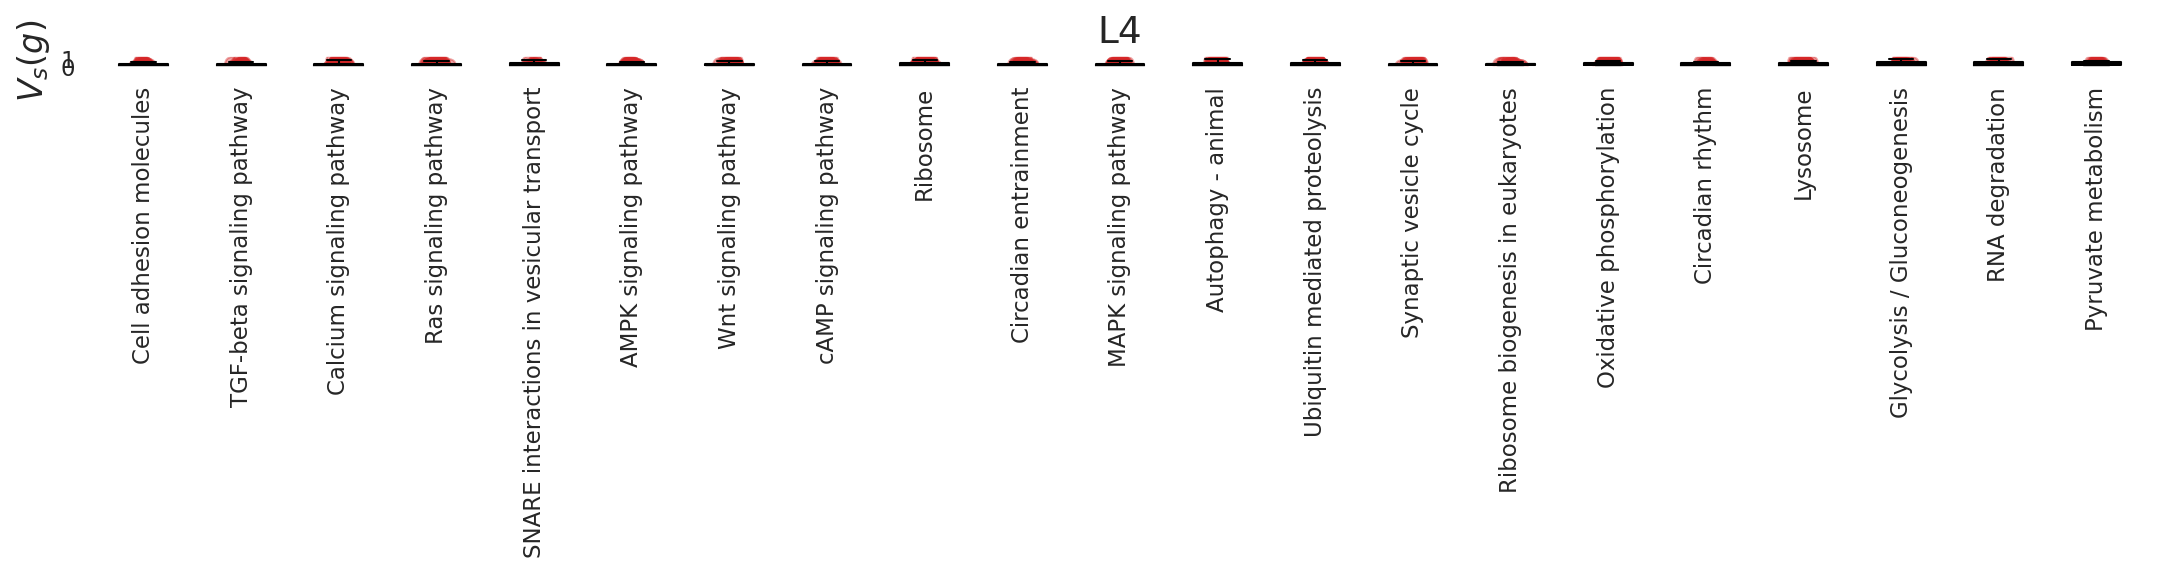

[REVIEW] state traversal figure -- the highlighted category should be a visible cluster of coloured points, and the black traversal path should trace a curve through it rather than collapse to a single dot
  --- pathway_summary_c_120.png


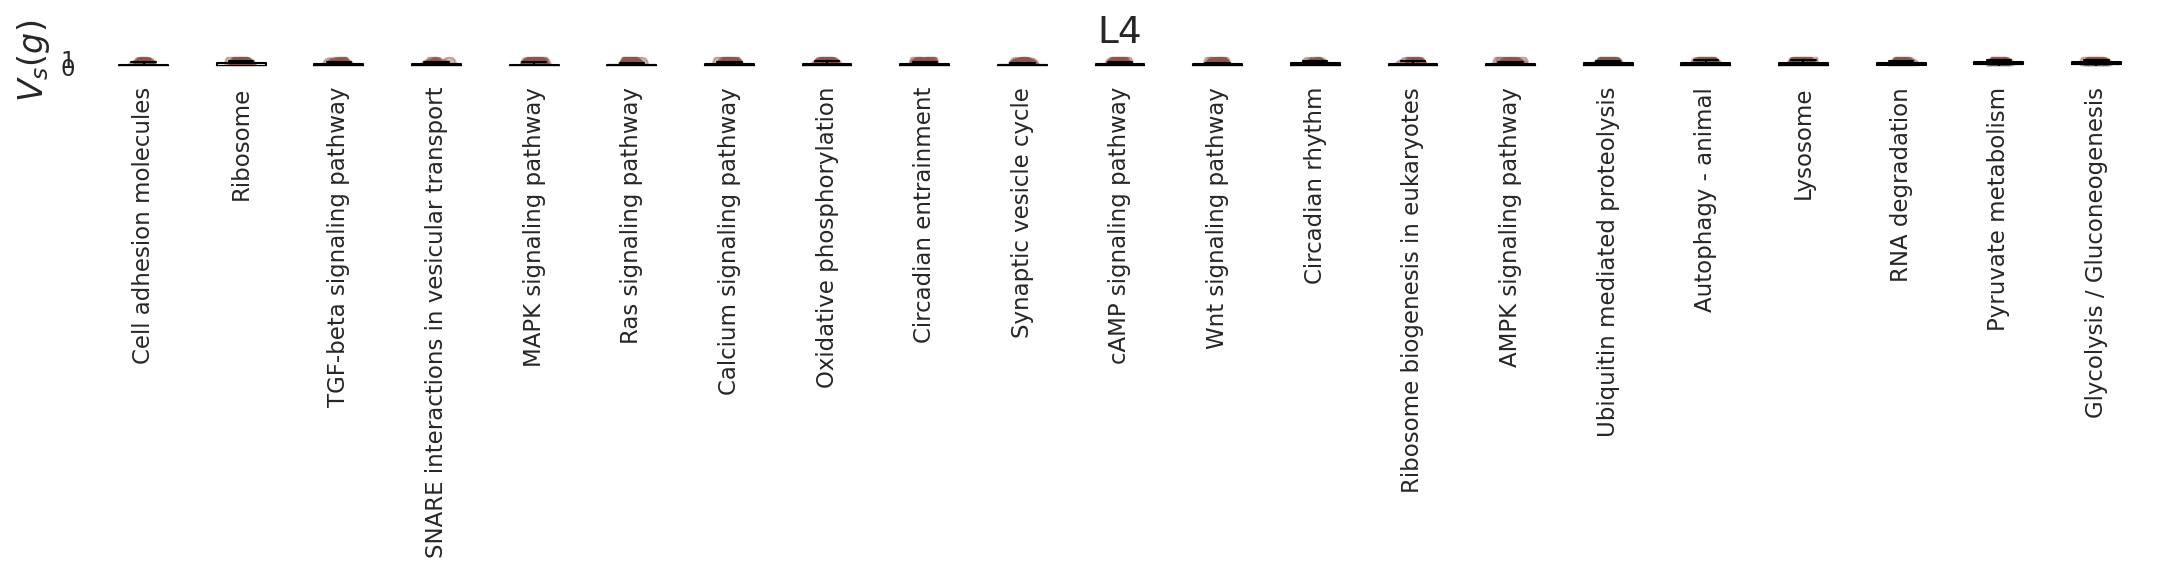

[REVIEW] state traversal figure -- the highlighted category should be a visible cluster of coloured points, and the black traversal path should trace a curve through it rather than collapse to a single dot
  --- pathway_summary_c_24.png


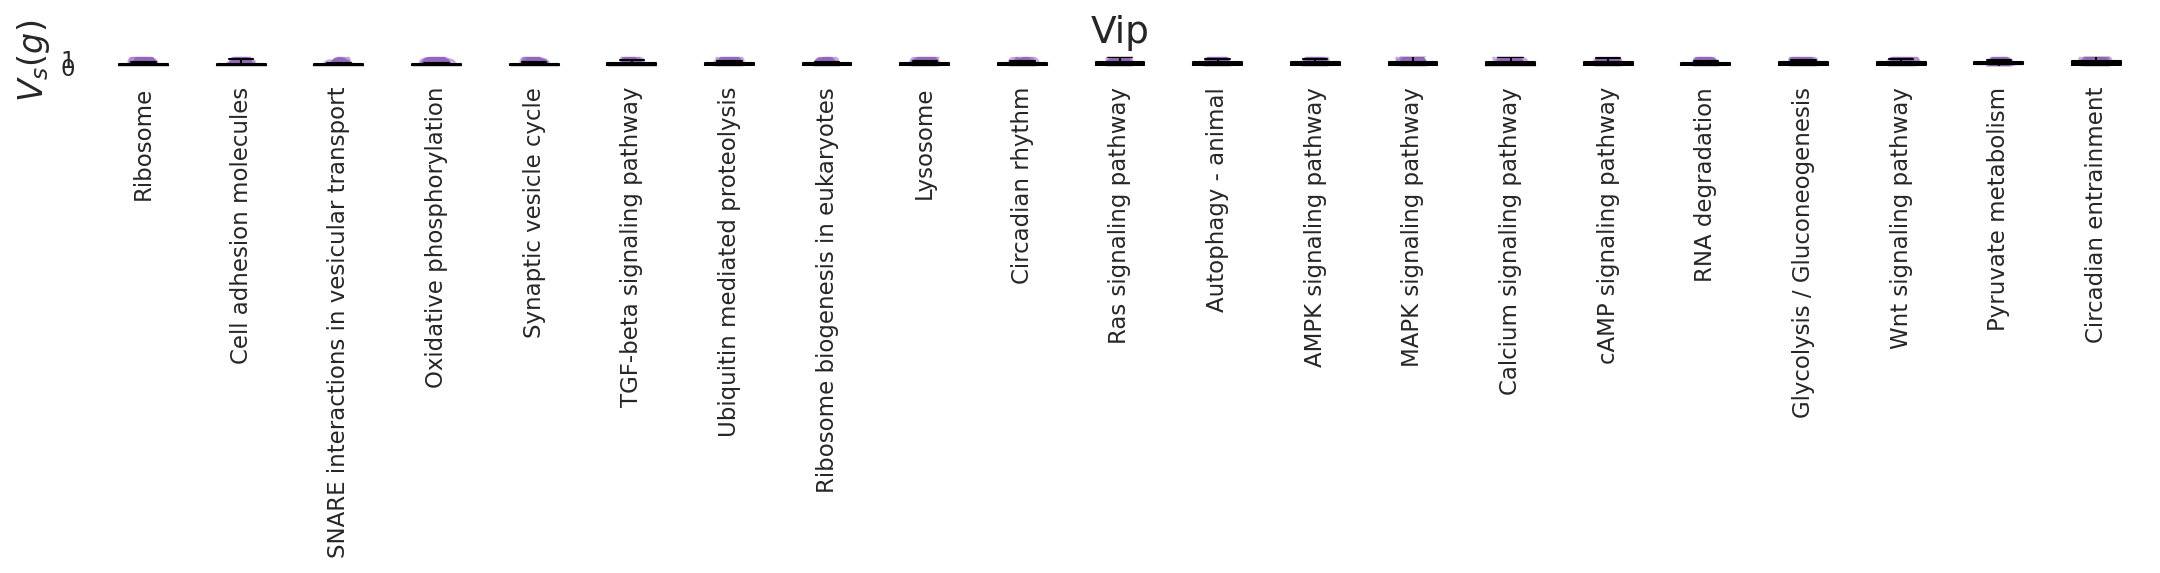

[REVIEW] state traversal figure -- the highlighted category should be a visible cluster of coloured points, and the black traversal path should trace a curve through it rather than collapse to a single dot
  --- pathway_summary_c_44.png


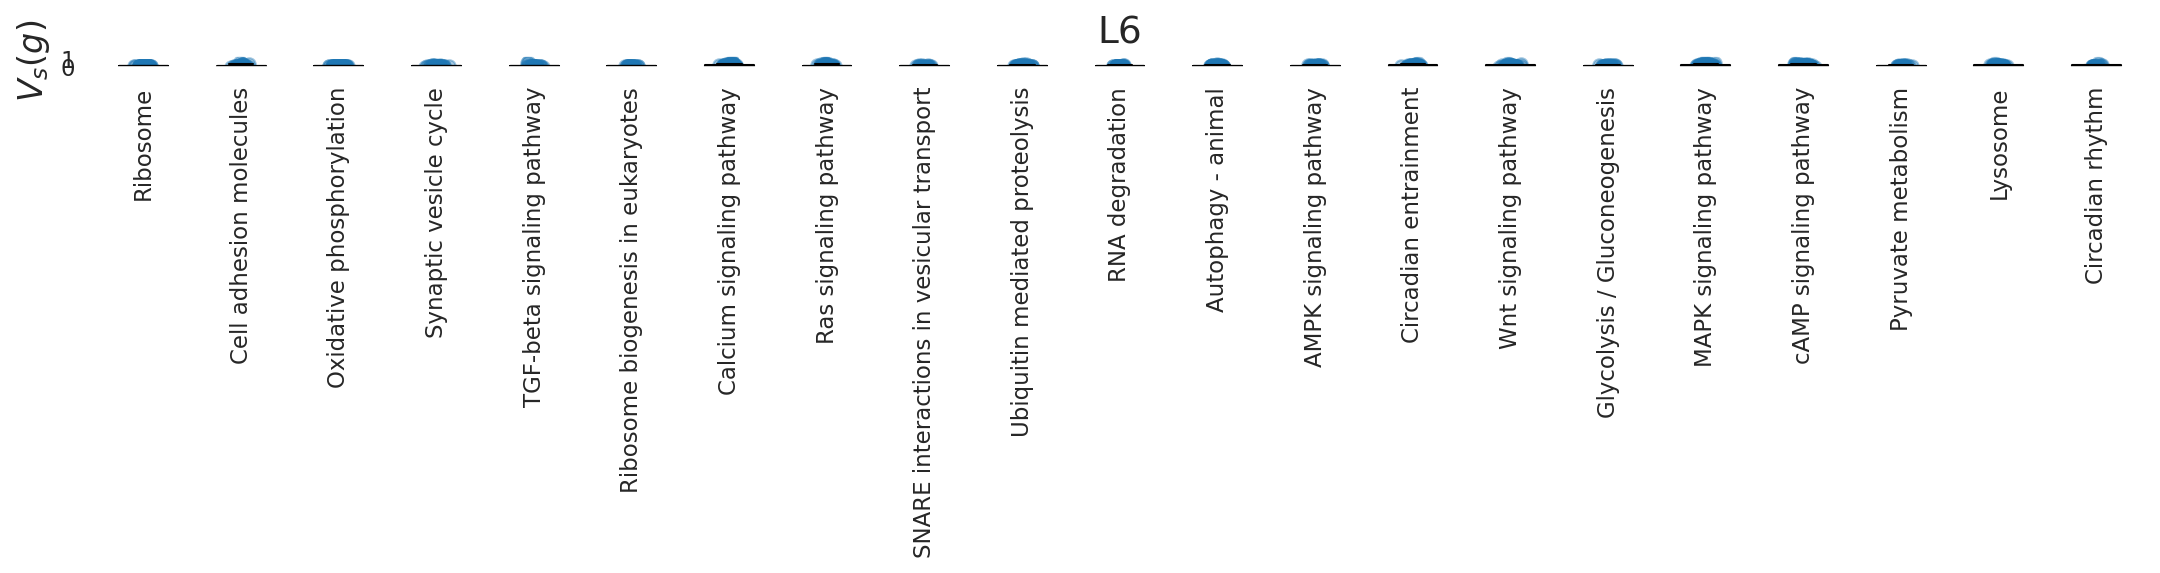

[REVIEW] state traversal figure -- the highlighted category should be a visible cluster of coloured points, and the black traversal path should trace a curve through it rather than collapse to a single dot
  --- pathway_summary_c_52.png


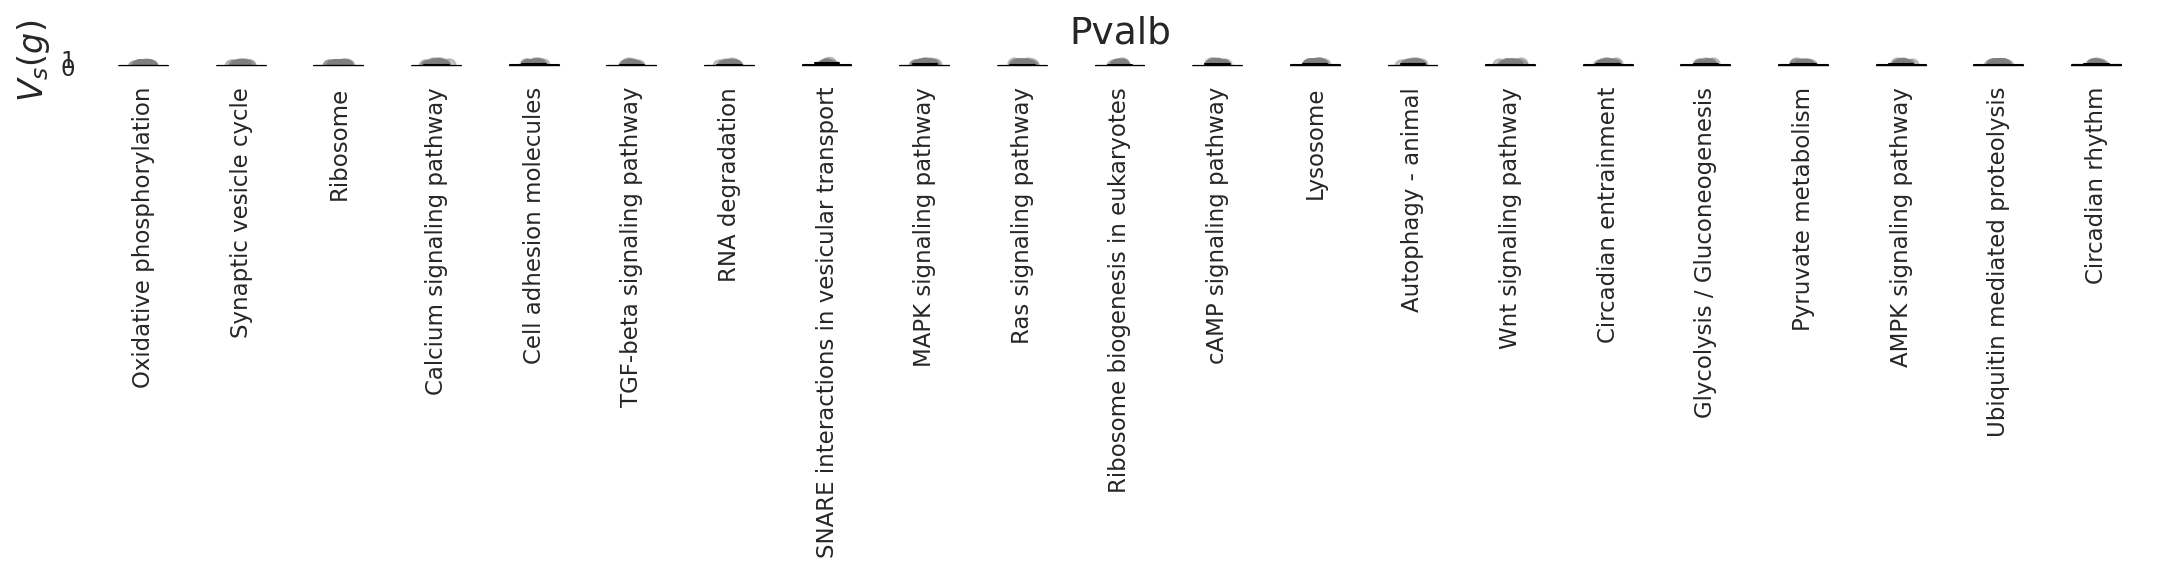

[REVIEW] state traversal figure -- the highlighted category should be a visible cluster of coloured points, and the black traversal path should trace a curve through it rather than collapse to a single dot
  --- pathway_summary_c_86.png


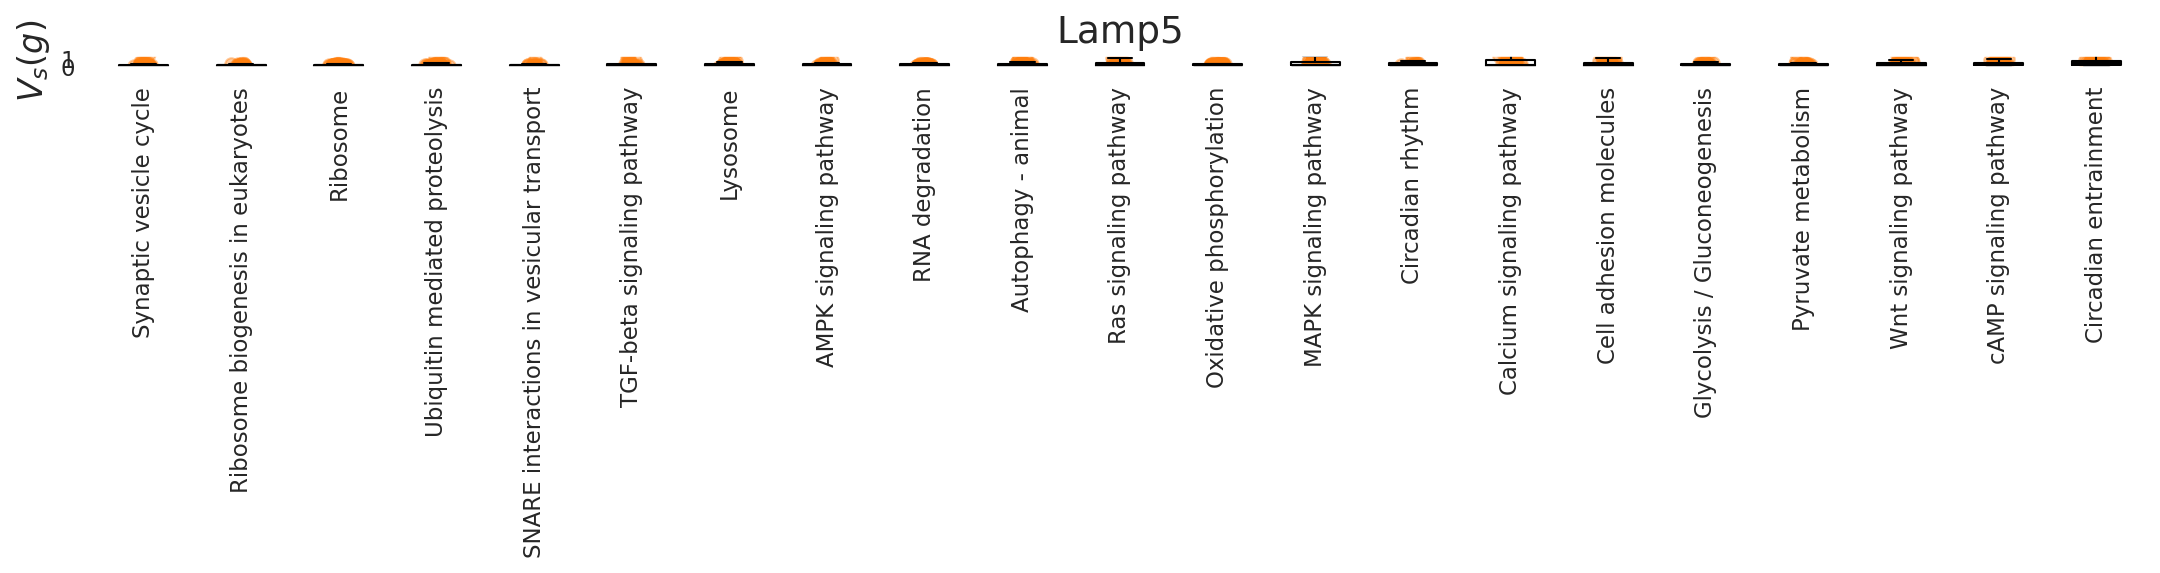

[REVIEW] state traversal figure -- the highlighted category should be a visible cluster of coloured points, and the black traversal path should trace a curve through it rather than collapse to a single dot
  --- pathway_summary_c_93.png


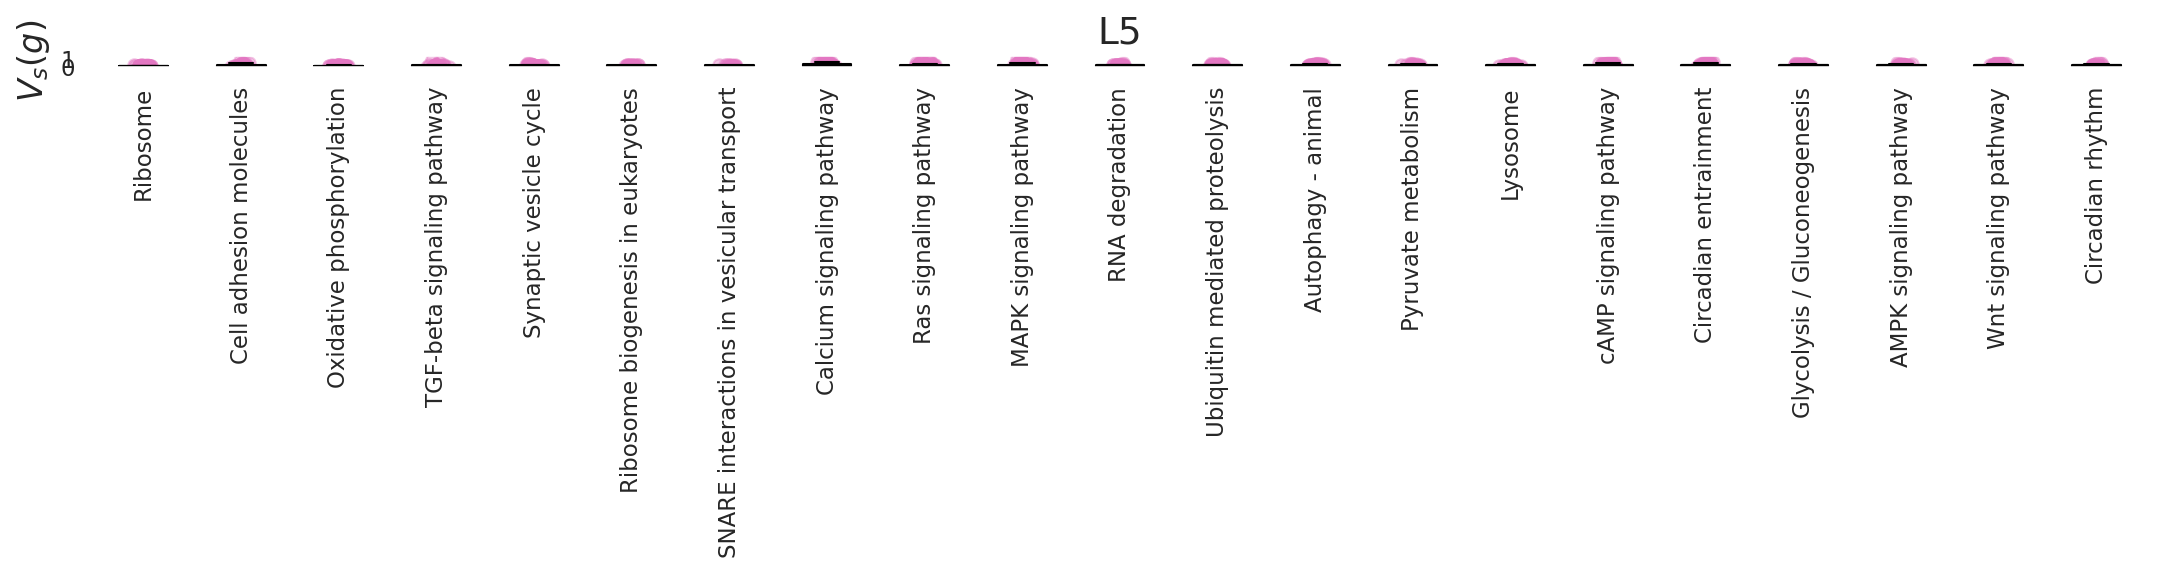

[REVIEW] state traversal figure -- the highlighted category should be a visible cluster of coloured points, and the black traversal path should trace a curve through it rather than collapse to a single dot
  --- pathway_summary_c_98.png


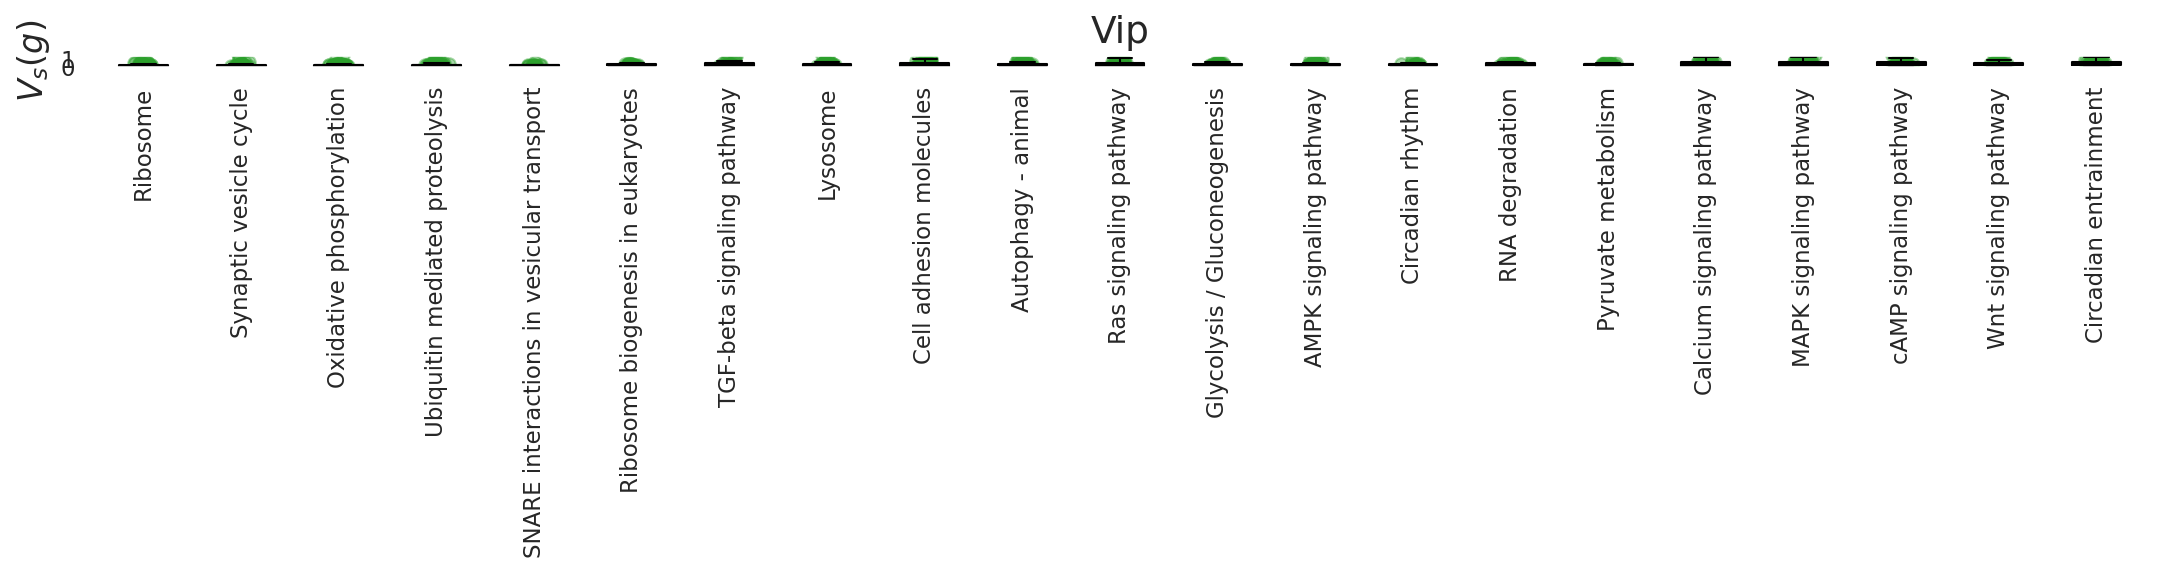

... and 29 more not shown (raise N_TO_SHOW to see more)


In [24]:
state_figure_paths = resolve_paths(CONFIG["analyze"]["state_traversal_figures"], pattern="*.png")
print(f"Found {len(state_figure_paths)} state traversal figures")

# ---------------------------------------------------------------------------
# Per-category figures must actually differ from one another.
#
# A previous run emitted ten figures for ten categories with no cells assigned.
# Every figure was the same background scatter with a degenerate traversal path
# collapsed to a single point, identical below the title band. File bytes differ
# (the titles differ), so only a pixel comparison catches it.
# ---------------------------------------------------------------------------
hashes = {}
for p in state_figure_paths:
    hashes.setdefault(image_content_hash(p), []).append(os.path.basename(p))

duplicate_groups = {h: names for h, names in hashes.items() if len(names) > 1}
print(f"{len(hashes)} distinct figure contents across "
      f"{len(state_figure_paths)} figures")
for names in duplicate_groups.values():
    print(f"  identical below the title: {', '.join(names)}")

check(
    "state traversal figures are not duplicates of each other",
    not duplicate_groups,
    f"{len(state_figure_paths) - len(hashes)} duplicate figure(s); "
    f"groups: {list(duplicate_groups.values())}"
    if duplicate_groups else "",
)

# These can be numerous -- show a handful rather than all of them.
N_TO_SHOW = 8
for p in state_figure_paths[:N_TO_SHOW]:
    review(
        "state traversal figure",
        "the highlighted category should be a visible cluster of coloured "
        "points, and the black traversal path should trace a curve through it "
        "rather than collapse to a single dot",
    )
    show_image(p, title=os.path.basename(p))

if len(state_figure_paths) > N_TO_SHOW:
    print(f"... and {len(state_figure_paths) - N_TO_SHOW} more not shown (raise N_TO_SHOW to see more)")

## Summary

In [25]:
n_pass = sum(c["passed"] for c in CHECKS)
n_fail = len(CHECKS) - n_pass

# Checks whose failure means the model is unusable, as opposed to a plumbing or
# configuration problem. Reported separately so a run cannot be waved through on
# a favourable pass count -- any one of these failing invalidates the results.
QUALITY_KEYWORDS = (
    "populated categories",
    "avg_consensus",
    "K_selection found a model",
    "collapse warning",
    "recovers t-types",
    "ConsType confusion matrices span",
    "has cells assigned",
    "not duplicates",
    "KEGG pathways were mapped",
)


def _is_quality(name):
    return any(k in name for k in QUALITY_KEYWORDS)


quality_fails  = [c for c in CHECKS if not c["passed"] and _is_quality(c["name"])]
plumbing_fails = [c for c in CHECKS if not c["passed"] and not _is_quality(c["name"])]

print("=" * 70)
print(f"Automated checks: {n_pass}/{len(CHECKS)} passed")

if quality_fails:
    print(f"\nMODEL QUALITY FAILURES ({len(quality_fails)}) "
          f"-- these invalidate the run:")
    for c in quality_fails:
        print(f"  - {c['name']}: {c['detail']}")

if plumbing_fails:
    print(f"\nPLUMBING / CONFIG FAILURES ({len(plumbing_fails)}):")
    for c in plumbing_fails:
        print(f"  - {c['name']}: {c['detail']}")

print(f"\n{len(REVIEW_ITEMS)} figures/items flagged for manual review "
      f"(see inline images above).")

print("\n" + "=" * 70)
if quality_fails:
    print("VERDICT: the pipeline ran, but the model it produced is not usable.")
    print("Do not treat the passing checks as validation of the outputs.")
elif plumbing_fails:
    print("VERDICT: model-quality checks passed; fix the plumbing/config "
          "failures above.")
else:
    print("VERDICT: all automated checks passed. The [REVIEW] figures above "
          "still need a human eyeball.")

Automated checks: 26/32 passed

MODEL QUALITY FAILURES (6) -- these invalidate the run:
  - K_selection found a model meeting k_select_thr (not a fallback): k_selection_met_threshold=False, suggested model_order=None
  - evaluation reported no collapse warning: Only 11 of 120 retained categories are populated (arms: [8, 11]). The discrete latent has likely collapsed -- model_order is not a usable estimate of the number of cell types and downstream Analyze results will be dominated by empty categories.
  - populated categories are at least 50% of model_order: n_populated_categories=11 of model_order=120 (9.2%); per arm=[8, 11]
  - avg_consensus meets k_select_thr: avg_consensus=0.0259, k_select_thr=0.95
  - MMIDAS lowD recovers t-types within 0.15 of the PCA baseline: PCA=0.909, MMIDAS=0.431, gap=0.479 (limit 0.15)
  - ConsType confusion matrices span at least 50% of model_order: 11 populated of model_order=120 (9.2%)

21 figures/items flagged for manual review (see inline images above)